In [1]:
# === Paper export style: larger fonts/legends, no embedded titles ===
# LaTeX captions describe each figure; delete this cell to restore titles.
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.figure import Figure

mpl.rcParams.update({
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "legend.title_fontsize": 12,
})

# Drop embedded titles/suptitles (captions carry the description); keep legends.
# Call the originals with an empty string so a real Text object is still returned
# (any chaining on the return value keeps working) but nothing is rendered.
_orig_set_title = Axes.set_title
_orig_suptitle = Figure.suptitle
Axes.set_title = lambda self, *a, **k: _orig_set_title(self, "")
Figure.suptitle = lambda self, *a, **k: _orig_suptitle(self, "")
plt.title = lambda *a, **k: plt.gca().set_title("")
plt.suptitle = lambda *a, **k: None

# Regime-Switching MO Flow — Diagnostic Notebook

## Motivation

A market maker (MM) trained under stationary order flow (`buy_mo_prob = 0.5`) can fail when deployed in environments with persistent directional market-order (MO) imbalance. This notebook stress-tests that failure mode and compares a stationary Phase A checkpoint against a Phase B checkpoint fine-tuned under regime-switching flow.

## Regime-Switching Model

Within each simulation episode, `buy_mo_prob` is piecewise constant. Regime durations are sampled in MO-event time, and each regime draws its own `p_buy` from a symmetric interval around 0.5.

| Parameter | Source | Rationale |
|-----------|--------|-----------|
| Regime duration | Checkpoint metadata (`REGIME_DISTRIBUTION`, `REGIME_EXP_TAU`) | Evaluation should match the Phase B training distribution. |
| Buy MO probability | Checkpoint metadata (`REGIME_P_LO`, `REGIME_P_HI`) | Avoids silently evaluating on a different difficulty than the checkpoint saw in training. |
| Flow features | Checkpoint metadata and Q-network input shape | Keeps slow/fast MO-flow EWMA and fill-imbalance features aligned with the trained network. |

## Notebook Contract

- Execute the notebook top to bottom.
- Checkpoints are loaded through portable repo-relative paths.
- The regime schedule is built from the same `make_regime_schedule()` used by `regime_switching_stress_test.py`.
- Long diagnostic runs build schedules for the long horizon, so the schedule tail is not artificially frozen.
- The saved outputs are intentionally cleared; rerun the notebook after changing checkpoints or regime parameters.


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# IMPORTS
# ══════════════════════════════════════════════════════════════════════════════

from pathlib import Path
import os, random, importlib
import numpy as np
import matplotlib.pyplot as plt
import torch

# Portable project-root resolution. Works when launched from the repo root or
# from a Jupyter process whose cwd is elsewhere on this machine.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "MM_LOB_SIM.py").exists():
    PROJECT_ROOT = Path.home() / "Desktop" / "MM_LOB_SIM"
assert (PROJECT_ROOT / "MM_LOB_SIM.py").exists(), f"Cannot locate MM_LOB_SIM repo from {Path.cwd()}"
os.chdir(PROJECT_ROOT)

import MM_LOB_SIM as mm_lob_sim_module
mm_lob_sim_module = importlib.reload(mm_lob_sim_module)
simulate_LOB_with_MM = mm_lob_sim_module.simulate_LOB_with_MM
from MM_GLFT_naive_comparison import make_controller_from_checkpoint
from regime_switching_stress_test import make_regime_schedule
from CONFIG_MM import (
    GLOBAL_SEED, lam, mu, delta, qrm_params, mean_size_LO, mean_size_MO, USE_QRM,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 120
print(f"PROJECT_ROOT = {PROJECT_ROOT}")


PROJECT_ROOT = /Users/felipemoret/Desktop/MM_LOB_SIM


In [3]:
# ====================================================================
# Pickle cache helpers (skip MC sims if cache exists)
# ====================================================================
import pickle, hashlib, json
from pathlib import Path

CACHE_DIR = Path("/Users/felipemoret/Desktop/MM_LOB_SIM/notebook_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

def _cache_path(name, params=None):
    if params:
        h = hashlib.md5(json.dumps(params, sort_keys=True, default=str).encode()).hexdigest()[:8]
        return CACHE_DIR / f"{name}_{h}.pkl"
    return CACHE_DIR / f"{name}.pkl"

def _load_cache(path, force_refresh=False):
    if force_refresh or not path.exists():
        return None
    try:
        with open(path, "rb") as f:
            data = pickle.load(f)
        size_mb = path.stat().st_size / 1e6
        print(f"[CACHE HIT] Loaded {path.name} ({size_mb:.1f} MB)")
        return data
    except Exception as e:
        print(f"[CACHE] Failed to load {path.name}: {e}")
        return None

def _save_cache(path, data):
    try:
        with open(path, "wb") as f:
            pickle.dump(data, f)
        size_mb = path.stat().st_size / 1e6
        print(f"[CACHE SAVED] {path.name} ({size_mb:.1f} MB)")
    except Exception as e:
        print(f"[CACHE] Failed to save {path.name}: {e}")

# Set FORCE_REFRESH_ALL=True to bypass ALL caches (or set per-cell flag inside each cell)
FORCE_REFRESH_ALL = False


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════

# --- Simulation geometry ---
N_STEPS = 100_000
N_STEPS_TO_EQUIL = 10_000
LONG_SIM_STEPS = 100_000
LONG_SIM_STEPS_TO_EQUIL = 10_000
SEED = 42
REGIME_SEED = SEED + 999_999

# --- Checkpoints (portable, repo-relative) ---
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"
DQN_CHECKPOINT_BASE = CHECKPOINT_DIR / "deep_mm_mtm_pure_invp0.0010_inv_wall_dampened_reward_clr200f0p30_best_ma50.pt"

PHASEB_CANDIDATES = [
    # Newer Phase B runs first; older checkpoints are kept as fallbacks.
    #CHECKPOINT_DIR / "deep_mm_mtm_pure_invp0.0010_g0p999_nstep3_h1x256_a6_regime_exponential_factored_noise_fully_noisy_inv_wall_dampened_reward_cyc_lr_fill_quote_exposure_bayes_on2_mix_off_best_ma100.pt",
    #CHECKPOINT_DIR / "deep_mm_mtm_pure_invp0.0010_g0p999_nstep3_h1x256_a6_regime_exponential_factored_noise_fully_noisy_inv_wall_dampened_reward_cyc_lr_fill_quote_exposure_bayes_on2_mix_off_truncated_off_best_ma100.pt"
    CHECKPOINT_DIR / "RECOVERED_git_2026-05-27__h1x256_regime_bayes_mix_off_truncated_off_best_ma100.pt"

]

def first_existing(paths, *, required=True, label="checkpoint"):
    paths = [Path(p) for p in paths]
    for path in paths:
        if path.exists():
            return path
    if required:
        checked = "\n".join(map(str, paths)) or "(no candidates configured)"
        raise FileNotFoundError(f"No {label} found. Checked:\n" + checked)
    return None

DQN_CHECKPOINT_PHASEB = first_existing(PHASEB_CANDIDATES, required=False, label="Phase B checkpoint")
HAS_PHASEB = DQN_CHECKPOINT_PHASEB is not None
BASE_LABEL = "Phase A stationary DQN"
PHASEB_LABEL = "Phase B regime-trained DQN"

assert DQN_CHECKPOINT_BASE.exists(), f"Base checkpoint not found: {DQN_CHECKPOINT_BASE}"

# --- Metadata helpers ---
def load_meta(path):
    return torch.load(path, map_location="cpu", weights_only=False).get("meta", {})

_meta_base = load_meta(DQN_CHECKPOINT_BASE)
_meta_phaseb = load_meta(DQN_CHECKPOINT_PHASEB) if HAS_PHASEB else {}
_regime_meta = _meta_phaseb if HAS_PHASEB else {}
_mo_fraction_meta = _meta_phaseb if HAS_PHASEB else _meta_base

def meta_bool(meta, key, default=False):
    return bool(meta.get(key, default))

def meta_float(meta, key, default):
    value = meta.get(key, default)
    return default if value is None else float(value)

def checkpoint_signal_config(meta):
    """Read every signal-related flag this checkpoint was trained with.

    Phase A checkpoints have no Bayes / quote_exposure entries in their meta;
    the defaults below recover the legacy EWMA-only setup.  Phase B checkpoints
    carry the full set, including the BOCPD mixture parameters and the
    queue-adjusted quote-exposure flag.
    """
    slow = meta_float(meta, "EWMA_ALPHA", 0.1)
    fast_raw = meta.get("FAST_FLOW_EWMA_ALPHA", None)
    fill_raw = meta.get("FILL_IMBALANCE_ALPHA", None)
    mixture_taus_raw = meta.get("BAYES_MIXTURE_TAUS", None)
    return {
        # --- legacy EWMA / fill-imbalance signals ---
        "use_flow": meta_bool(meta, "USE_FLOW_EWMA", False),
        "use_fast_flow": meta_bool(meta, "USE_FAST_FLOW_EWMA", meta_bool(meta, "USE_MO_FLOW_FAST_EWMA", False)),
        "use_fill_imbalance": meta_bool(meta, "USE_FILL_IMBALANCE", False),
        "mo_flow_ewma_alpha": slow,
        "mo_flow_fast_ewma_alpha": None if fast_raw is None else float(fast_raw),
        "fill_imbalance_alpha": slow if fill_raw is None else float(fill_raw),
        # --- Bayesian online change-point filter (BOCPD) ---
        "use_bayes": meta_bool(meta, "USE_BAYES_FLOW_SIGNAL", False),
        "bayes_use_mixture": meta_bool(meta, "USE_MIXTURE", False),
        "bayes_mixture_taus": [float(t) for t in mixture_taus_raw] if mixture_taus_raw is not None else None,
        "bayes_tau_r": meta_float(meta, "BAYES_FLOW_TAU_R", 60.0),
        "bayes_prior_mode": str(meta.get("BAYES_FLOW_PRIOR_MODE", "truncated_beta_grid")),
        "bayes_cp_window": int(meta.get("BAYES_FLOW_CP_WINDOW", 5)),
        "bayes_p_low": meta_float(meta, "REGIME_P_LO", 0.2),
        "bayes_p_high": meta_float(meta, "REGIME_P_HI", 0.8),
        # --- queue-adjusted quote-exposure imbalance ---
        "use_quote_exposure": meta_bool(meta, "USE_QUOTE_EXPOSURE_IMBALANCE", False),
    }

SIGNAL_BASE = checkpoint_signal_config(_meta_base)
SIGNAL_PHASEB = checkpoint_signal_config(_meta_phaseb) if HAS_PHASEB else None

# --- Throttle / inventory: read from checkpoint when available ---
_bp_base = _meta_base.get("best_params", {})
_bp_phaseb = _meta_phaseb.get("best_params", {}) if HAS_PHASEB else {}
DQN_TIME_THROTTLE = float(_bp_phaseb.get("min_time_interval", _bp_base.get("min_time_interval", 1.0)))
INV_LIMIT = int(_bp_phaseb.get("inv_limit", _bp_base.get("inv_limit", 8)))

# --- Regime-switching parameters: match Phase B metadata when present; otherwise use fixed eval defaults ---
REGIME_DISTRIBUTION = str(_regime_meta.get("REGIME_DISTRIBUTION", "exponential"))
REGIME_EXP_TAU = int(_regime_meta.get("REGIME_EXP_TAU", 60))
REGIME_EXP_RATE = 1.0 / REGIME_EXP_TAU
REGIME_ALPHA = float(_regime_meta.get("REGIME_ALPHA", 1.5))
REGIME_L_MIN = int(_regime_meta.get("REGIME_L_MIN", 10))
REGIME_P_LO = float(_regime_meta.get("REGIME_P_LO", 0.2))
REGIME_P_HI = float(_regime_meta.get("REGIME_P_HI", 0.8))

# Use empirical MO fraction from checkpoint metadata if available; fall back to
# the original analytical approximation only for old checkpoints.
_Lam = lam * 50
_Mu = 2.0 * mu
_Delta_approx = delta * 100
_ANALYTIC_MO_FRACTION = _Mu / (_Lam + _Mu + _Delta_approx)
MO_EVENT_FRACTION = float(_mo_fraction_meta.get("MO_EVENT_FRACTION", _meta_base.get("MO_EVENT_FRACTION", _ANALYTIC_MO_FRACTION)))

def estimate_expected_mo_events(total_events):
    return max(1, int(round(total_events * MO_EVENT_FRACTION)))

EXPECTED_MO_PER_EPISODE = estimate_expected_mo_events(N_STEPS)
EXPECTED_MO_PER_LONG_SIM = estimate_expected_mo_events(LONG_SIM_STEPS)

def _summarise_signal_config(cfg):
    if cfg is None:
        return "(none)"
    parts = []
    if cfg.get("use_flow"):
        parts.append(f"slow_ewma(a={cfg['mo_flow_ewma_alpha']:.4f})")
    if cfg.get("use_fast_flow") and cfg.get("mo_flow_fast_ewma_alpha") is not None:
        parts.append(f"fast_ewma(a={cfg['mo_flow_fast_ewma_alpha']:.4f})")
    if cfg.get("use_bayes"):
        mix = "mixture" if cfg.get("bayes_use_mixture") else "single"
        parts.append(f"bayes[{mix}, tau_r={cfg['bayes_tau_r']:.0f}, p in [{cfg['bayes_p_low']:.2f},{cfg['bayes_p_high']:.2f}]]")
    if cfg.get("use_fill_imbalance") and not cfg.get("use_quote_exposure"):
        parts.append(f"fill_ewma(a={cfg['fill_imbalance_alpha']:.4f})")
    if cfg.get("use_quote_exposure"):
        parts.append("quote_exposure_imbalance")
    return " + ".join(parts) if parts else "no auxiliary signals"

print(f"Base checkpoint   : {DQN_CHECKPOINT_BASE.name}")
if HAS_PHASEB:
    print(f"Phase B checkpoint: {DQN_CHECKPOINT_PHASEB.name}")
else:
    checked_phaseb = ", ".join(path.name for path in PHASEB_CANDIDATES) or "no candidates configured"
    print(f"Phase B checkpoint: skipped ({checked_phaseb})")
print(f"Throttle          : {DQN_TIME_THROTTLE:.3f}s simulated time")
print(f"Inventory limit   : {INV_LIMIT}")
print(f"Regime distribution: {REGIME_DISTRIBUTION}, tau={REGIME_EXP_TAU}, p_buy in [{REGIME_P_LO}, {REGIME_P_HI}]")
print(f"MO_EVENT_FRACTION : {MO_EVENT_FRACTION:.6f}")
print(f"EXPECTED_MO_PER_EPISODE  = {EXPECTED_MO_PER_EPISODE}")
print(f"EXPECTED_MO_PER_LONG_SIM = {EXPECTED_MO_PER_LONG_SIM}")
print("\nSignal config:")
print(f"  Base   : {_summarise_signal_config(SIGNAL_BASE)}")
if HAS_PHASEB:
    print(f"  Phase B: {_summarise_signal_config(SIGNAL_PHASEB)}")
else:
    print("  Phase B: skipped")

# Hard sanity checks: the diagnostic regime must match the checkpoint being evaluated,
# and the Phase B simulator must be configured with the exact auxiliary signals the
# Phase B agent saw at training time (otherwise its input layer is fed wrong / zero
# features and the policy operates in an out-of-distribution regime).
if HAS_PHASEB:
    assert _meta_phaseb.get("REGIME_DISTRIBUTION", REGIME_DISTRIBUTION) == REGIME_DISTRIBUTION
    if REGIME_DISTRIBUTION == "exponential":
        assert int(_meta_phaseb.get("REGIME_EXP_TAU", REGIME_EXP_TAU)) == REGIME_EXP_TAU
    assert float(_meta_phaseb.get("REGIME_P_LO", REGIME_P_LO)) == REGIME_P_LO
    assert float(_meta_phaseb.get("REGIME_P_HI", REGIME_P_HI)) == REGIME_P_HI
    if SIGNAL_PHASEB is not None:
        if not SIGNAL_PHASEB["use_bayes"]:
            print("[WARN] Phase B checkpoint meta has USE_BAYES_FLOW_SIGNAL=False.")
        if not SIGNAL_PHASEB["use_quote_exposure"]:
            print("[WARN] Phase B checkpoint meta has USE_QUOTE_EXPOSURE_IMBALANCE=False.")

def get_regime_desc(distribution=None, tau=None):
    distribution = REGIME_DISTRIBUTION if distribution is None else distribution
    if distribution == "exponential":
        tau = REGIME_EXP_TAU if tau is None else tau
        return f"dist=exponential, tau={tau}"
    return f"dist=pareto, alpha={REGIME_ALPHA:g}, L_min={REGIME_L_MIN}"

def build_regime_schedule(total_events, seed=REGIME_SEED, distribution=None, tau=None, p_lo=None, p_hi=None):
    # Evaluation episodes are always measured in full LOB events (`total_events`).
    # The regime process itself lives on the MO clock, so `n_mo_events` below is
    # only the expected number of MOs inside that event horizon, used to
    # pre-generate enough regime boundaries. The simulator still runs exactly
    # `total_events` LOB events and only consumes regimes for MOs that occur.
    distribution = REGIME_DISTRIBUTION if distribution is None else distribution
    p_lo = REGIME_P_LO if p_lo is None else p_lo
    p_hi = REGIME_P_HI if p_hi is None else p_hi
    kwargs = dict(
        seed=seed,
        n_mo_events=estimate_expected_mo_events(total_events),
        distribution=distribution,
        L_min=REGIME_L_MIN,
        alpha=REGIME_ALPHA,
        p_lo=p_lo,
        p_hi=p_hi,
    )
    if distribution == "exponential":
        tau = REGIME_EXP_TAU if tau is None else tau
        kwargs["exp_rate"] = 1.0 / tau
    return make_regime_schedule(**kwargs)

def build_sim_kwargs(total_events, equil_steps, signal_config=None):
    """Translate a checkpoint-derived `signal_config` into simulator kwargs.

    Phase A: no auxiliary signals -> none of the optional kwargs are passed.
    Phase B: Bayes BOCPD (with mixture over candidate tau) + quote-exposure
    imbalance are forwarded so that the simulator computes the exact features
    the Phase B agent expects in its state vector.
    """
    kw = dict(
        lam=lam, mu=mu, delta=delta,
        number_tick_levels=50,
        n_priority_ranks=100,
        number_levels_to_store=20,
        p0=100,
        mean_size_LO=mean_size_LO,
        mean_size_MO=mean_size_MO,
        iterations=total_events,
        iterations_to_equilibrium=equil_steps,
        **({"qrm_params": qrm_params} if USE_QRM else {}),
    )
    if signal_config is not None:
        kw["mo_flow_ewma_alpha"] = signal_config["mo_flow_ewma_alpha"]
        if signal_config.get("mo_flow_fast_ewma_alpha") is not None:
            kw["mo_flow_fast_ewma_alpha"] = signal_config["mo_flow_fast_ewma_alpha"]
        if signal_config.get("fill_imbalance_alpha") is not None:
            kw["fill_imbalance_alpha"] = signal_config["fill_imbalance_alpha"]
        # --- Bayesian online change-point flow filter ---
        if signal_config.get("use_bayes"):
            kw["bayes_flow_enabled"] = True
            kw["bayes_flow_tau_r"] = float(signal_config["bayes_tau_r"])
            kw["bayes_flow_p_low"] = float(signal_config["bayes_p_low"])
            kw["bayes_flow_p_high"] = float(signal_config["bayes_p_high"])
            kw["bayes_flow_use_mixture"] = bool(signal_config.get("bayes_use_mixture", False))
            if signal_config.get("bayes_mixture_taus") is not None:
                kw["bayes_flow_mixture_taus"] = [float(t) for t in signal_config["bayes_mixture_taus"]]
            kw["bayes_flow_prior_mode"] = str(signal_config.get("bayes_prior_mode", "truncated_beta_grid"))
            kw["bayes_flow_cp_window"] = int(signal_config.get("bayes_cp_window", 5))
        # --- Queue-adjusted quote-exposure imbalance ---
        if signal_config.get("use_quote_exposure"):
            kw["quote_exposure_imbalance_signal"] = True
    return kw

def reconstruct_p_buy_trace(msg_df, mm_df, schedule):
    mo_mask = msg_df["Type"] == 1
    n_mo = int(mo_mask.sum())
    p_buy_per_mo = np.array([schedule(j) for j in range(n_mo)])
    p_buy_all_steps = np.full(len(mm_df), 0.5)
    mo_counter = 0
    last_p = 0.5
    for idx in range(len(mm_df)):
        if idx < len(msg_df) and mo_mask.iloc[idx]:
            if mo_counter < len(p_buy_per_mo):
                last_p = p_buy_per_mo[mo_counter]
                mo_counter += 1
        p_buy_all_steps[idx] = last_p
    return p_buy_all_steps, n_mo


Base checkpoint   : deep_mm_mtm_pure_invp0.0010_inv_wall_dampened_reward_clr200f0p30_best_ma50.pt
Phase B checkpoint: RECOVERED_git_2026-05-27__h1x256_regime_bayes_mix_off_truncated_off_best_ma100.pt
Throttle          : 1.000s simulated time
Inventory limit   : 8
Regime distribution: exponential, tau=60, p_buy in [0.2, 0.8]
MO_EVENT_FRACTION : 0.034880
EXPECTED_MO_PER_EPISODE  = 3488
EXPECTED_MO_PER_LONG_SIM = 3488

Signal config:
  Base   : no auxiliary signals
  Phase B: bayes[single, tau_r=60, p in [0.20,0.80]] + quote_exposure_imbalance


## 1. Visualise the Regime Schedule (no simulation)

Before running the full LOB simulation, we generate and inspect a single regime
schedule to verify the distributional properties:

- **Step function shape**: `p_buy` should be piecewise-constant, with each plateau
  corresponding to one regime.
- **Regime lengths**: follow the configured distribution (`REGIME_DISTRIBUTION`),
  using either exponential durations (`REGIME_EXP_TAU`) or Pareto (`alpha`, `L_min`).
- **Global mean $p_{\text{buy}}$**: should be close to 0.5 by construction ($\mathcal{U}[0.25, 0.75]$
  is symmetric around 0.5), though any single realisation may deviate.

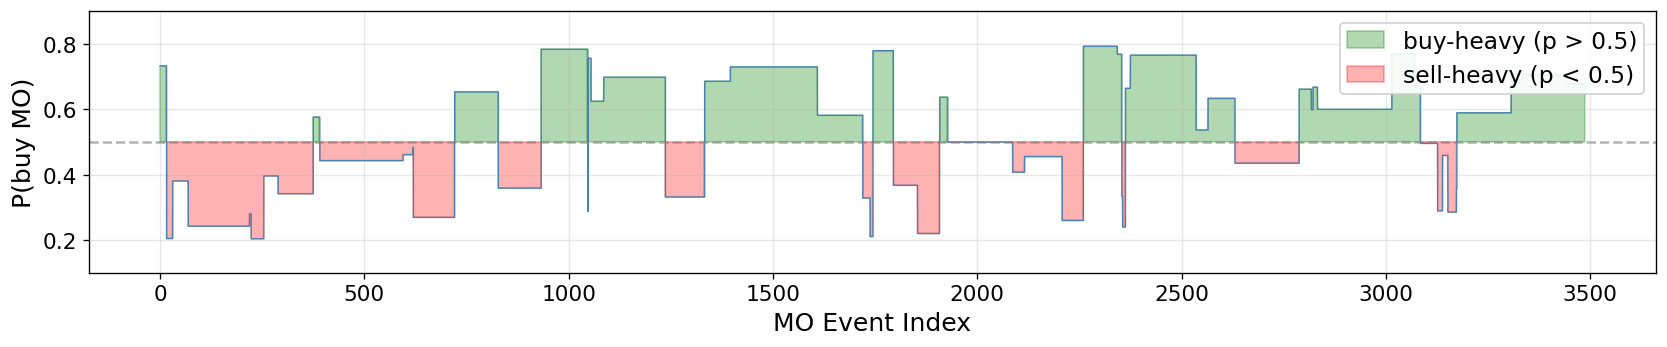

Expected MO horizon inside N_STEPS : 3488
Regimes used in that horizon       : 58
Used regime lengths                : mean=60.1  median=40.0  max=213  (expected mean = 1/rate = 60 MOs)
Time-weighted mean p_buy           : 0.539  (ensemble expectation: 0.500)


In [5]:
# ── Build a regime schedule ──────────────────────────────────────────────────
#
# make_regime_schedule() returns a callable  f(step_idx) -> p_buy  that
# pre-generates all regime boundaries and p_buy values at construction time.
#
# Internally it works as follows:
#   1. Draw regime durations L_k from the configured distribution:
#        - exponential: L_k ~ Exp(rate = REGIME_EXP_RATE)
#        - pareto:      L_k ~ Pareto(α, L_min)
#   2. Draw p_buy_k ~ U[p_lo, p_hi] for each regime k.
#   3. Accumulate boundaries:  B_0 = 0,  B_{k+1} = B_k + L_k
#   4. At query time, binary search (np.searchsorted) to find which regime
#      contains the given MO event index, and return the corresponding p_buy.
#
# The schedule object also exposes .boundaries and .p_values for diagnostics.
# We reuse the shared helper so this section stays aligned with later cells.

sched = build_regime_schedule(total_events=N_STEPS, seed=REGIME_SEED)
regime_desc = get_regime_desc()

# Evaluate p_buy at every MO event index to build the full trace
steps = np.arange(EXPECTED_MO_PER_EPISODE)
p_vals = np.array([sched(s) for s in steps])

# ── Plot ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 3))
ax.fill_between(steps, 0.5, p_vals, where=p_vals > 0.5,
                alpha=0.3, color="green", label="buy-heavy (p > 0.5)")
ax.fill_between(steps, 0.5, p_vals, where=p_vals < 0.5,
                alpha=0.3, color="red", label="sell-heavy (p < 0.5)")
ax.step(steps, p_vals, linewidth=0.8, color="steelblue", where="post")
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.6)
ax.set_xlabel("MO Event Index")
ax.set_ylabel("P(buy MO)")
ax.set_ylim(0.1, 0.9)
# ax.set_title(f"Regime Schedule ({regime_desc}, seed={REGIME_SEED})")  # supervisor: no inline titles; caption describes
ax.legend(loc="upper right", fontsize=14)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig("regime_schedule_example.png", dpi=150)
plt.show()
plt.close(fig)

# ── Summary statistics over the MO horizon expected inside N_STEPS ──────────
# The schedule is pre-generated with a +1000-MO buffer, but evaluation consumes
# only the regimes hit by the MOs that occur during the N_STEPS LOB events.
# For this no-simulation diagnostic, clip statistics to EXPECTED_MO_PER_EPISODE.
mo_horizon = EXPECTED_MO_PER_EPISODE
boundaries = np.asarray(sched.boundaries, dtype=int)
p_values_sched = np.asarray(sched.p_values, dtype=float)
starts = boundaries[:-1]
ends = boundaries[1:]
used = starts < mo_horizon
lengths = np.maximum(0, np.minimum(ends[used], mo_horizon) - starts[used])
p_values_used = p_values_sched[used]
positive = lengths > 0
lengths = lengths[positive]
p_values_used = p_values_used[positive]
n_regimes = len(p_values_used)
print(f"Expected MO horizon inside N_STEPS : {mo_horizon}")
print(f"Regimes used in that horizon       : {n_regimes}")
if REGIME_DISTRIBUTION == "exponential":
    expected_len = 1.0 / REGIME_EXP_RATE
    expected_txt = f"expected mean = 1/rate = {expected_len:.0f} MOs"
else:
    expected_len = REGIME_ALPHA * REGIME_L_MIN / (REGIME_ALPHA - 1)
    expected_txt = f"expected mean = alpha*L_min/(alpha-1) = {expected_len:.0f} MOs"
print(f"Used regime lengths                : mean={np.mean(lengths):.1f}  "
      f"median={np.median(lengths):.1f}  max={np.max(lengths)}  ({expected_txt})")
print(f"Time-weighted mean p_buy           : {np.average(p_values_used, weights=lengths):.3f}  "
      f"(ensemble expectation: 0.500)")

In [6]:
# ── Sanity check: verify that the schedule sampling is unbiased ──────────────
#
# Depending on the selected distribution, any single realisation can look
# skewed (few long regimes or many short regimes).
#
# To confirm there is no systematic bias, we generate 10,000 independent
# schedules and compute the time-weighted mean p_buy for each.

n_check = 10_000
weighted_means = np.empty(n_check)

mo_horizon = EXPECTED_MO_PER_EPISODE

for i in range(n_check):
    s = build_regime_schedule(total_events=N_STEPS, seed=i)
    # Time-weighted mean on the MO clock, clipped to the expected number of
    # MOs inside the N_STEPS LOB-event episode. The +1000 pre-generation tail is
    # deliberately excluded from this diagnostic.
    boundaries = np.asarray(s.boundaries, dtype=int)
    p_values_sched = np.asarray(s.p_values, dtype=float)
    starts = boundaries[:-1]
    ends = boundaries[1:]
    used = starts < mo_horizon
    lens_clipped = np.maximum(0, np.minimum(ends[used], mo_horizon) - starts[used])
    p_used = p_values_sched[used]
    positive = lens_clipped > 0
    weighted_means[i] = np.average(p_used[positive], weights=lens_clipped[positive])

print(f"Time-weighted mean p_buy across {n_check} schedules:")
print(f"  Mean   = {np.mean(weighted_means):.4f}  (expected: 0.500)")
print(f"  Std    = {np.std(weighted_means):.4f}")
print(f"  Min    = {np.min(weighted_means):.4f}")
print(f"  Max    = {np.max(weighted_means):.4f}")
print(f"  < 0.45 : {np.mean(weighted_means < 0.45):.1%}")
print(f"  > 0.55 : {np.mean(weighted_means > 0.55):.1%}")

Time-weighted mean p_buy across 10000 schedules:
  Mean   = 0.4995  (expected: 0.500)
  Std    = 0.0321
  Min    = 0.3847
  Max    = 0.6338
  < 0.45 : 6.3%
  > 0.55 : 5.7%


## 2. Run a Single Episode: Phase A vs Phase B under Regime-Switching

We run three simulations with paired random seeds:

| Simulation | `buy_mo_prob` | Description |
|-----------|--------------|-------------|
| **Phase A + baseline** | `0.5` constant | Stationary reference case. |
| **Phase A + regime-switching** | callable schedule | Stationary checkpoint under dynamic `p_buy`. |
| **Phase B + regime-switching** | same callable schedule | Regime-trained checkpoint under the same schedule. |

The seed pairing gives common random numbers where the endogenous book state permits it. It does **not** imply that the entire event tape remains identical after `p_buy` or the policy changes, because the book state, cancellations, and future decisions become endogenous to each run.

The controllers are loaded from checkpoints and run in inference mode: frozen weights, deterministic NoisyNet/eval mode, and no gradient updates.


In [7]:
# ── Load the pre-trained DQN Rainbow controllers ────────────────────────────

ctrl_base = make_controller_from_checkpoint(
    str(DQN_CHECKPOINT_BASE),
    log_dir="runs_eval/regime_diag_phase_a",
    use_time_update=True,
    min_time_interval=DQN_TIME_THROTTLE,
    inv_limit_override=INV_LIMIT,
)
print("Phase A checkpoint loaded.\n")

ctrl_phaseb = None
if HAS_PHASEB:
    ctrl_phaseb = make_controller_from_checkpoint(
        str(DQN_CHECKPOINT_PHASEB),
        log_dir="runs_eval/regime_diag_phase_b",
        use_time_update=True,
        min_time_interval=DQN_TIME_THROTTLE,
        inv_limit_override=INV_LIMIT,
    )
    print("Phase B checkpoint loaded.\n")
else:
    print("No Phase B checkpoint found/configured; running Phase A-only diagnostics.\n")


def assert_controller_matches_signal_config(controller, signal_config, label):
    assert bool(getattr(controller, "use_flow_signal", False)) == bool(signal_config.get("use_flow", False)), label
    assert bool(getattr(controller, "use_fast_flow_signal", False)) == bool(signal_config.get("use_fast_flow", False)), label
    assert bool(getattr(controller, "use_bayes_flow_signal", False)) == bool(signal_config.get("use_bayes", False)), label
    assert bool(getattr(controller, "use_fill_imbalance", False)) == bool(signal_config.get("use_fill_imbalance", False)), label
    if signal_config.get("use_bayes"):
        expected_keys = list(_meta_phaseb.get("BAYES_FLOW_FEATURE_KEYS", ["bayes_m_hat", "bayes_expected_run_length"]))
        assert list(getattr(controller, "bayes_flow_feature_keys", [])) == expected_keys, label


assert_controller_matches_signal_config(ctrl_base, SIGNAL_BASE, "Phase A controller/signal_config mismatch")
if HAS_PHASEB:
    assert_controller_matches_signal_config(ctrl_phaseb, SIGNAL_PHASEB, "Phase B controller/signal_config mismatch")
    print("Phase B controller feature plumbing verified: Bayes + quote-exposure input is active.\n")




================ DEEP CONTROLLER SETUP ================
Algorithm          : Deep Q-Learning
Double             : True
Dueling            : True
Prioritized Replay : True
Noisy Nets         : True (heads-only, independent)
[MM PURE]          : True
[MM PURE] inv_limit: 8
[MM PURE] offsets          : [(-1, -1), (-1, 0), (0, -1), (0, 0), (0, 1), (1, 0)]
[MM PURE] max_bid_offset   : 1
[MM PURE] max_ask_offset   : 1
[MM PURE] max_offset(state): 1

--- Throttling Configuration ---
Time Gating        : True (min 1.0s)
Event Gating       : False (min 100 steps)
TOB Gating         : False (min 10 moves)
MDP Mode (no bypass): True
Slow Flow EWMA     : False
Fast Flow EWMA     : False
Bayes Flow Signal  : False
Fill Imbalance     : False
  PER alpha schedule:
     start=0.6000  end=0.4000  last_ep=2000
  PER beta schedule:
     start=0.4000   end=1.0000   last_ep=2000

--- Core Hyperparameters ---
Gamma           = 0.97
Learning rate   = 0.0015
Batch size      = 128
Replay capacity = 150000
Tar

In [8]:
# -- Helper: deterministic seeding and clean controller state ----------------

def set_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def reset_eval_controller(controller):
    # Reset throttle/SMDP episode state before each standalone eval run.
    if controller is None:
        return
    controller.last_action_idx = None
    if hasattr(controller, "nstep_buffer"):
        controller.nstep_buffer.clear()
    if hasattr(controller, "_smdp_reset"):
        controller._smdp_reset()
    controller._has_acted_once = False
    controller._last_was_decision = False
    controller.moves_tob = 0
    controller.last_env_tob_key = None
    controller.event_steps = 0
    controller.last_update_time = -1.0
    controller.last_inventory = None
    controller.last_mode = None


def run_one_sim(
    buy_mo_prob,
    seed=SEED,
    controller=None,
    total_events=LONG_SIM_STEPS,
    equil_steps=LONG_SIM_STEPS_TO_EQUIL,
    signal_config=None,
    metrics_only=False,
    metrics_trace_max_points=None,
):
    # Run a single LOB simulation with a frozen DQN controller.
    # If metrics_only=True, the simulator returns a compact metrics dict instead
    # of materialising the heavy msg_df/mm_df telemetry DataFrames.
    if controller is None:
        controller = ctrl_base
    reset_eval_controller(controller)
    set_seeds(seed)
    msg_df, _, mm_out = simulate_LOB_with_MM(
        **build_sim_kwargs(total_events, equil_steps, signal_config=signal_config),
        controller=controller,
        random_seed=seed,
        buy_mo_prob=buy_mo_prob,
        metrics_only=bool(metrics_only),
        metrics_trace_max_points=metrics_trace_max_points,
    )
    return msg_df, mm_out


In [9]:
# ----- CACHE CHECK -----
_cache_params = {
    'LONG_SIM_STEPS': globals().get('LONG_SIM_STEPS'),
    'SEED': globals().get('SEED'),
    'REGIME_SEED': globals().get('REGIME_SEED'),
    'HAS_PHASEB': globals().get('HAS_PHASEB'),
    'CHECKPOINT_BASE_NAME': getattr(globals().get('DQN_CHECKPOINT_BASE'), 'name', None),
    'CHECKPOINT_PHASEB_NAME': getattr(globals().get('DQN_CHECKPOINT_PHASEB'), 'name', None) if globals().get('HAS_PHASEB') and globals().get('DQN_CHECKPOINT_PHASEB') is not None else None,
}
_cache_file = _cache_path("CELL_10_paired_single_episodes", _cache_params)
_cached = _load_cache(_cache_file, force_refresh=FORCE_REFRESH_ALL)
if _cached is not None:
    (msg_regime, mm_regime, msg_base, mm_base, msg_regime_phaseb, mm_regime_phaseb, sched_long) = _cached
else:
    # ── Run THREE paired simulations ────────────────────────────────────────────
    #
    # 1) Phase A DQN under regime-switching flow
    # 2) Phase A DQN under baseline (p=0.5)
    # 3) Phase B DQN under the same regime-switching flow

    sched_long = build_regime_schedule(total_events=LONG_SIM_STEPS, seed=REGIME_SEED + 1)

    print("Running regime-switching sim (Phase A agent)...")
    msg_regime, mm_regime = run_one_sim(
        buy_mo_prob=sched_long,
        seed=SEED,
        controller=ctrl_base,
        signal_config=SIGNAL_BASE,
    )
    print(f"  Done. Final PnL = {mm_regime['MM_TotalPnL'].iloc[-1]:+.4f}")

    print("Running baseline sim (Phase A agent, p=0.5)...")
    msg_base, mm_base = run_one_sim(
        buy_mo_prob=0.5,
        seed=SEED,
        controller=ctrl_base,
        signal_config=SIGNAL_BASE,
    )
    print(f"  Done. Final PnL = {mm_base['MM_TotalPnL'].iloc[-1]:+.4f}")

    msg_regime_phaseb = None
    mm_regime_phaseb = None
    if HAS_PHASEB:
        print("Running regime-switching sim (Phase B agent)...")
        msg_regime_phaseb, mm_regime_phaseb = run_one_sim(
            buy_mo_prob=sched_long,
            seed=SEED,
            controller=ctrl_phaseb,
            signal_config=SIGNAL_PHASEB,
        )
        print(f"  Done. Final PnL = {mm_regime_phaseb['MM_TotalPnL'].iloc[-1]:+.4f}")
    else:
        print("Skipping Phase B regime-switching sim; no Phase B checkpoint available.")
    _save_cache(_cache_file, (msg_regime, mm_regime, msg_base, mm_base, msg_regime_phaseb, mm_regime_phaseb, sched_long))
# ----- END CACHE -----


[CACHE] Failed to load CELL_10_paired_single_episodes_049109fc.pkl: Ran out of input
Running regime-switching sim (Phase A agent)...
  Done. Final PnL = -2.0900
Running baseline sim (Phase A agent, p=0.5)...
  Done. Final PnL = +6.4400
Running regime-switching sim (Phase B agent)...
  Done. Final PnL = +2.1500
[CACHE] Failed to save CELL_10_paired_single_episodes_049109fc.pkl: Can't pickle local object 'make_regime_schedule.<locals>.schedule'


## 3. Three-Panel Diagnostic Plot

The figure below aligns three time series on a shared x-axis (event step):

1. **Top panel — Regime schedule**: instantaneous `p_buy`. Green shading indicates buy-heavy regimes (`p > 0.5`), red shading indicates sell-heavy regimes (`p < 0.5`). This panel is the latent ground truth that the agent does not observe directly.
2. **Middle panel — Cumulative PnL (mark-to-market)**: total PnL = cash + unrealised inventory value at mid-price. We compare Phase A baseline (blue), Phase A under regime-switching (red), and Phase B under regime-switching (orange).
3. **Bottom panel — Inventory**: the MM's net position across the same three cases.


In [10]:
# ── Reconstruct the p_buy trace aligned to the simulation event grid ─────────
#
# The regime schedule callable maps MO *event indices* (0, 1, 2, ...) to p_buy.
# However, mm_df is indexed by *all* LOB events (LOs, MOs, and cancellations).
# We need to map the MO-indexed schedule back onto the full event grid for plotting.
#
# Strategy:
#   1. Identify which rows in msg_df are MO events (Type == 1 in Santa Fe).
#   2. For each MO event, look up sched(mo_counter) to get p_buy.
#   3. Forward-fill p_buy to non-MO events (LOs, cancels) so every row has a value.

p_buy_all_steps, n_mo = reconstruct_p_buy_trace(msg_regime, mm_regime, sched_long)

print(f"Total events: {len(mm_regime):,}  |  MO events: {n_mo:,}  |  "
      f"MO fraction: {n_mo/len(mm_regime):.1%}")

Total events: 100,000  |  MO events: 3,351  |  MO fraction: 3.4%


[SAVE] regime_switching_one_episode_example.png -> local + paper folder
[SAVE] regime_trained_final_phase_b.png -> local + paper folder


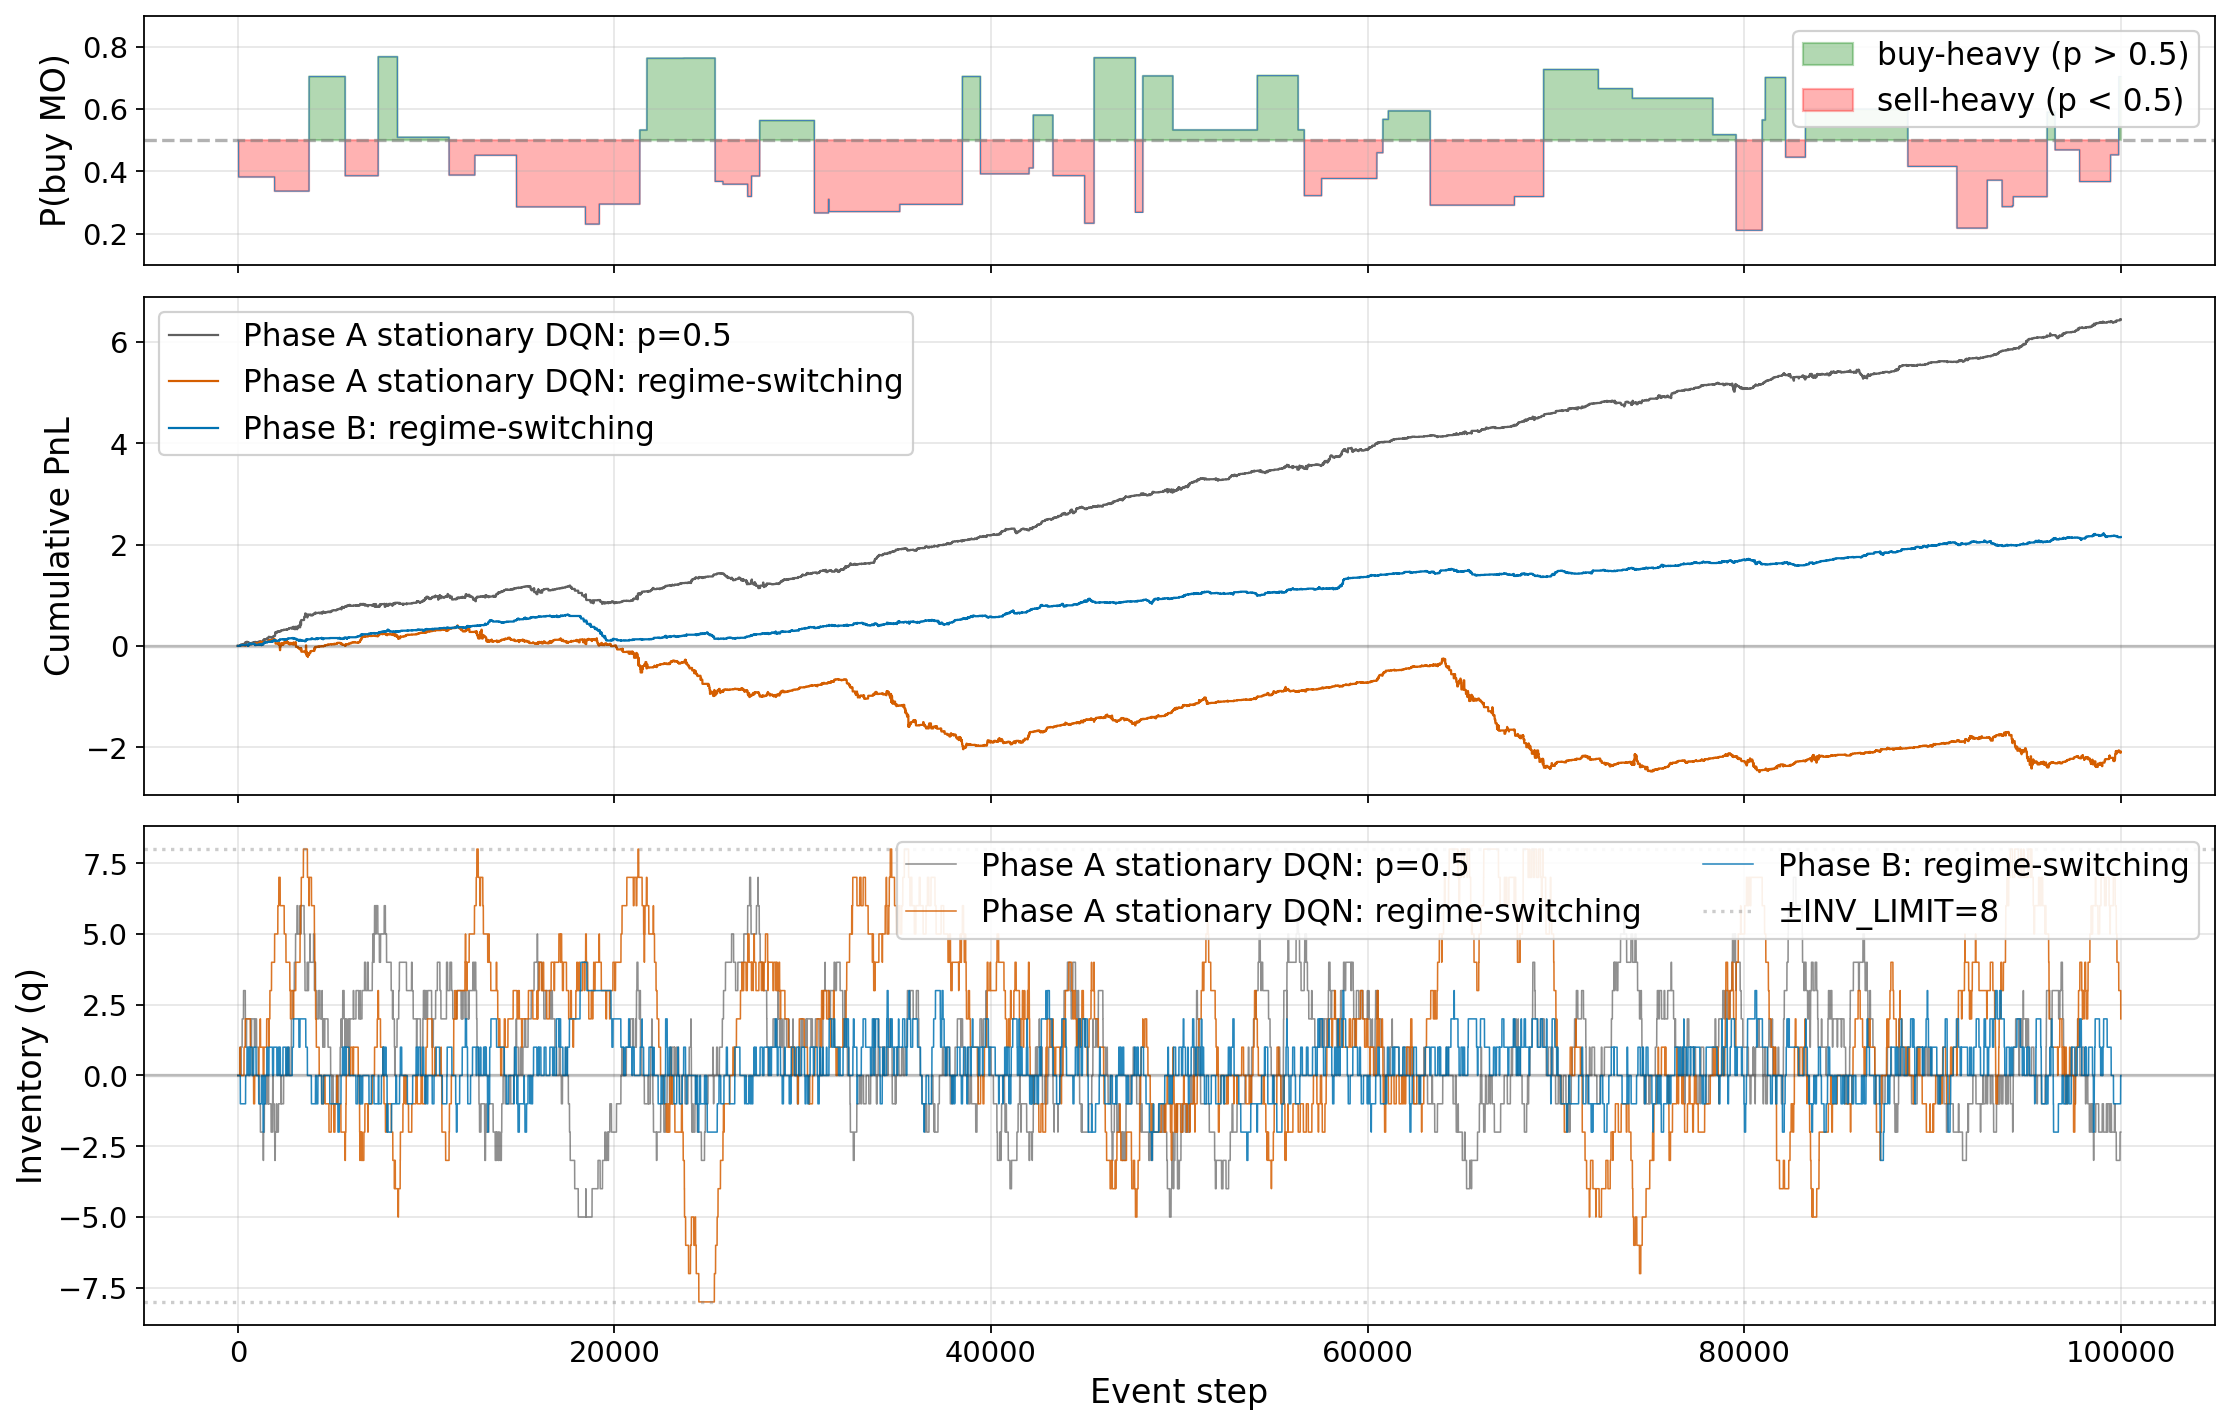


Final PnL  —  Phase A baseline: +6.4400  |  Phase A RS: -2.0900  |  Phase B RS: +2.1500


In [11]:
from pathlib import Path
import importlib
import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
import IPython.display as ipd

from matplotlib.axes import Axes
from matplotlib.figure import Figure
import matplotlib.axes._axes as _mpl_axes
import matplotlib.figure as _mpl_figure

# Repair the broken title monkey-patch from previous cells
_mpl_axes = importlib.reload(_mpl_axes)
_mpl_figure = importlib.reload(_mpl_figure)

Axes.set_title = _mpl_axes.Axes.set_title
Figure.suptitle = _mpl_figure.Figure.suptitle


# Color convention (matches supervisor caption):
#   gray = baseline (Phase A at symmetric flow p=0.5)
#   red  = Phase A under regime stress
#   blue = Phase B regime-trained
COL_BASELINE = "#444444"
COL_REGIME_A = "#D55E00"
COL_REGIME_B = "#0072B2"

PAPER_DIR = Path("/Users/felipemoret/Desktop/extended_first_abstract_RLMM")


def _build_episode_figure(include_phaseb):
    """Three-panel single-episode diagnostic; optionally overlays Phase B."""
    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1, figsize=(14, 9), sharex=True,
        gridspec_kw={"height_ratios": [1, 2, 2.0]},
    )

    steps = np.arange(len(mm_regime))

    # Panel 1: regime schedule
    ax1.fill_between(
        steps, 0.5, p_buy_all_steps,
        where=p_buy_all_steps > 0.5,
        alpha=0.3, color="green",
        label="buy-heavy (p > 0.5)",
    )
    ax1.fill_between(
        steps, 0.5, p_buy_all_steps,
        where=p_buy_all_steps < 0.5,
        alpha=0.3, color="red",
        label="sell-heavy (p < 0.5)",
    )
    ax1.plot(steps, p_buy_all_steps, linewidth=0.5, color="steelblue")
    ax1.axhline(y=0.5, color="gray", linestyle="--", alpha=0.6)
    ax1.set_ylabel("P(buy MO)")
    ax1.set_ylim(0.1, 0.9)
    # ax1.set_title("Regime schedule")  # supervisor: no inline titles; caption describes
    ax1.legend(loc="upper right", fontsize=14)
    ax1.grid(True, alpha=0.3)

    # Panel 2: cumulative PnL
    pnl_base = mm_base["MM_TotalPnL"].values
    pnl_regime = mm_regime["MM_TotalPnL"].values
    ax2.plot(
        np.arange(len(pnl_base)), pnl_base,
        linewidth=1.0, color=COL_BASELINE, alpha=0.85,
        label=f"{BASE_LABEL}: p=0.5",
    )
    ax2.plot(
        steps, pnl_regime,
        linewidth=1.0, color=COL_REGIME_A,
        label=f"{BASE_LABEL}: regime-switching",
    )
    if include_phaseb and mm_regime_phaseb is not None:
        pnl_phaseb = mm_regime_phaseb["MM_TotalPnL"].values
        ax2.plot(
            np.arange(len(pnl_phaseb)), pnl_phaseb,
            linewidth=1.0, color=COL_REGIME_B,
            label="Phase B: regime-switching",
        )
    ax2.axhline(y=0, color="black", linestyle="-", alpha=0.2)
    ax2.set_ylabel("Cumulative PnL")
    # (title removed; caption describes)
    ax2.legend(loc="upper left", fontsize=14)
    ax2.grid(True, alpha=0.3)

    # Panel 3: inventory
    inv_base = mm_base["MM_Inventory"].values
    inv_regime = mm_regime["MM_Inventory"].values
    ax3.plot(
        np.arange(len(inv_base)), inv_base,
        linewidth=0.7, color=COL_BASELINE, alpha=0.6,
        label=f"{BASE_LABEL}: p=0.5",
    )
    ax3.plot(
        steps, inv_regime,
        linewidth=0.7, color=COL_REGIME_A, alpha=0.85,
        label=f"{BASE_LABEL}: regime-switching",
    )
    if include_phaseb and mm_regime_phaseb is not None:
        inv_phaseb = mm_regime_phaseb["MM_Inventory"].values
        ax3.plot(
            np.arange(len(inv_phaseb)), inv_phaseb,
            linewidth=0.7, color=COL_REGIME_B, alpha=0.85,
            label="Phase B: regime-switching",
        )
    ax3.axhline(y=0, color="black", linestyle="-", alpha=0.2)
    ax3.axhline(y=INV_LIMIT, color="gray", linestyle=":", alpha=0.4,
                label=f"±INV_LIMIT={INV_LIMIT}")
    ax3.axhline(y=-INV_LIMIT, color="gray", linestyle=":", alpha=0.4)
    ax3.set_ylabel("Inventory (q)")
    ax3.set_xlabel("Event step")
    # (title removed; caption describes)
    ax3.legend(loc="upper right", fontsize=14, ncol=2)
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


def _save_both(fig, name):
    fig.savefig(Path(name), dpi=150, bbox_inches="tight")
    if PAPER_DIR.is_dir():
        fig.savefig(PAPER_DIR / name, dpi=150, bbox_inches="tight")
    print(f"[SAVE] {name} -> local + paper folder")


# ----- Block A: Phase A only -> regime_switching_one_episode_example.png ----
fig_a = _build_episode_figure(include_phaseb=False)
_save_both(fig_a, "regime_switching_one_episode_example.png")
plt.close(fig_a)

# ----- Block B: Phase A + Phase B -> regime_trained_final_phase_b.png -------
if HAS_PHASEB and mm_regime_phaseb is not None:
    fig_ab = _build_episode_figure(include_phaseb=True)
    _save_both(fig_ab, "regime_trained_final_phase_b.png")
    buf = BytesIO()
    fig_ab.savefig(buf, format="png", dpi=160, bbox_inches="tight")
    buf.seek(0)
    ipd.display(ipd.Image(data=buf.getvalue()))
    plt.close(fig_ab)
else:
    print("[SKIP] regime_trained_final_phase_b.png -- HAS_PHASEB=False or no Phase B episode available")
    fig_disp = _build_episode_figure(include_phaseb=False)
    buf = BytesIO()
    fig_disp.savefig(buf, format="png", dpi=160, bbox_inches="tight")
    buf.seek(0)
    ipd.display(ipd.Image(data=buf.getvalue()))
    plt.close(fig_disp)

_phaseb_note = (
    f"  |  Phase B RS: {mm_regime_phaseb['MM_TotalPnL'].iloc[-1]:+.4f}"
    if (HAS_PHASEB and mm_regime_phaseb is not None)
    else ""
)
print(
    "\nFinal PnL  —  "
    f"Phase A baseline: {mm_base['MM_TotalPnL'].iloc[-1]:+.4f}  |  "
    f"Phase A RS: {mm_regime['MM_TotalPnL'].iloc[-1]:+.4f}"
    + _phaseb_note
)


## 4. Monte Carlo: PnL Distribution

A single episode is anecdotal. We therefore run a paired Monte Carlo batch across seeds.

For each seed $i$:
- **Phase A + baseline**: `buy_mo_prob = 0.5` constant.
- **Phase A + regime-switching**: `buy_mo_prob = make_regime_schedule(...)`.
- **Phase B + regime-switching**: same schedule as Phase A regime-switching.

The most relevant paired comparison for robustness is **Phase B + regime-switching minus Phase A + regime-switching**, because both policies face the same schedule seed and market seed.


In [12]:
# ----- CACHE CHECK -----
_cache_params = {
    'N_QUICK': globals().get('N_QUICK'),
    'N_STEPS': globals().get('N_STEPS'),
    'N_STEPS_TO_EQUIL': globals().get('N_STEPS_TO_EQUIL'),
    'GLOBAL_SEED': globals().get('GLOBAL_SEED'),
    'MC_TRAJ_MAX_POINTS': globals().get('MC_TRAJ_MAX_POINTS'),
    'HAS_PHASEB': globals().get('HAS_PHASEB'),
    'CHECKPOINT_BASE_NAME': getattr(globals().get('DQN_CHECKPOINT_BASE'), 'name', None),
    'CHECKPOINT_PHASEB_NAME': getattr(globals().get('DQN_CHECKPOINT_PHASEB'), 'name', None) if globals().get('HAS_PHASEB') and globals().get('DQN_CHECKPOINT_PHASEB') is not None else None,
}
_cache_file = _cache_path("CELL_15_mc_quick", _cache_params)
_cached = _load_cache(_cache_file, force_refresh=FORCE_REFRESH_ALL)
if _cached is not None:
    (pnls_base_all, pnls_regime_all, pnls_phaseb_all, pnl_traj_base, pnl_traj_regime, pnl_traj_phaseb, inv_traj_base, inv_traj_regime, inv_traj_phaseb, delta_base_regime_vs_baseline, improvement_phaseb_vs_base_rs, phaseb_gap_to_base_baseline) = _cached
else:
    # -- Monte Carlo: base conditions plus optional Phase B across N_QUICK seeds --

    import gc
    import time

    N_QUICK = 100
    MC_PROGRESS_EVERY = 10
    MC_TRAJ_MAX_POINTS = 5000      # Downsample trajectories before storing; protects RAM at 500k+ steps.
    MC_GC_EVERY_RUN = True

    pnls_base_all = []
    pnls_regime_all = []
    pnls_phaseb_all = []

    # Memory-safe trajectory storage: each run keeps only a downsampled PnL/inventory trace.
    pnl_traj_base = []
    pnl_traj_regime = []
    pnl_traj_phaseb = []
    inv_traj_base = []
    inv_traj_regime = []
    inv_traj_phaseb = []


    def _clear_eval_controller_state(controller):
        if hasattr(controller, "nstep_buffer"):
            controller.nstep_buffer.clear()


    def _cleanup_after_eval(controller=None):
        if controller is not None:
            _clear_eval_controller_state(controller)
        if "torch" in globals() and hasattr(torch, "cuda") and torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()


    def _downsample_values(values, max_points=MC_TRAJ_MAX_POINTS):
        arr = np.asarray(values)
        n = len(arr)
        if n == 0:
            return np.asarray([], dtype=np.float32)
        if n <= max_points:
            return arr.astype(np.float32, copy=True)
        idx = np.linspace(0, n - 1, max_points).round().astype(int)
        return arr[idx].astype(np.float32, copy=True)


    def _extract_terminal_and_traces(mm_df):
        pnl_values = mm_df["MM_TotalPnL"].to_numpy(copy=False)
        inv_values = mm_df["MM_Inventory"].to_numpy(copy=False)
        terminal_pnl = float(pnl_values[-1])
        pnl_trace = _downsample_values(pnl_values)
        inv_trace = _downsample_values(inv_values)
        return terminal_pnl, pnl_trace, inv_trace


    def _run_mc_case(case_label, buy_mo_prob, seed, controller, signal_config):
        print(f"    start {case_label}", flush=True)
        t0 = time.time()

        _, metrics = run_one_sim(
            buy_mo_prob=buy_mo_prob,
            seed=int(seed),
            controller=controller,
            total_events=N_STEPS,
            equil_steps=N_STEPS_TO_EQUIL,
            signal_config=signal_config,
            metrics_only=True,
            metrics_trace_max_points=MC_TRAJ_MAX_POINTS,
        )

        terminal_pnl = float(metrics["MM_TotalPnL"])
        pnl_trace = np.asarray(metrics.get("trace_pnl", []), dtype=np.float32)
        inv_trace = np.asarray(metrics.get("trace_inventory", []), dtype=np.float32)
        del metrics

        if MC_GC_EVERY_RUN:
            _cleanup_after_eval(controller)
        else:
            _clear_eval_controller_state(controller)

        elapsed = time.time() - t0
        print(f"    done  {case_label}: pnl={terminal_pnl:+.4f}, elapsed={elapsed:.1f}s", flush=True)
        return terminal_pnl, pnl_trace, inv_trace


    for i in range(N_QUICK):
        seed_i = int(GLOBAL_SEED + i)
        print(f"\n[Monte Carlo {i+1}/{N_QUICK}] seed={seed_i}", flush=True)

        sched_i = build_regime_schedule(total_events=N_STEPS, seed=seed_i + 999_999)

        # 1) Phase A DQN + regime-switching.
        pnl_r, pnl_trace_r, inv_trace_r = _run_mc_case(
            case_label="Phase A regime-switching",
            buy_mo_prob=sched_i,
            seed=seed_i,
            controller=ctrl_base,
            signal_config=SIGNAL_BASE,
        )
        pnls_regime_all.append(pnl_r)
        pnl_traj_regime.append(pnl_trace_r)
        inv_traj_regime.append(inv_trace_r)

        # 2) Phase A DQN + baseline (p=0.5).
        pnl_b, pnl_trace_b, inv_trace_b = _run_mc_case(
            case_label="Phase A baseline p=0.5",
            buy_mo_prob=0.5,
            seed=seed_i,
            controller=ctrl_base,
            signal_config=SIGNAL_BASE,
        )
        pnls_base_all.append(pnl_b)
        pnl_traj_base.append(pnl_trace_b)
        inv_traj_base.append(inv_trace_b)

        # 3) Optional Phase B DQN + same regime-switching schedule.
        if HAS_PHASEB:
            pnl_pb, pnl_trace_pb, inv_trace_pb = _run_mc_case(
                case_label="Phase B regime-switching",
                buy_mo_prob=sched_i,
                seed=seed_i,
                controller=ctrl_phaseb,
                signal_config=SIGNAL_PHASEB,
            )
            pnls_phaseb_all.append(pnl_pb)
            pnl_traj_phaseb.append(pnl_trace_pb)
            inv_traj_phaseb.append(inv_trace_pb)

        del sched_i

        if ((i + 1) % MC_PROGRESS_EVERY == 0) or ((i + 1) == N_QUICK):
            msg = (
                f"  progress {i+1}/{N_QUICK} | "
                f"Phase A base mean={np.mean(pnls_base_all):+.4f} | "
                f"Phase A RS mean={np.mean(pnls_regime_all):+.4f}"
            )
            if HAS_PHASEB and len(pnls_phaseb_all) > 0:
                msg += f" | Phase B RS mean={np.mean(pnls_phaseb_all):+.4f}"
            print(msg, flush=True)

        gc.collect()

    pnls_base_all = np.asarray(pnls_base_all, dtype=float)
    pnls_regime_all = np.asarray(pnls_regime_all, dtype=float)
    pnls_phaseb_all = np.asarray(pnls_phaseb_all, dtype=float) if HAS_PHASEB else None

    # -- Summary statistics ------------------------------------------------------
    delta_base_regime_vs_baseline = pnls_regime_all - pnls_base_all
    if HAS_PHASEB:
        improvement_phaseb_vs_base_rs = pnls_phaseb_all - pnls_regime_all
        phaseb_gap_to_base_baseline = pnls_phaseb_all - pnls_base_all


    def _tstat(d):
        se = np.std(d, ddof=1) / np.sqrt(len(d))
        return np.nan if se == 0 else np.mean(d) / se


    print(f"\nPhase A + baseline      -- E[PnL] = {np.mean(pnls_base_all):+.4f}  "
          f"std = {np.std(pnls_base_all, ddof=1):.4f}")
    print(f"Phase A + regime-sw     -- E[PnL] = {np.mean(pnls_regime_all):+.4f}  "
          f"std = {np.std(pnls_regime_all, ddof=1):.4f}")
    if HAS_PHASEB:
        print(f"Phase B + regime-sw     -- E[PnL] = {np.mean(pnls_phaseb_all):+.4f}  "
              f"std = {np.std(pnls_phaseb_all, ddof=1):.4f}")
    else:
        print("Phase B + regime-sw     -- skipped (no Phase B checkpoint)")
    print(f"\nRobustness loss, Phase A RS vs Phase A baseline -- E[Delta] = "
          f"{np.mean(delta_base_regime_vs_baseline):+.4f}  t = {_tstat(delta_base_regime_vs_baseline):.2f}")
    if HAS_PHASEB:
        print(f"Phase B improvement vs Phase A under same RS    -- E[Delta] = "
              f"{np.mean(improvement_phaseb_vs_base_rs):+.4f}  t = {_tstat(improvement_phaseb_vs_base_rs):.2f}")
        print(f"Phase B RS gap to Phase A stationary baseline   -- E[Delta] = "
              f"{np.mean(phaseb_gap_to_base_baseline):+.4f}  t = {_tstat(phaseb_gap_to_base_baseline):.2f}")
    _save_cache(_cache_file, (pnls_base_all, pnls_regime_all, pnls_phaseb_all, pnl_traj_base, pnl_traj_regime, pnl_traj_phaseb, inv_traj_base, inv_traj_regime, inv_traj_phaseb, delta_base_regime_vs_baseline, improvement_phaseb_vs_base_rs, phaseb_gap_to_base_baseline))
# ----- END CACHE -----



[Monte Carlo 1/100] seed=123
    start Phase A regime-switching
    done  Phase A regime-switching: pnl=-5.0150, elapsed=20.8s
    start Phase A baseline p=0.5
    done  Phase A baseline p=0.5: pnl=+6.8300, elapsed=22.7s
    start Phase B regime-switching
    done  Phase B regime-switching: pnl=+3.0500, elapsed=28.8s

[Monte Carlo 2/100] seed=124
    start Phase A regime-switching
    done  Phase A regime-switching: pnl=-2.8800, elapsed=22.9s
    start Phase A baseline p=0.5
    done  Phase A baseline p=0.5: pnl=+7.3550, elapsed=22.3s
    start Phase B regime-switching
    done  Phase B regime-switching: pnl=+3.2950, elapsed=28.8s

[Monte Carlo 3/100] seed=125
    start Phase A regime-switching
    done  Phase A regime-switching: pnl=-2.4300, elapsed=22.4s
    start Phase A baseline p=0.5
    done  Phase A baseline p=0.5: pnl=+6.5950, elapsed=22.3s
    start Phase B regime-switching
    done  Phase B regime-switching: pnl=+2.9150, elapsed=27.5s

[Monte Carlo 4/100] seed=126
    start 

[SAVE] pnl_distribution_phaseA_phaseB.png -> local + paper folder


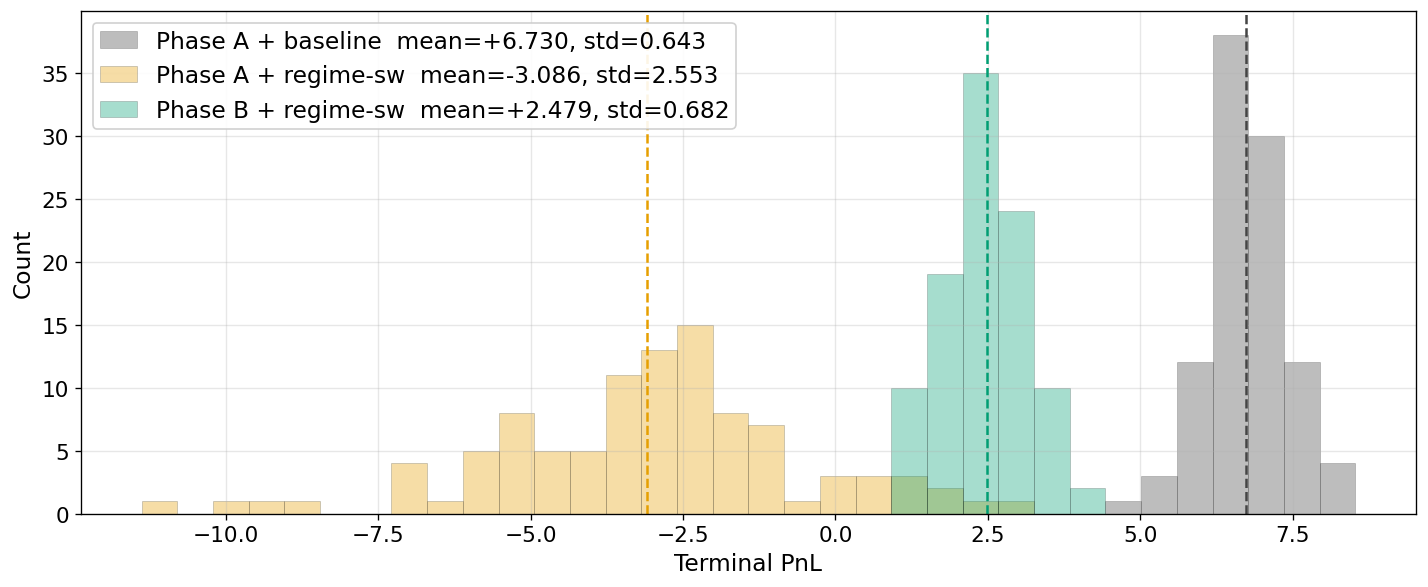

In [13]:
from pathlib import Path
# ── Histogram: terminal PnL distribution ───────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 5))

pnl_groups = [pnls_base_all, pnls_regime_all]
if HAS_PHASEB:
    pnl_groups.append(pnls_phaseb_all)
all_pnls = np.concatenate(pnl_groups)
bins = np.linspace(all_pnls.min() - 0.05, all_pnls.max() + 0.05, 35)

ax.hist(pnls_base_all, bins=bins, alpha=0.35, color="#444444", edgecolor="black",
        linewidth=0.3,
        label=f"Phase A + baseline  "
              f"mean={np.mean(pnls_base_all):+.3f}, std={np.std(pnls_base_all, ddof=1):.3f}")
ax.hist(pnls_regime_all, bins=bins, alpha=0.35, color="#E69F00", edgecolor="black",
        linewidth=0.3,
        label=f"Phase A + regime-sw  "
              f"mean={np.mean(pnls_regime_all):+.3f}, std={np.std(pnls_regime_all, ddof=1):.3f}")
if HAS_PHASEB:
    ax.hist(pnls_phaseb_all, bins=bins, alpha=0.35, color="#009E73", edgecolor="black",
            linewidth=0.3,
            label=f"Phase B + regime-sw  "
                  f"mean={np.mean(pnls_phaseb_all):+.3f}, std={np.std(pnls_phaseb_all, ddof=1):.3f}")

ax.axvline(np.mean(pnls_base_all), color="#444444", linestyle="--", linewidth=1.5)
ax.axvline(np.mean(pnls_regime_all), color="#E69F00", linestyle="--", linewidth=1.5)
if HAS_PHASEB:
    ax.axvline(np.mean(pnls_phaseb_all), color="#009E73", linestyle="--", linewidth=1.5)

ax.set_xlabel("Terminal PnL", fontsize=14)
ax.set_ylabel("Count", fontsize=14)
# ax.set_title(  # supervisor: no inline titles; caption describes
    # f"Terminal PnL Distribution: {'Phase A vs Phase B' if HAS_PHASEB else 'Phase A base-only'} (N={N_QUICK})\n"
    # f"Regime params: {regime_desc}, p_buy ∈ [{REGIME_P_LO}, {REGIME_P_HI}]",
    # fontsize=14,
# )
ax.legend(fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()

# ── Save for paper export ─────────────────────────────────────────────
_LOCAL_FIG_PATH = Path("pnl_distribution_phaseA_phaseB.png")
_PAPER_FIG_PATH = Path("/Users/felipemoret/Desktop/extended_first_abstract_RLMM/pnl_distribution_phaseA_phaseB.png")
plt.savefig(_LOCAL_FIG_PATH, dpi=150, bbox_inches="tight")
plt.savefig(_PAPER_FIG_PATH, dpi=150, bbox_inches="tight")
print(f"[SAVE] pnl_distribution_phaseA_phaseB.png -> local + paper folder")

plt.show()


## 5. Trajectory Plots: Mean $\pm$ Std across Episodes

The histograms above show terminal PnL only. The plots below show cumulative PnL and inventory trajectories averaged across the Monte Carlo episodes, with $\pm 1\sigma$ bands.

These plots reveal:
- when regime-switching damage occurs;
- whether inventory dispersion grows or stabilises;
- whether Phase B improves the regime-switching trajectory relative to Phase A under the same schedule distribution.


In [14]:
# -- Build trajectory matrices from downsampled traces ----------------------


def stack_traces(traces):
    if len(traces) == 0:
        return None
    min_len = min(len(trace) for trace in traces)
    return np.stack([np.asarray(trace[:min_len], dtype=np.float32) for trace in traces], axis=0)


pnl_matrix_base = stack_traces(pnl_traj_base)
pnl_matrix_regime = stack_traces(pnl_traj_regime)
pnl_matrix_phaseb = stack_traces(pnl_traj_phaseb) if HAS_PHASEB else None

inv_matrix_base = stack_traces(inv_traj_base)
inv_matrix_regime = stack_traces(inv_traj_regime)
inv_matrix_phaseb = stack_traces(inv_traj_phaseb) if HAS_PHASEB else None

matrix_lengths = [pnl_matrix_base.shape[1], pnl_matrix_regime.shape[1]]
if HAS_PHASEB:
    matrix_lengths.append(pnl_matrix_phaseb.shape[1])
T = min(matrix_lengths)

# The traces are downsampled, so map the plot axis back to approximate event steps.
t = np.linspace(0, N_STEPS - 1, T)

print(f"Stacked downsampled shape: ({pnl_matrix_base.shape[0]} runs, {T} stored points)")
print(f"Original steps per episode: {N_STEPS}; stored points per trajectory <= {MC_TRAJ_MAX_POINTS}")
print(f"Phase A + baseline  -- final PnL mean={pnl_matrix_base[:, -1].mean():+.4f}, "
      f"std={pnl_matrix_base[:, -1].std():.4f}")
print(f"Phase A + regime-sw -- final PnL mean={pnl_matrix_regime[:, -1].mean():+.4f}, "
      f"std={pnl_matrix_regime[:, -1].std():.4f}")
if HAS_PHASEB:
    print(f"Phase B + regime-sw -- final PnL mean={pnl_matrix_phaseb[:, -1].mean():+.4f}, "
          f"std={pnl_matrix_phaseb[:, -1].std():.4f}")
else:
    print("Phase B + regime-sw -- skipped (no Phase B checkpoint)")


Stacked downsampled shape: (100 runs, 5001 stored points)
Original steps per episode: 100000; stored points per trajectory <= 5000
Phase A + baseline  -- final PnL mean=+6.7304, std=0.6398
Phase A + regime-sw -- final PnL mean=-3.0856, std=2.5406
Phase B + regime-sw -- final PnL mean=+2.4790, std=0.6784


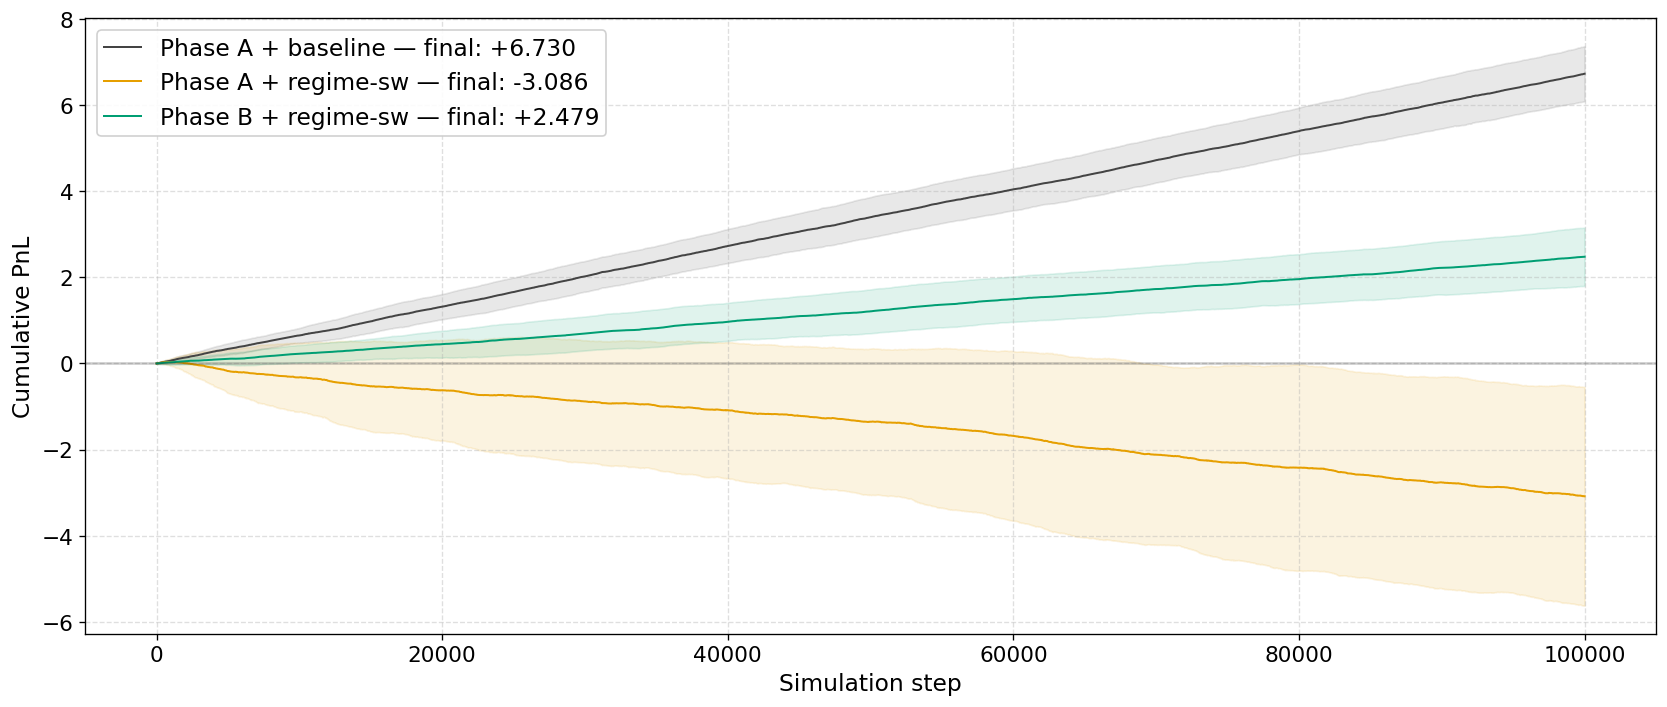

Saved: regime_switching_pnl_trajectory.png


In [15]:
from pathlib import Path
# ── Cumulative PnL: mean +/- 1 std ─────────────────────────────────────────

mean_pnl_base = pnl_matrix_base[:, :T].mean(axis=0)
std_pnl_base = pnl_matrix_base[:, :T].std(axis=0)
mean_pnl_regime = pnl_matrix_regime[:, :T].mean(axis=0)
std_pnl_regime = pnl_matrix_regime[:, :T].std(axis=0)
mean_pnl_phaseb = pnl_matrix_phaseb[:, :T].mean(axis=0) if HAS_PHASEB else None
std_pnl_phaseb = pnl_matrix_phaseb[:, :T].std(axis=0) if HAS_PHASEB else None

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(t, mean_pnl_base, linewidth=1.2, color="#444444",
        label=f"Phase A + baseline — final: {mean_pnl_base[-1]:+.3f}")
ax.fill_between(t, mean_pnl_base - std_pnl_base, mean_pnl_base + std_pnl_base,
                alpha=0.12, color="#444444")

ax.plot(t, mean_pnl_regime, linewidth=1.2, color="#E69F00",
        label=f"Phase A + regime-sw — final: {mean_pnl_regime[-1]:+.3f}")
ax.fill_between(t, mean_pnl_regime - std_pnl_regime, mean_pnl_regime + std_pnl_regime,
                alpha=0.12, color="#E69F00")

if HAS_PHASEB:
    ax.plot(t, mean_pnl_phaseb, linewidth=1.2, color="#009E73",
            label=f"Phase B + regime-sw — final: {mean_pnl_phaseb[-1]:+.3f}")
    ax.fill_between(t, mean_pnl_phaseb - std_pnl_phaseb,
                    mean_pnl_phaseb + std_pnl_phaseb,
                    alpha=0.12, color="#009E73")

ax.axhline(y=0, color="black", linestyle="-", alpha=0.2)
ax.set_xlabel("Simulation step", fontsize=14)
ax.set_ylabel("Cumulative PnL", fontsize=14)
# ax.set_title("")  # supervisor: no inline titles; caption describes
ax.legend(fontsize=14, loc="upper left")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("regime_switching_pnl_trajectory.png", dpi=150)
plt.savefig("regime_trained_pnl_mean_across_time.png", dpi=200, bbox_inches="tight")  # paper-named export
_PAPER_FIG_PATH = Path("/Users/felipemoret/Desktop/extended_first_abstract_RLMM/regime_trained_pnl_mean_across_time.png")
plt.savefig(_PAPER_FIG_PATH, dpi=200, bbox_inches="tight")
plt.show()
print("Saved: regime_switching_pnl_trajectory.png")


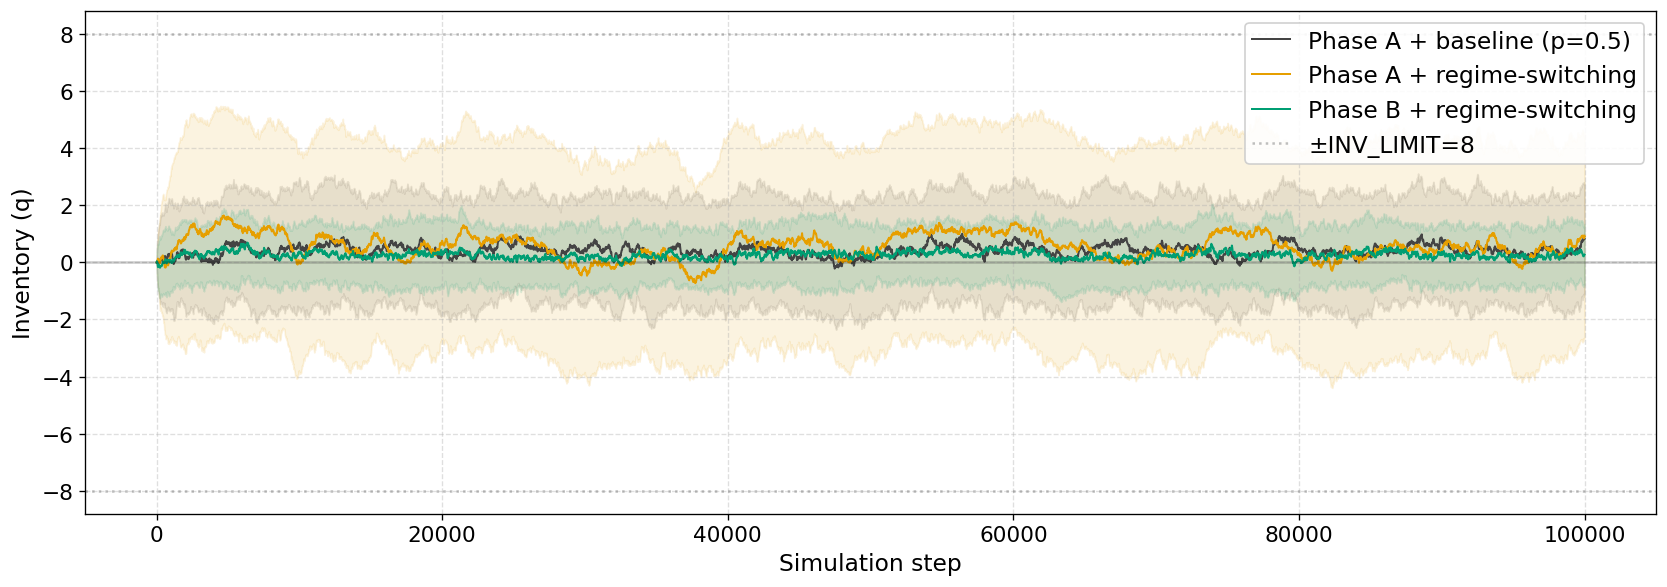

Saved: regime_switching_inv_trajectory.png

Time-averaged inventory std:
  Phase A + baseline  : 1.987
  Phase A + regime-sw : 3.755  (1.89x)
  Phase B + regime-sw : 1.107  (0.56x)


In [16]:
from pathlib import Path
# ── Inventory: mean +/- 1 std ─────────────────────────────────────────────

mean_inv_base = inv_matrix_base[:, :T].mean(axis=0)
std_inv_base = inv_matrix_base[:, :T].std(axis=0)
mean_inv_regime = inv_matrix_regime[:, :T].mean(axis=0)
std_inv_regime = inv_matrix_regime[:, :T].std(axis=0)
mean_inv_phaseb = inv_matrix_phaseb[:, :T].mean(axis=0) if HAS_PHASEB else None
std_inv_phaseb = inv_matrix_phaseb[:, :T].std(axis=0) if HAS_PHASEB else None

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(t, mean_inv_base, linewidth=1.2, color="#444444",
        label="Phase A + baseline (p=0.5)")
ax.fill_between(t, mean_inv_base - std_inv_base, mean_inv_base + std_inv_base,
                alpha=0.12, color="#444444")

ax.plot(t, mean_inv_regime, linewidth=1.2, color="#E69F00",
        label="Phase A + regime-switching")
ax.fill_between(t, mean_inv_regime - std_inv_regime, mean_inv_regime + std_inv_regime,
                alpha=0.12, color="#E69F00")

if HAS_PHASEB:
    ax.plot(t, mean_inv_phaseb, linewidth=1.2, color="#009E73",
            label="Phase B + regime-switching")
    ax.fill_between(t, mean_inv_phaseb - std_inv_phaseb,
                    mean_inv_phaseb + std_inv_phaseb,
                    alpha=0.12, color="#009E73")

ax.axhline(y=0, color="black", linestyle="-", alpha=0.2)
ax.axhline(y=INV_LIMIT, color="gray", linestyle=":", alpha=0.5, label=f"±INV_LIMIT={INV_LIMIT}")
ax.axhline(y=-INV_LIMIT, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Simulation step", fontsize=14)
ax.set_ylabel("Inventory (q)", fontsize=14)
# ax.set_title("")  # supervisor: no inline titles; caption describes
ax.legend(fontsize=14, loc="upper right")
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("regime_switching_inv_trajectory.png", dpi=150)
plt.savefig("inventory_distribution_phaseA_phaseB.png", dpi=200, bbox_inches="tight")  # paper-named export
_PAPER_FIG_PATH = Path("/Users/felipemoret/Desktop/extended_first_abstract_RLMM/inventory_distribution_phaseA_phaseB.png")
plt.savefig(_PAPER_FIG_PATH, dpi=200, bbox_inches="tight")
plt.show()
print("Saved: regime_switching_inv_trajectory.png")

# ── Quantitative comparison of inventory dispersion ─────────────────────────
avg_std_base = std_inv_base.mean()
avg_std_regime = std_inv_regime.mean()
avg_std_phaseb = std_inv_phaseb.mean() if HAS_PHASEB else None
print(f"\nTime-averaged inventory std:")
print(f"  Phase A + baseline  : {avg_std_base:.3f}")
print(f"  Phase A + regime-sw : {avg_std_regime:.3f}  ({avg_std_regime / avg_std_base:.2f}x)")
if HAS_PHASEB:
    print(f"  Phase B + regime-sw : {avg_std_phaseb:.3f}  ({avg_std_phaseb / avg_std_base:.2f}x)")
else:
    print("  Phase B + regime-sw : skipped (no Phase B checkpoint)")


## 6. Stress Test Across Regime Time Scales

This extra sweep isolates the Phase A stationary checkpoint under five market conditions:

- **No regime**: stationary `p_buy = 0.5`.
- **Exponential regimes** with '15.0, 30.0, 60.0, 120.0, 240.0'.

The goal is to visualise how performance decays as directional regimes become more or less persistent under the same asymmetry bounds.



================ DEEP CONTROLLER SETUP ================
Algorithm          : Deep Q-Learning
Double             : True
Dueling            : True
Prioritized Replay : True
Noisy Nets         : True (heads-only, independent)
[MM PURE]          : True
[MM PURE] inv_limit: 8
[MM PURE] offsets          : [(-1, -1), (-1, 0), (0, -1), (0, 0), (0, 1), (1, 0)]
[MM PURE] max_bid_offset   : 1
[MM PURE] max_ask_offset   : 1
[MM PURE] max_offset(state): 1

--- Throttling Configuration ---
Time Gating        : True (min 1.0s)
Event Gating       : False (min 100 steps)
TOB Gating         : False (min 10 moves)
MDP Mode (no bypass): True
Slow Flow EWMA     : False
Fast Flow EWMA     : False
Bayes Flow Signal  : False
Fill Imbalance     : False
  PER alpha schedule:
     start=0.6000  end=0.4000  last_ep=2000
  PER beta schedule:
     start=0.4000   end=1.0000   last_ep=2000

--- Core Hyperparameters ---
Gamma           = 0.97
Learning rate   = 0.0015
Batch size      = 128
Replay capacity = 150000
Tar

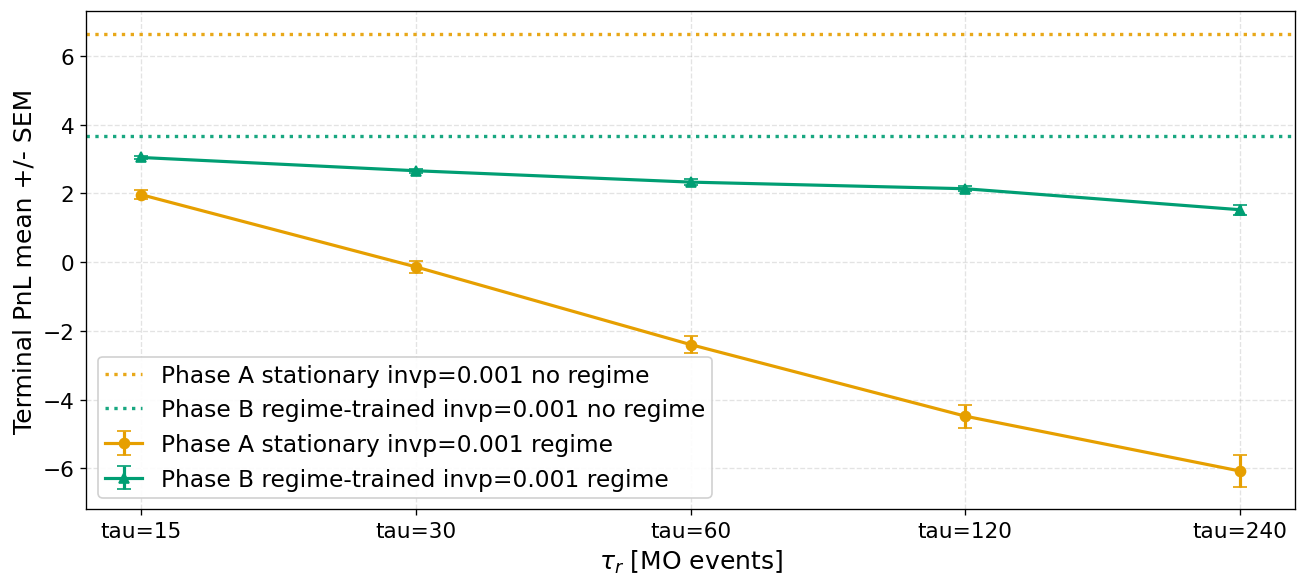

Saved: regime_tau_sweep_decay_phasea_vs_phaseb.png
Saved: /Users/felipemoret/Desktop/extended_first_abstract_RLMM/regime_tau_sweep_decay_phasea_vs_phaseb.png

Tau sweep summary:

Phase A stationary invp=0.001 (deep_mm_mtm_pure_invp0.0010_inv_wall_dampened_reward_clr200f0p30_best_ma50.pt)
   No regime  mean=+6.6532  std=0.7578  Delta=+0.0000
      tau=15  mean=+1.9650  std=1.3295  Delta=-4.6881
      tau=30  mean=-0.1376  std=1.8542  Delta=-6.7908
      tau=60  mean=-2.4004  std=2.5522  Delta=-9.0536
     tau=120  mean=-4.4847  std=3.3818  Delta=-11.1378
     tau=240  mean=-6.0824  std=4.5902  Delta=-12.7355

Phase B regime-trained invp=0.001 (deep_mm_mtm_pure_invp0.0010_g0p999_nstep3_h1x256_a6_regime_exponential_factored_noise_fully_noisy_inv_wall_dampened_reward_cyc_lr_fill_quote_exposure_bayes_on2_mix_on_best_ma100.pt)
   No regime  mean=+3.6788  std=0.3728  Delta=+0.0000
      tau=15  mean=+3.0479  std=0.4436  Delta=-0.6309
      tau=30  mean=+2.6617  std=0.5347  Delta=-1.0171
     

In [17]:
# ----- CACHE CHECK -----
_cache_params = {
    'N_TAU_SWEEP': globals().get('N_TAU_SWEEP'),
    'TAU_SWEEP': globals().get('TAU_SWEEP'),
    'TAU_SWEEP_STEPS': globals().get('TAU_SWEEP_STEPS'),
    'TAU_SWEEP_EQUIL': globals().get('TAU_SWEEP_EQUIL'),
    'GLOBAL_SEED': globals().get('GLOBAL_SEED'),
    'TAU_SWEEP_CHECKPOINT_PHASEA_NAME': getattr(globals().get('TAU_SWEEP_CHECKPOINT_PHASEA'), 'name', None),
    'TAU_SWEEP_CHECKPOINT_PHASEB_NAME': getattr(globals().get('TAU_SWEEP_CHECKPOINT_PHASEB'), 'name', None),
}
_cache_file = _cache_path("CELL_22_tau_sweep_phasea_vs_phaseb", _cache_params)
_cached = _load_cache(_cache_file, force_refresh=FORCE_REFRESH_ALL)
if _cached is not None:
    (tau_results, TAU_SWEEP_POLICIES, plot_labels, tau_labels) = _cached
else:
    # -- Tau sweep: Phase A stationary vs Phase B regime-trained --

    import gc
    import time

    TAU_SWEEP_STEPS = N_STEPS
    TAU_SWEEP_EQUIL = N_STEPS_TO_EQUIL
    TAU_SWEEP = [15.0, 30.0, 60.0, 120.0, 240.0]
    N_TAU_SWEEP = 100
    PROGRESS_EVERY = 10
    PRINT_EACH_RUN = False

    TAU_SWEEP_CHECKPOINT_PHASEA = CHECKPOINT_DIR / "deep_mm_mtm_pure_invp0.0010_inv_wall_dampened_reward_clr200f0p30_best_ma50.pt"
    TAU_SWEEP_CHECKPOINT_PHASEB = CHECKPOINT_DIR / "deep_mm_mtm_pure_invp0.0010_g0p999_nstep3_h1x256_a6_regime_exponential_factored_noise_fully_noisy_inv_wall_dampened_reward_cyc_lr_fill_quote_exposure_bayes_on2_mix_on_best_ma100.pt"

    TAU_SWEEP_FIG_PATH = Path("regime_tau_sweep_decay_phasea_vs_phaseb.png")
    TAU_SWEEP_PAPER_FIG_PATH = Path("/Users/felipemoret/Desktop/extended_first_abstract_RLMM/regime_tau_sweep_decay_phasea_vs_phaseb.png")


    def _tau_label(tau):
        tau_f = float(tau)
        if tau_f.is_integer():
            return f"tau={int(tau_f)}"
        return f"tau={tau_f:g}"


    def _load_tau_sweep_controller(checkpoint_path, label, key):
        meta = load_meta(checkpoint_path)
        best_params = meta.get("best_params", {})
        controller = make_controller_from_checkpoint(
            str(checkpoint_path),
            log_dir=f"runs_eval/tau_sweep_{key}",
            use_time_update=True,
            min_time_interval=float(best_params.get("min_time_interval", DQN_TIME_THROTTLE)),
            inv_limit_override=int(best_params.get("inv_limit", INV_LIMIT)),
        )
        return {
            "key": key,
            "label": label,
            "checkpoint": checkpoint_path,
            "controller": controller,
            "signal_config": checkpoint_signal_config(meta),
        }


    def _cleanup_eval_controller(controller):
        if hasattr(controller, "nstep_buffer"):
            controller.nstep_buffer.clear()
        if "torch" in globals() and hasattr(torch, "cuda") and torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()


    def _run_one_terminal_pnl(
        buy_mo_prob,
        seed,
        controller,
        total_events,
        equil_steps,
        signal_config,
        run_label=None,
    ):
        if run_label is not None:
            print(f"    start {run_label}", flush=True)
        t0 = time.time()

        _, metrics = run_one_sim(
            buy_mo_prob=buy_mo_prob,
            seed=int(seed),
            controller=controller,
            total_events=total_events,
            equil_steps=equil_steps,
            signal_config=signal_config,
            metrics_only=True,
        )

        final_pnl = float(metrics["MM_TotalPnL"])
        del metrics

        _cleanup_eval_controller(controller)

        if run_label is not None:
            elapsed = time.time() - t0
            print(f"    done  {run_label}: pnl={final_pnl:+.4f}, elapsed={elapsed:.1f}s", flush=True)

        return final_pnl


    def _print_policy_progress(spec, tau_pnls):
        counts = [f"No regime={len(tau_pnls['No regime'])}/{N_TAU_SWEEP}"]
        for tau in TAU_SWEEP:
            label = _tau_label(tau)
            counts.append(f"{label}={len(tau_pnls[label])}/{N_TAU_SWEEP}")
        print(f"  {spec['label']} progress | " + " | ".join(counts), flush=True)


    assert TAU_SWEEP_CHECKPOINT_PHASEA.exists(), f"Missing Phase A checkpoint: {TAU_SWEEP_CHECKPOINT_PHASEA}"
    assert TAU_SWEEP_CHECKPOINT_PHASEB.exists(), f"Missing Phase B checkpoint: {TAU_SWEEP_CHECKPOINT_PHASEB}"


    TAU_SWEEP_POLICIES = [
        _load_tau_sweep_controller(
            TAU_SWEEP_CHECKPOINT_PHASEA,
            label="Phase A stationary invp=0.001",
            key="phasea_invp001",
        ),
        _load_tau_sweep_controller(
            TAU_SWEEP_CHECKPOINT_PHASEB,
            label="Phase B regime-trained invp=0.001",
            key="phaseb_invp001",
        ),
    ]

    print("Tau sweep policies:")
    for spec in TAU_SWEEP_POLICIES:
        print(f"  {spec['label']}: {spec['checkpoint'].name}")


    def _run_tau_sweep_for_policy(spec):
        tau_pnls = {"No regime": []}
        for tau in TAU_SWEEP:
            tau_pnls[_tau_label(tau)] = []

        print(f"\nStarting tau sweep for {spec['label']}", flush=True)
        _print_policy_progress(spec, tau_pnls)

        for i in range(N_TAU_SWEEP):
            seed_i = int(GLOBAL_SEED + 20_000 + i)

            if (
                PRINT_EACH_RUN
                or i == 0
                or ((i + 1) % PROGRESS_EVERY == 0)
                or ((i + 1) == N_TAU_SWEEP)
            ):
                print(f"\n  {spec['label']} seed {i+1}/{N_TAU_SWEEP} (seed={seed_i})", flush=True)

            pnl_stationary = _run_one_terminal_pnl(
                buy_mo_prob=0.5,
                seed=seed_i,
                controller=spec["controller"],
                total_events=TAU_SWEEP_STEPS,
                equil_steps=TAU_SWEEP_EQUIL,
                signal_config=spec["signal_config"],
                run_label="No regime" if PRINT_EACH_RUN else None,
            )
            tau_pnls["No regime"].append(pnl_stationary)

            for tau in TAU_SWEEP:
                label = _tau_label(tau)
                sched_seed = int(seed_i + 1_000_000 + round(10_000 * float(tau)))

                sched_i = build_regime_schedule(
                    total_events=TAU_SWEEP_STEPS,
                    seed=sched_seed,
                    distribution="exponential",
                    tau=float(tau),
                )

                pnl_tau = _run_one_terminal_pnl(
                    buy_mo_prob=sched_i,
                    seed=seed_i,
                    controller=spec["controller"],
                    total_events=TAU_SWEEP_STEPS,
                    equil_steps=TAU_SWEEP_EQUIL,
                    signal_config=spec["signal_config"],
                    run_label=label if PRINT_EACH_RUN else None,
                )
                tau_pnls[label].append(pnl_tau)

                del sched_i
                gc.collect()

            if ((i + 1) % PROGRESS_EVERY == 0) or ((i + 1) == N_TAU_SWEEP):
                _print_policy_progress(spec, tau_pnls)

        gc.collect()
        return {label: np.asarray(values, dtype=float) for label, values in tau_pnls.items()}


    plot_labels = [_tau_label(tau) for tau in TAU_SWEEP]
    tau_labels = ["No regime"] + plot_labels
    tau_results = {}

    for spec in TAU_SWEEP_POLICIES:
        tau_pnls = _run_tau_sweep_for_policy(spec)

        means = np.array([np.mean(tau_pnls[label]) for label in tau_labels])
        stds = np.array([np.std(tau_pnls[label], ddof=1) for label in tau_labels])
        sems = stds / np.sqrt(N_TAU_SWEEP)

        baseline = tau_pnls["No regime"]
        paired_diffs = {"No regime": np.zeros_like(baseline)}

        for tau in TAU_SWEEP:
            label = _tau_label(tau)
            paired_diffs[label] = tau_pnls[label] - baseline

        deltas = np.array([np.mean(paired_diffs[label]) for label in tau_labels])
        delta_sems = np.array([
            np.std(paired_diffs[label], ddof=1) / np.sqrt(N_TAU_SWEEP)
            for label in tau_labels
        ])
        decay_pct = np.where(means[0] != 0.0, 100.0 * deltas / abs(means[0]), np.nan)

        tau_results[spec["key"]] = {
            "spec": spec,
            "pnls": tau_pnls,
            "means": means,
            "stds": stds,
            "sems": sems,
            "deltas": deltas,
            "delta_sems": delta_sems,
            "decay_pct": decay_pct,
        }

        gc.collect()


    x = np.arange(len(plot_labels))
    colors = {
        "phasea_invp001": "#E69F00",
        "phaseb_invp001": "#009E73",
    }
    markers = {
        "phasea_invp001": "o",
        "phaseb_invp001": "^",
    }
    text_offsets = {
        "phasea_invp001": -0.06,
        "phaseb_invp001": 0.06,
    }
    no_regime_styles = {
        "phasea_invp001": {"linestyle": ":", "linewidth": 2.0, "alpha": 0.9},
        "phaseb_invp001": {"linestyle": ":", "linewidth": 2.0, "alpha": 0.9},
    }

    fig, ax1 = plt.subplots(figsize=(11, 5))

    for key, result in tau_results.items():
        spec = result["spec"]
        color = colors.get(key)
        style = no_regime_styles.get(key, {"linestyle": "--", "linewidth": 1.3, "alpha": 0.75})
        ax1.axhline(
            result["means"][0],
            color=color,
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            alpha=style["alpha"],
            label=f"{spec['label']} no regime",
        )

    for key, result in tau_results.items():
        spec = result["spec"]
        color = colors.get(key)
        ax1.errorbar(
            x,
            result["means"][1:],
            yerr=result["sems"][1:],
            fmt=markers.get(key, "o") + "-",
            capsize=4,
            color=color,
            linewidth=1.9,
            markersize=6,
            label=f"{spec['label']} regime",
        )

    ax1.set_ylabel("Terminal PnL mean +/- SEM")
    regime_p_lo = globals().get("REGIME_P_LO", 0.2)
    regime_p_hi = globals().get("REGIME_P_HI", 0.8)
    # ax1.set_title("")  # supervisor: no inline titles; caption describes
    ax1.grid(True, linestyle="--", alpha=0.35)
    ax1.legend(loc="best", fontsize=14)
    ax1.set_xticks(x)
    ax1.set_xticklabels(plot_labels)
    ax1.set_xlabel(r"$\tau_r$ [MO events]")

    plt.tight_layout()
    plt.savefig(TAU_SWEEP_FIG_PATH, dpi=150)
    if TAU_SWEEP_PAPER_FIG_PATH.parent.exists():
        plt.savefig(TAU_SWEEP_PAPER_FIG_PATH, dpi=150)
    plt.show()
    print(f"Saved: {TAU_SWEEP_FIG_PATH}")
    if TAU_SWEEP_PAPER_FIG_PATH.parent.exists():
        print(f"Saved: {TAU_SWEEP_PAPER_FIG_PATH}")

    print("\nTau sweep summary:")
    for key, result in tau_results.items():
        print(f"\n{result['spec']['label']} ({result['spec']['checkpoint'].name})")
        for label, mean_v, std_v, delta_v in zip(
            tau_labels,
            result["means"],
            result["stds"],
            result["deltas"],
        ):
            print(f"  {label:>10}  mean={mean_v:+.4f}  std={std_v:.4f}  Delta={delta_v:+.4f}")
    _save_cache(_cache_file, (tau_results, TAU_SWEEP_POLICIES, plot_labels, tau_labels))
# ----- END CACHE -----


## 7. Random-Tau Regime Duration Stress Test

The Phase B checkpoint was trained under regime switching with Bayesian mixture features over the MO-clock horizons
\(\{15, 30, 60, 120\}\).  The previous diagnostics use a fixed exponential regime duration, typically
\(\tau_r=60\).  Here we test a harder environment in which **each new regime independently draws its own
mean duration** from the same mixture grid before sampling the realised exponential length.

This first cell is a single paired episode for the **Phase B agent only**.  It compares:

- fixed exponential regimes with \(\tau_r=60\), and
- random-tau regimes where each regime chooses \(\tau \in \{15,30,60,120, 240\}\) before drawing its length.

The top panel shows the latent random-tau schedule; the middle and bottom panels compare Phase B PnL and inventory.



Fixed tau=60 regime table, first 12 regimes:
  k   mo_start   mo_end   length   tau_used   p_buy
   0         0      125     125     fixed  +0.229
   1       125      266     141     fixed  +0.380
   2       266      384     118     fixed  +0.721
   3       384      425      41     fixed  +0.521
   4       425      541     116     fixed  +0.455
   5       541      597      56     fixed  +0.210
   6       597      722     125     fixed  +0.465
   7       722      759      37     fixed  +0.708
   8       759      785      26     fixed  +0.549
   9       785      834      49     fixed  +0.659
  10       834      882      48     fixed  +0.702
  11       882      930      48     fixed  +0.408

Random tau per regime regime table, first 12 regimes:
  k   mo_start   mo_end   length   tau_used   p_buy
   0         0       43      43       120  +0.386
   1        43       75      32        30  +0.747
   2        75       85      10        30  +0.545
   3        85      489     404       240  +0

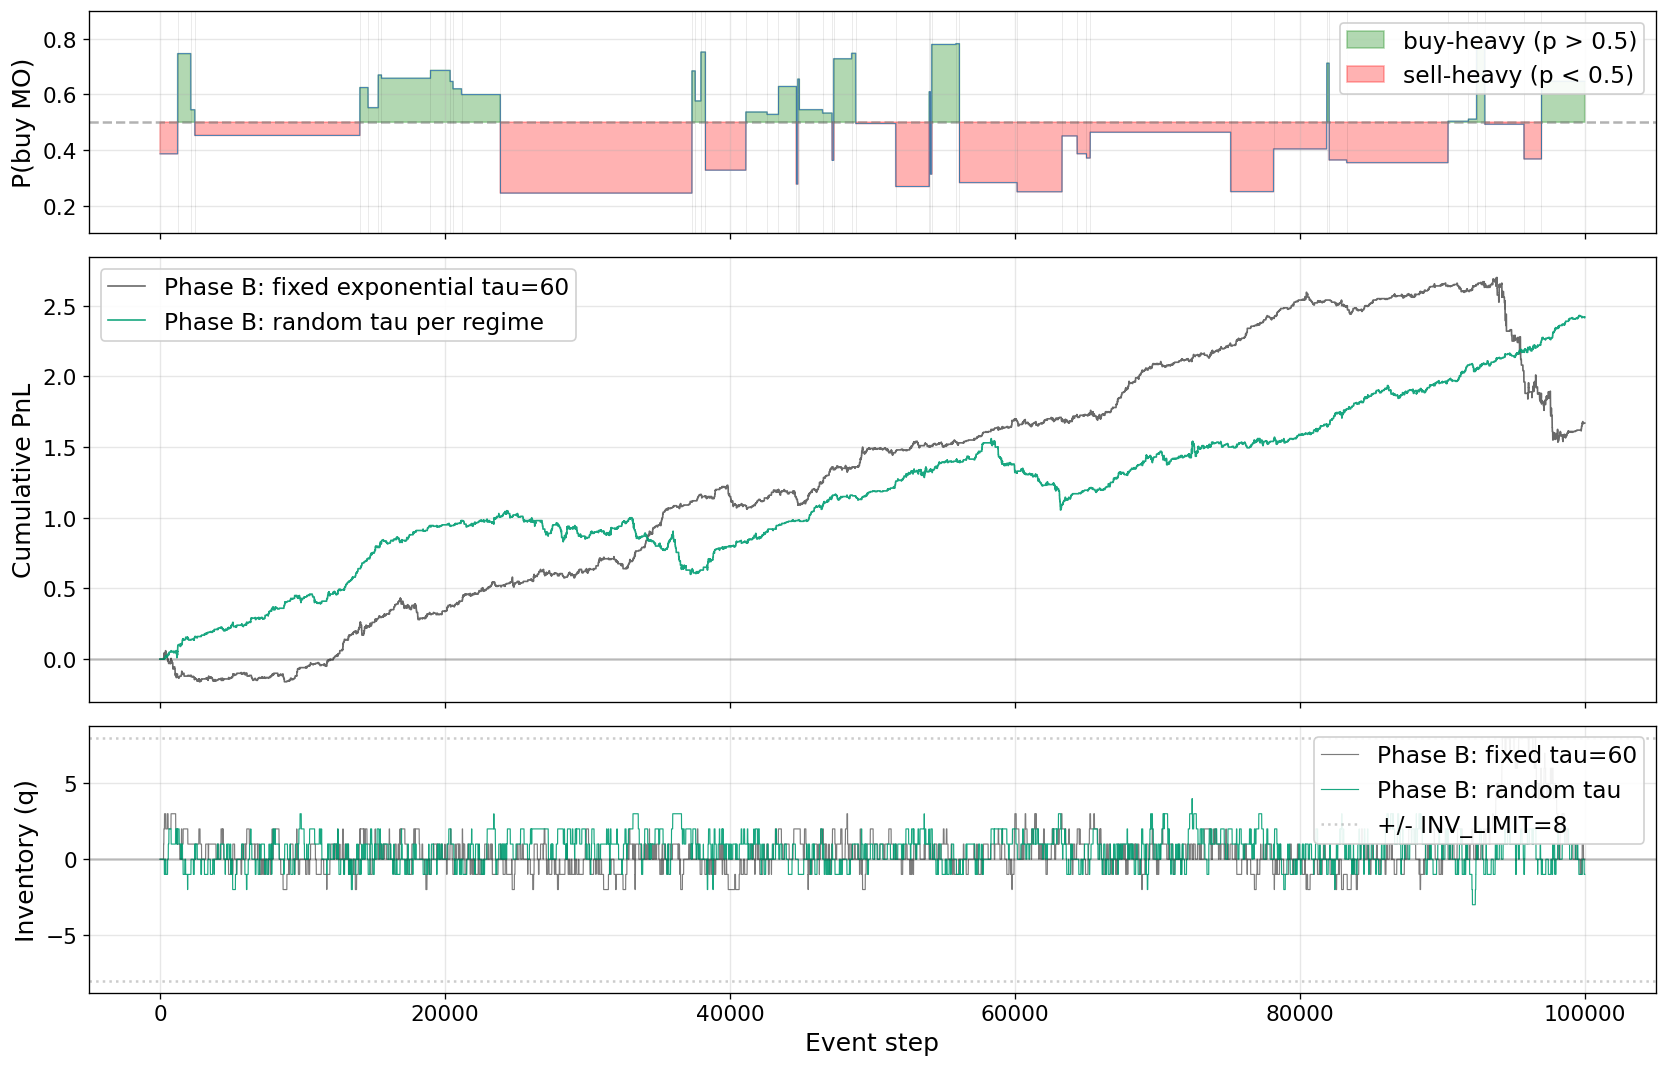


Final PnL  --  Phase B fixed tau=60: +1.6700  |  Phase B random tau: +2.4200
[CACHE] Failed to save CELL_24_phaseb_fixed_vs_random_tau_single_b2e4952f.pkl: Can't pickle local object 'make_regime_schedule.<locals>.schedule'


In [18]:
# ----- CACHE CHECK -----
_cache_params = {
    'RANDOM_TAU_STEPS': globals().get('RANDOM_TAU_STEPS'),
    'RANDOM_TAU_EQUIL': globals().get('RANDOM_TAU_EQUIL'),
    'RANDOM_TAU_SEED': globals().get('RANDOM_TAU_SEED'),
    'RANDOM_TAU_GRID': globals().get('RANDOM_TAU_GRID'),
    'FIXED_TAU': globals().get('FIXED_TAU'),
    'REGIME_P_LO': globals().get('REGIME_P_LO'),
    'REGIME_P_HI': globals().get('REGIME_P_HI'),
    'CHECKPOINT_PHASEB_NAME': getattr(globals().get('DQN_CHECKPOINT_PHASEB'), 'name', None) if globals().get('HAS_PHASEB') and globals().get('DQN_CHECKPOINT_PHASEB') is not None else None,
}
_cache_file = _cache_path("CELL_24_phaseb_fixed_vs_random_tau_single", _cache_params)
_cached = _load_cache(_cache_file, force_refresh=FORCE_REFRESH_ALL)
if _cached is not None:
    (mm_phaseb_fixed_tau, mm_phaseb_random_tau, sched_fixed_tau60, sched_random_tau) = _cached
else:
    # -- Phase B single episode: fixed tau=60 vs random tau per regime -----------

    import gc

    RANDOM_TAU_GRID = [15.0, 30.0, 60.0, 120.0, 240.0]
    FIXED_TAU = 60.0

    RANDOM_TAU_STEPS = N_STEPS
    RANDOM_TAU_EQUIL = N_STEPS_TO_EQUIL
    RANDOM_TAU_SEED = int(globals().get("GLOBAL_SEED", SEED)) + 300_000

    assert HAS_PHASEB, "Phase B checkpoint/controller is required for this diagnostic."


    def make_random_tau_regime_schedule(
        total_events,
        seed,
        tau_grid=RANDOM_TAU_GRID,
        p_lo=REGIME_P_LO,
        p_hi=REGIME_P_HI,
    ):
        """Callable p_buy schedule: each regime samples tau, length, and p_buy.

        Regime clock is the MO clock.  At the start of each regime:
          1. tau_k is drawn uniformly from tau_grid;
          2. L_k is drawn from Exp(mean=tau_k), rounded up to at least 1 MO;
          3. p_buy,k is drawn uniformly from [p_lo, p_hi].
        """
        rng = np.random.default_rng(int(seed))
        n_mo_events = estimate_expected_mo_events(total_events)

        boundaries = [0]
        p_values = []
        tau_values = []
        lengths = []

        boundaries_arr = np.array(boundaries, dtype=int)
        p_values_arr = np.array(p_values, dtype=float)

        def _append_regime():
            nonlocal boundaries_arr, p_values_arr

            tau = float(rng.choice(tau_grid))
            length = max(1, int(np.ceil(rng.exponential(tau))))
            p_buy = float(rng.uniform(p_lo, p_hi))

            boundaries.append(boundaries[-1] + length)
            lengths.append(length)
            tau_values.append(tau)
            p_values.append(p_buy)

            boundaries_arr = np.array(boundaries, dtype=int)
            p_values_arr = np.array(p_values, dtype=float)

        while boundaries[-1] < n_mo_events + 1000:
            _append_regime()

        def schedule(mo_idx):
            nonlocal boundaries_arr, p_values_arr
            mo_idx = int(mo_idx)

            while mo_idx >= boundaries[-1]:
                _append_regime()

            regime_idx = int(np.searchsorted(boundaries_arr, mo_idx, side="right")) - 1
            regime_idx = min(regime_idx, len(p_values_arr) - 1)
            return float(p_values_arr[regime_idx])

        schedule.boundaries = boundaries
        schedule.p_values = p_values
        schedule.tau_values = tau_values
        schedule.lengths = lengths
        schedule.tau_grid = list(map(float, tau_grid))

        return schedule


    def schedule_on_event_grid(schedule, n_events):
        """Approximate an event-grid p_buy trace from the MO-clock schedule."""
        event_steps = np.arange(n_events)
        mo_idx_proxy = np.floor(event_steps * MO_EVENT_FRACTION).astype(int)
        return np.asarray([schedule(int(j)) for j in mo_idx_proxy], dtype=float)


    def print_regime_table(schedule, name, max_rows=12):
        print(f"\n{name} regime table, first {max_rows} regimes:")
        print("  k   mo_start   mo_end   length   tau_used   p_buy")
        for k in range(min(max_rows, len(schedule.p_values))):
            tau_txt = f"{schedule.tau_values[k]:.0f}" if hasattr(schedule, "tau_values") else "fixed"
            print(
                f"  {k:2d}  "
                f"{schedule.boundaries[k]:8d}  "
                f"{schedule.boundaries[k + 1]:7d}  "
                f"{schedule.boundaries[k + 1] - schedule.boundaries[k]:6d}  "
                f"{tau_txt:>8}  "
                f"{schedule.p_values[k]:+.3f}"
            )


    sched_fixed_tau60 = build_regime_schedule(
        total_events=RANDOM_TAU_STEPS,
        seed=RANDOM_TAU_SEED + 1,
        distribution="exponential",
        tau=FIXED_TAU,
    )

    sched_random_tau = make_random_tau_regime_schedule(
        total_events=RANDOM_TAU_STEPS,
        seed=RANDOM_TAU_SEED + 2,
        tau_grid=RANDOM_TAU_GRID,
    )

    print_regime_table(sched_fixed_tau60, "Fixed tau=60")
    print_regime_table(sched_random_tau, "Random tau per regime")

    print("\nRunning Phase B under fixed tau=60 regime...")
    _, mm_phaseb_fixed_tau = run_one_sim(
        buy_mo_prob=sched_fixed_tau60,
        seed=RANDOM_TAU_SEED,
        controller=ctrl_phaseb,
        total_events=RANDOM_TAU_STEPS,
        equil_steps=RANDOM_TAU_EQUIL,
        signal_config=SIGNAL_PHASEB,
    )
    print(f"  Done. Final PnL = {mm_phaseb_fixed_tau['MM_TotalPnL'].iloc[-1]:+.4f}")

    print("Running Phase B under random-tau regime...")
    _, mm_phaseb_random_tau = run_one_sim(
        buy_mo_prob=sched_random_tau,
        seed=RANDOM_TAU_SEED,
        controller=ctrl_phaseb,
        total_events=RANDOM_TAU_STEPS,
        equil_steps=RANDOM_TAU_EQUIL,
        signal_config=SIGNAL_PHASEB,
    )
    print(f"  Done. Final PnL = {mm_phaseb_random_tau['MM_TotalPnL'].iloc[-1]:+.4f}")

    gc.collect()


    # -- Three-panel plot --------------------------------------------------------

    n_plot = min(len(mm_phaseb_fixed_tau), len(mm_phaseb_random_tau))
    steps = np.arange(n_plot)
    p_random_steps = schedule_on_event_grid(sched_random_tau, n_plot)

    fig, (ax1, ax2, ax3) = plt.subplots(
        3,
        1,
        figsize=(14, 9),
        sharex=True,
        gridspec_kw={"height_ratios": [1, 2, 1.2]},
    )

    # Panel 1: random-tau latent schedule
    ax1.fill_between(
        steps,
        0.5,
        p_random_steps,
        where=p_random_steps > 0.5,
        alpha=0.3,
        color="green",
        label="buy-heavy (p > 0.5)",
    )
    ax1.fill_between(
        steps,
        0.5,
        p_random_steps,
        where=p_random_steps < 0.5,
        alpha=0.3,
        color="red",
        label="sell-heavy (p < 0.5)",
    )
    ax1.plot(steps, p_random_steps, linewidth=0.6, color="steelblue")
    ax1.axhline(y=0.5, color="gray", linestyle="--", alpha=0.6)

    for boundary in sched_random_tau.boundaries[1:]:
        x_boundary = boundary / max(MO_EVENT_FRACTION, 1e-12)
        if 0 <= x_boundary < n_plot:
            ax1.axvline(x_boundary, color="black", alpha=0.08, linewidth=0.6)

    ax1.set_ylabel("P(buy MO)")
    ax1.set_ylim(0.1, 0.9)
    # ax1.set_title(  # supervisor: no inline titles; caption describes
        # "Random-tau regime schedule "
        # f"(tau picked per regime from {RANDOM_TAU_GRID}; latent)"
    # )
    ax1.legend(loc="upper right", fontsize=14)
    ax1.grid(True, alpha=0.3)

    # Panel 2: cumulative PnL
    pnl_fixed = mm_phaseb_fixed_tau["MM_TotalPnL"].values[:n_plot]
    pnl_random = mm_phaseb_random_tau["MM_TotalPnL"].values[:n_plot]

    ax2.plot(
        steps,
        pnl_fixed,
        linewidth=1.0,
        color="#444444",
        alpha=0.8,
        label=f"Phase B: fixed exponential tau={FIXED_TAU:g}",
    )
    ax2.plot(
        steps,
        pnl_random,
        linewidth=1.0,
        color="#009E73",
        alpha=0.9,
        label="Phase B: random tau per regime",
    )
    ax2.axhline(y=0, color="black", linestyle="-", alpha=0.2)
    ax2.set_ylabel("Cumulative PnL")
    # ax2.set_title("Phase B robustness to random regime duration")  # supervisor: no inline titles; caption describes
    ax2.legend(loc="upper left", fontsize=14)
    ax2.grid(True, alpha=0.3)

    # Panel 3: inventory
    inv_fixed = mm_phaseb_fixed_tau["MM_Inventory"].values[:n_plot]
    inv_random = mm_phaseb_random_tau["MM_Inventory"].values[:n_plot]

    ax3.plot(
        steps,
        inv_fixed,
        linewidth=0.7,
        color="#444444",
        alpha=0.7,
        label=f"Phase B: fixed tau={FIXED_TAU:g}",
    )
    ax3.plot(
        steps,
        inv_random,
        linewidth=0.7,
        color="#009E73",
        alpha=0.9,
        label="Phase B: random tau",
    )
    ax3.axhline(y=0, color="black", linestyle="-", alpha=0.2)
    ax3.axhline(y=INV_LIMIT, color="gray", linestyle=":", alpha=0.4, label=f"+/- INV_LIMIT={INV_LIMIT}")
    ax3.axhline(y=-INV_LIMIT, color="gray", linestyle=":", alpha=0.4)
    ax3.set_ylabel("Inventory (q)")
    ax3.set_xlabel("Event step")
    # ax3.set_title("Phase B inventory trajectory")  # supervisor: no inline titles; caption describes
    ax3.legend(loc="upper right", fontsize=14)
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(
        "\nFinal PnL  --  "
        f"Phase B fixed tau={FIXED_TAU:g}: {pnl_fixed[-1]:+.4f}  |  "
        f"Phase B random tau: {pnl_random[-1]:+.4f}"
    )
    _save_cache(_cache_file, (mm_phaseb_fixed_tau, mm_phaseb_random_tau, sched_fixed_tau60, sched_random_tau))
# ----- END CACHE -----


## 8. Monte Carlo: Phase B Fixed-Tau vs Random-Tau Regimes

The single path above can be misleading, so this Monte Carlo cell repeats the comparison across paired seeds.
For each seed, Phase B is evaluated twice:

- once under the fixed exponential schedule with \(\tau_r=60\), and
- once under the random-tau schedule where each regime samples \(\tau \in \{15,30,60,120\}\).

The paired difference `random tau - fixed tau` isolates whether randomising the persistence scale damages the Phase B policy beyond the fixed-regime benchmark.



[Phase B random-tau MC 1/50] seed=500123
    start fixed tau=60
    done  fixed tau=60: pnl=+13.5150, mean|q|=0.808, limit_frac=0.0000, elapsed=132.7s
    start random tau per regime
    done  random tau per regime: pnl=+8.3700, mean|q|=0.908, limit_frac=0.0000, elapsed=131.4s
  progress 1/50 | fixed mean=+13.5150 | random mean=+8.3700 | random-fixed=-5.1450

[Phase B random-tau MC 2/50] seed=500124
    start fixed tau=60
    done  fixed tau=60: pnl=+8.4600, mean|q|=0.863, limit_frac=0.0000, elapsed=135.9s
    start random tau per regime
    done  random tau per regime: pnl=+14.0800, mean|q|=0.793, limit_frac=0.0012, elapsed=136.5s
  progress 2/50 | fixed mean=+10.9875 | random mean=+11.2250 | random-fixed=+0.2375

[Phase B random-tau MC 3/50] seed=500125
    start fixed tau=60
    done  fixed tau=60: pnl=+14.1050, mean|q|=0.767, limit_frac=0.0000, elapsed=132.4s
    start random tau per regime
    done  random tau per regime: pnl=+6.8600, mean|q|=0.991, limit_frac=0.0040, elapsed=132

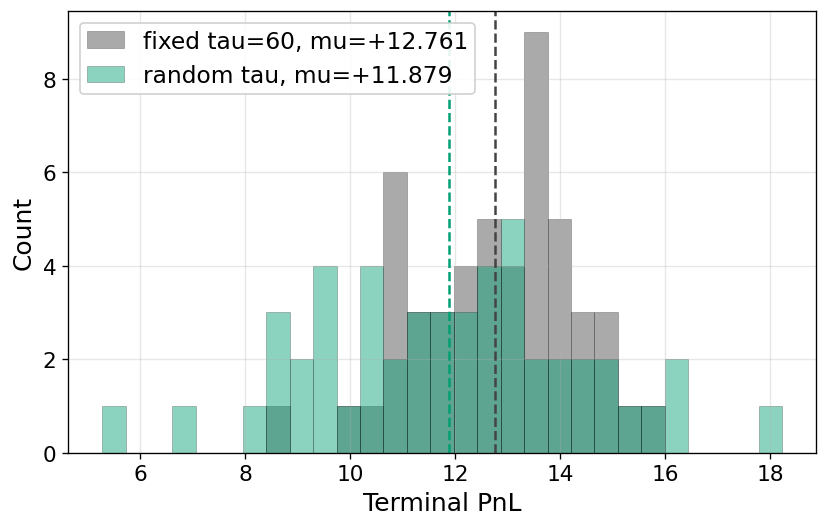

[CACHE SAVED] CELL_26_mc_phaseb_fixed_vs_random_tau_f92727af.pkl (0.0 MB)


In [19]:
# ----- CACHE CHECK -----
_cache_params = {
    'N_RANDOM_TAU_MC': globals().get('N_RANDOM_TAU_MC'),
    'RANDOM_TAU_MC_STEPS': globals().get('RANDOM_TAU_MC_STEPS'),
    'RANDOM_TAU_MC_EQUIL': globals().get('RANDOM_TAU_MC_EQUIL'),
    'RANDOM_TAU_GRID': globals().get('RANDOM_TAU_GRID'),
    'FIXED_TAU': globals().get('FIXED_TAU'),
    'GLOBAL_SEED': globals().get('GLOBAL_SEED'),
    'REGIME_P_LO': globals().get('REGIME_P_LO'),
    'REGIME_P_HI': globals().get('REGIME_P_HI'),
    'CHECKPOINT_PHASEB_NAME': getattr(globals().get('DQN_CHECKPOINT_PHASEB'), 'name', None) if globals().get('HAS_PHASEB') and globals().get('DQN_CHECKPOINT_PHASEB') is not None else None,
}
_cache_file = _cache_path("CELL_26_mc_phaseb_fixed_vs_random_tau", _cache_params)
_cached = _load_cache(_cache_file, force_refresh=FORCE_REFRESH_ALL)
if _cached is not None:
    (phaseb_fixed_tau_pnls, phaseb_random_tau_pnls, phaseb_fixed_tau_absinv, phaseb_random_tau_absinv, phaseb_fixed_tau_limit_frac, phaseb_random_tau_limit_frac, paired_diff) = _cached
else:
    from pathlib import Path
    # -- Monte Carlo: Phase B fixed tau=60 vs random tau per regime -----------

    import gc
    import time

    N_RANDOM_TAU_MC = 50
    RANDOM_TAU_MC_STEPS = 500_000
    RANDOM_TAU_MC_EQUIL = 10_000
    RANDOM_TAU_GRID = [15.0, 30.0, 60.0, 120.0, 240.0]
    FIXED_TAU = 60.0
    RANDOM_TAU_PROGRESS_EVERY = 1

    phaseb_fixed_tau_pnls = []
    phaseb_random_tau_pnls = []
    phaseb_fixed_tau_absinv = []
    phaseb_random_tau_absinv = []
    phaseb_fixed_tau_limit_frac = []
    phaseb_random_tau_limit_frac = []


    def _cleanup_phaseb_eval():
        if hasattr(ctrl_phaseb, "nstep_buffer"):
            ctrl_phaseb.nstep_buffer.clear()
        if "torch" in globals() and hasattr(torch, "cuda") and torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()


    def run_phaseb_metrics(buy_mo_prob, seed, run_label=None):
        if run_label is not None:
            print(f"    start {run_label}", flush=True)
        t0 = time.time()

        _, metrics = run_one_sim(
            buy_mo_prob=buy_mo_prob,
            seed=int(seed),
            controller=ctrl_phaseb,
            total_events=RANDOM_TAU_MC_STEPS,
            equil_steps=RANDOM_TAU_MC_EQUIL,
            signal_config=SIGNAL_PHASEB,
            metrics_only=True,
        )

        pnl = float(metrics["MM_TotalPnL"])
        mean_abs_inv = float(metrics["mean_abs_inventory"])
        limit_frac = float(metrics["limit_frac"])

        del metrics
        _cleanup_phaseb_eval()

        if run_label is not None:
            elapsed = time.time() - t0
            print(
                f"    done  {run_label}: pnl={pnl:+.4f}, "
                f"mean|q|={mean_abs_inv:.3f}, limit_frac={limit_frac:.4f}, "
                f"elapsed={elapsed:.1f}s",
                flush=True,
            )

        return pnl, mean_abs_inv, limit_frac


    for i in range(N_RANDOM_TAU_MC):
        seed_i = int(globals().get("GLOBAL_SEED", SEED)) + 500_000 + i
        print(f"\n[Phase B random-tau MC {i+1}/{N_RANDOM_TAU_MC}] seed={seed_i}", flush=True)

        sched_fixed_i = build_regime_schedule(
            total_events=RANDOM_TAU_MC_STEPS,
            seed=seed_i + 10_000_000,
            distribution="exponential",
            tau=FIXED_TAU,
        )

        sched_random_i = make_random_tau_regime_schedule(
            total_events=RANDOM_TAU_MC_STEPS,
            seed=seed_i + 20_000_000,
            tau_grid=RANDOM_TAU_GRID,
        )

        pnl_f, absinv_f, lim_f = run_phaseb_metrics(
            sched_fixed_i,
            seed_i,
            run_label=f"fixed tau={FIXED_TAU:g}",
        )
        pnl_r, absinv_r, lim_r = run_phaseb_metrics(
            sched_random_i,
            seed_i,
            run_label="random tau per regime",
        )

        phaseb_fixed_tau_pnls.append(pnl_f)
        phaseb_random_tau_pnls.append(pnl_r)
        phaseb_fixed_tau_absinv.append(absinv_f)
        phaseb_random_tau_absinv.append(absinv_r)
        phaseb_fixed_tau_limit_frac.append(lim_f)
        phaseb_random_tau_limit_frac.append(lim_r)

        del sched_fixed_i
        del sched_random_i
        gc.collect()

        if ((i + 1) % RANDOM_TAU_PROGRESS_EVERY == 0) or ((i + 1) == N_RANDOM_TAU_MC):
            fixed_mean = np.mean(phaseb_fixed_tau_pnls)
            random_mean = np.mean(phaseb_random_tau_pnls)
            diff_mean = np.mean(np.asarray(phaseb_random_tau_pnls) - np.asarray(phaseb_fixed_tau_pnls))
            print(
                f"  progress {i+1}/{N_RANDOM_TAU_MC} | "
                f"fixed mean={fixed_mean:+.4f} | random mean={random_mean:+.4f} | "
                f"random-fixed={diff_mean:+.4f}",
                flush=True,
            )

    phaseb_fixed_tau_pnls = np.asarray(phaseb_fixed_tau_pnls, dtype=float)
    phaseb_random_tau_pnls = np.asarray(phaseb_random_tau_pnls, dtype=float)
    phaseb_fixed_tau_absinv = np.asarray(phaseb_fixed_tau_absinv, dtype=float)
    phaseb_random_tau_absinv = np.asarray(phaseb_random_tau_absinv, dtype=float)
    phaseb_fixed_tau_limit_frac = np.asarray(phaseb_fixed_tau_limit_frac, dtype=float)
    phaseb_random_tau_limit_frac = np.asarray(phaseb_random_tau_limit_frac, dtype=float)

    paired_diff = phaseb_random_tau_pnls - phaseb_fixed_tau_pnls

    print("\nPhase B Monte Carlo summary")
    print(f"  fixed tau={FIXED_TAU:g}: mean PnL={phaseb_fixed_tau_pnls.mean():+.4f}, std={phaseb_fixed_tau_pnls.std(ddof=1):.4f}")
    print(f"  random tau    : mean PnL={phaseb_random_tau_pnls.mean():+.4f}, std={phaseb_random_tau_pnls.std(ddof=1):.4f}")
    print(f"  random - fixed: mean diff={paired_diff.mean():+.4f}, std={paired_diff.std(ddof=1):.4f}")
    print(f"  fixed mean |q|={phaseb_fixed_tau_absinv.mean():.4f}, limit frac={phaseb_fixed_tau_limit_frac.mean():.4f}")
    print(f"  random mean |q|={phaseb_random_tau_absinv.mean():.4f}, limit frac={phaseb_random_tau_limit_frac.mean():.4f}")

    fig, ax1 = plt.subplots(figsize=(7, 4.5))

    all_pnls = np.concatenate([phaseb_fixed_tau_pnls, phaseb_random_tau_pnls])
    bins = np.linspace(all_pnls.min() - 0.05, all_pnls.max() + 0.05, 30)

    ax1.hist(
        phaseb_fixed_tau_pnls,
        bins=bins,
        alpha=0.45,
        color="#444444",
        edgecolor="black",
        linewidth=0.3,
        label=f"fixed tau={FIXED_TAU:g}, mu={phaseb_fixed_tau_pnls.mean():+.3f}",
    )
    ax1.hist(
        phaseb_random_tau_pnls,
        bins=bins,
        alpha=0.45,
        color="#009E73",
        edgecolor="black",
        linewidth=0.3,
        label=f"random tau, mu={phaseb_random_tau_pnls.mean():+.3f}",
    )
    ax1.axvline(phaseb_fixed_tau_pnls.mean(), color="#444444", linestyle="--", linewidth=1.5)
    ax1.axvline(phaseb_random_tau_pnls.mean(), color="#009E73", linestyle="--", linewidth=1.5)
    # ax1.set_title("Phase B terminal PnL")  # supervisor: no inline titles; caption describes
    ax1.set_xlabel("Terminal PnL")
    ax1.set_ylabel("Count")
    ax1.legend(fontsize=14)
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()

    # ── Save for paper export ─────────────────────────────────────────────
    _LOCAL_FIG_PATH = Path("random_tau_stress.png")
    _PAPER_FIG_PATH = Path("/Users/felipemoret/Desktop/extended_first_abstract_RLMM/random_tau_stress.png")
    plt.savefig(_LOCAL_FIG_PATH, dpi=150, bbox_inches="tight")
    plt.savefig(_PAPER_FIG_PATH, dpi=150, bbox_inches="tight")
    print(f"[SAVE] random_tau_stress.png -> local + paper folder")

    plt.show()
    _save_cache(_cache_file, (phaseb_fixed_tau_pnls, phaseb_random_tau_pnls, phaseb_fixed_tau_absinv, phaseb_random_tau_absinv, phaseb_fixed_tau_limit_frac, phaseb_random_tau_limit_frac, paired_diff))
# ----- END CACHE -----



Fixed tau=60 natural regime table, first 12 regimes:
  k   mo_start   mo_end   length   tau_used   p_buy
   0         0       49      49     fixed  +0.630
   1        49       58       9     fixed  +0.679
   2        58       83      25     fixed  +0.675
   3        83      212     129     fixed  +0.268
   4       212      241      29     fixed  +0.554
   5       241      245       4     fixed  +0.383
   6       245      298      53     fixed  +0.307
   7       298      300       2     fixed  +0.748
   8       300      318      18     fixed  +0.618
   9       318      325       7     fixed  +0.657
  10       325      363      38     fixed  +0.483
  11       363      418      55     fixed  +0.608

Persistent-side fixed-p order-flow intensity stress regime table, first 12 regimes:
  k   mo_start   mo_end   length   tau   side   intensity   mean_p   min_p   max_p
   0         0       41      41    60     -      0.071   +0.429  +0.429  +0.429
   1        41       49       8    15     -   

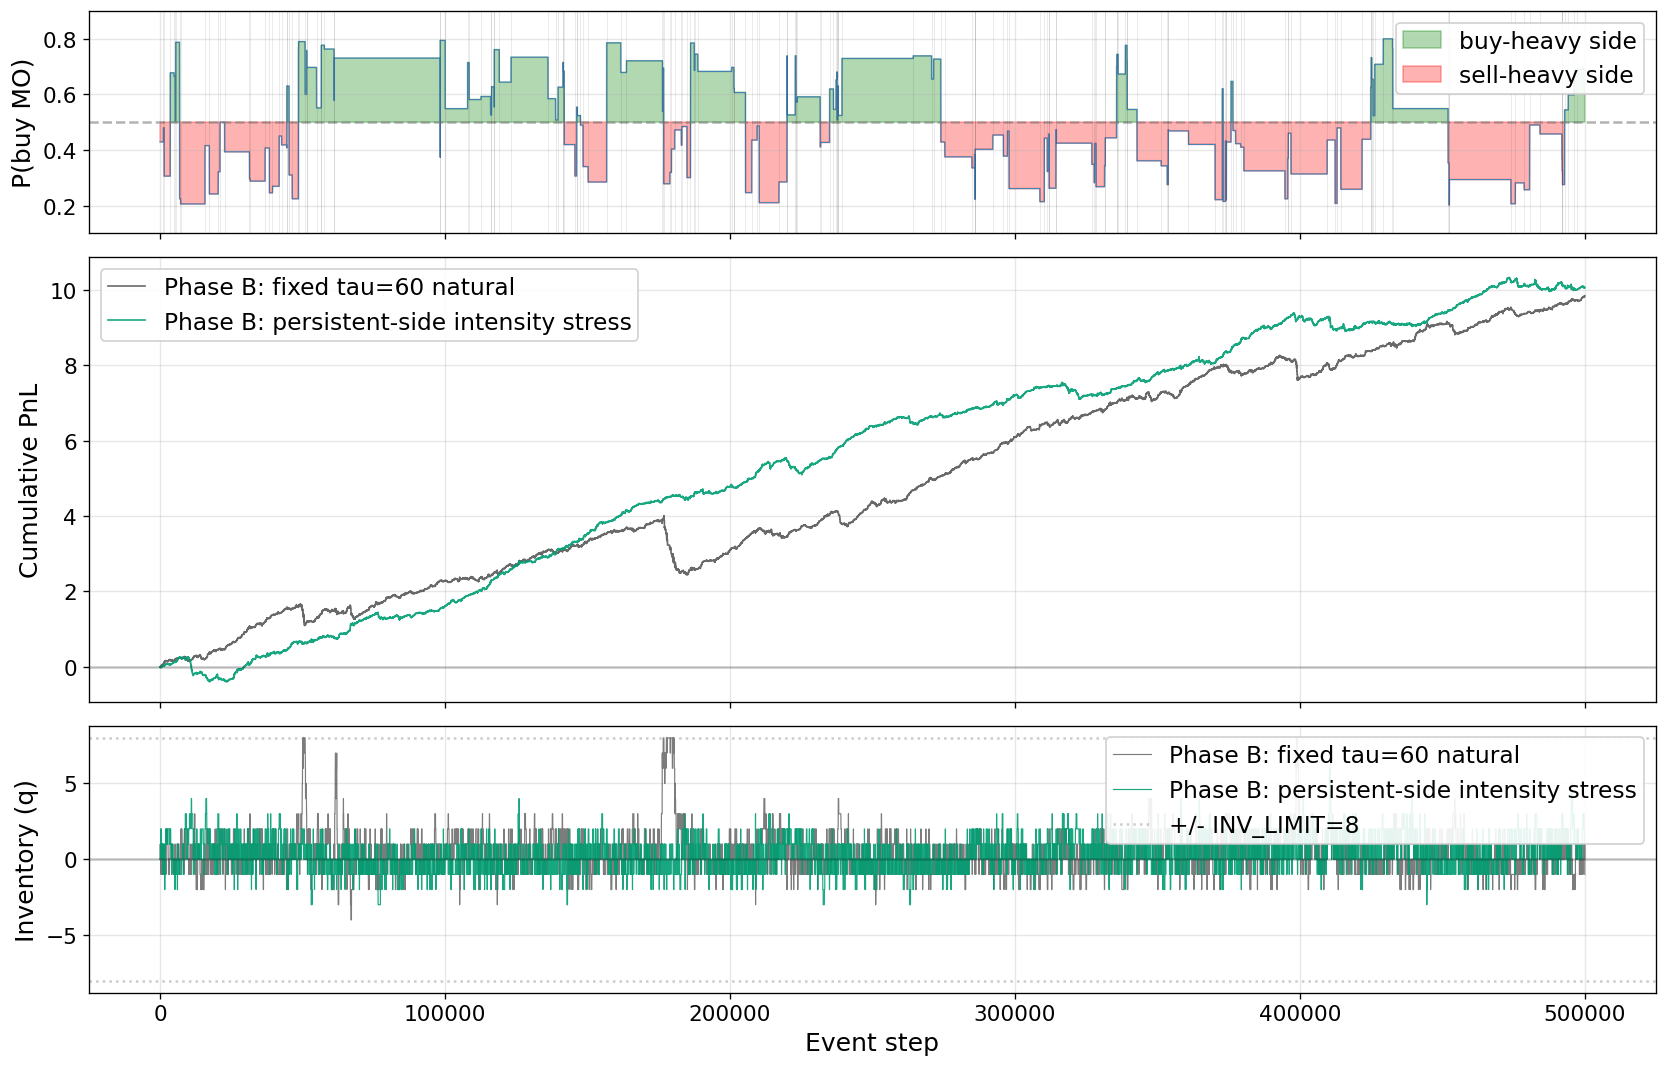


Final PnL  --  Phase B fixed tau=60 natural: +9.8450  |  Phase B persistent-side fixed-p intensity stress: +10.0600


In [20]:
# -- Phase B single episode: persistent-side fixed-p order-flow intensity stress ----

import gc
import time

CLUSTERED_TAU_GRID = [15.0, 30.0, 60.0, 120.0, 240.0]
CLUSTERED_RHO = 0.85                    # probabilidade de manter o mesmo lado do regime anterior
CLUSTERED_CHUNK_LEN_MO = None           # None = p_buy fixo dentro de cada regime
ORDER_FLOW_INTENSITY_LOW = 0.0         # intensity = |p_buy - 0.5|
ORDER_FLOW_INTENSITY_HIGH = 0.30        # max imbalance; p_buy stays in [0.2, 0.8]
CLUSTERED_STRESS_STEPS = 500_000
CLUSTERED_STRESS_EQUIL = 10_000
CLUSTERED_STRESS_TRACE_POINTS = None
CLUSTERED_STRESS_SEED = int(globals().get("GLOBAL_SEED", SEED)) + 900_000

assert HAS_PHASEB, "Phase B checkpoint/controller is required for this diagnostic."


def _trace_points_for_plot(total_events):
    if CLUSTERED_STRESS_TRACE_POINTS is None:
        return int(total_events)
    return int(CLUSTERED_STRESS_TRACE_POINTS)


def make_clustered_intensity_regime_schedule(
    total_events,
    seed,
    tau_grid=CLUSTERED_TAU_GRID,
    rho=CLUSTERED_RHO,
    chunk_len_mo=CLUSTERED_CHUNK_LEN_MO,
    intensity_low=ORDER_FLOW_INTENSITY_LOW,
    intensity_high=ORDER_FLOW_INTENSITY_HIGH,
):
    rng = np.random.default_rng(int(seed))
    n_mo_events = estimate_expected_mo_events(total_events)

    tau_grid = np.asarray(tau_grid, dtype=float)
    intensity_low = float(intensity_low)
    intensity_high = float(intensity_high)

    if chunk_len_mo is None:
        chunk_len_mo_eff = None
    else:
        chunk_len_mo_eff = max(1, int(chunk_len_mo))

    if rho is not None:
        rho = float(rho)
        if not (0.0 <= rho <= 1.0):
            raise ValueError(f"Require rho in [0, 1] or None, got {rho}")

    if not (0.0 <= intensity_low <= intensity_high <= 0.5):
        raise ValueError(
            f"Require 0 <= intensity_low <= intensity_high <= 0.5, "
            f"got {intensity_low}, {intensity_high}"
        )

    boundaries = [0]
    tau_values = []
    lengths = []
    sides = []
    p_values = []
    intensity_values = []

    chunk_boundaries = [0]
    chunk_p_values = []
    chunk_intensity_values = []
    chunk_regime_idx = []

    boundaries_arr = np.asarray(boundaries, dtype=int)
    chunk_boundaries_arr = np.asarray(chunk_boundaries, dtype=int)
    chunk_p_values_arr = np.asarray(chunk_p_values, dtype=float)

    current_side = int(rng.choice([-1, 1]))

    def _refresh_arrays():
        nonlocal boundaries_arr, chunk_boundaries_arr, chunk_p_values_arr
        boundaries_arr = np.asarray(boundaries, dtype=int)
        chunk_boundaries_arr = np.asarray(chunk_boundaries, dtype=int)
        chunk_p_values_arr = np.asarray(chunk_p_values, dtype=float)

    def _sample_p_buy_for_side(side):
        intensity = float(rng.uniform(intensity_low, intensity_high))
        p_buy = float(np.clip(0.5 + int(side) * intensity, 0.0, 1.0))
        return p_buy, intensity

    def _append_regime():
        nonlocal current_side

        regime_idx = len(tau_values)

        if regime_idx == 0:
            current_side = int(rng.choice([-1, 1]))
        elif rho is None:
            current_side = int(rng.choice([-1, 1]))
        elif rng.random() >= rho:
            current_side *= -1

        tau = float(rng.choice(tau_grid))
        length = max(1, int(np.ceil(rng.exponential(tau))))
        start = int(boundaries[-1])
        end = start + length

        local_ps = []
        local_intensities = []

        if chunk_len_mo_eff is None:
            # One order-flow intensity and one p_buy for the whole regime.
            p_buy, intensity = _sample_p_buy_for_side(current_side)

            if chunk_boundaries[-1] != start:
                chunk_boundaries.append(start)
            chunk_boundaries.append(end)

            chunk_p_values.append(p_buy)
            chunk_intensity_values.append(intensity)
            chunk_regime_idx.append(regime_idx)
            local_ps.append(p_buy)
            local_intensities.append(intensity)

        else:
            # Order-flow intensity changes every chunk_len_mo market orders.
            chunk_start = start
            while chunk_start < end:
                chunk_end = min(end, chunk_start + chunk_len_mo_eff)
                p_buy, intensity = _sample_p_buy_for_side(current_side)

                if chunk_boundaries[-1] != chunk_start:
                    chunk_boundaries.append(chunk_start)
                chunk_boundaries.append(chunk_end)

                chunk_p_values.append(p_buy)
                chunk_intensity_values.append(intensity)
                chunk_regime_idx.append(regime_idx)
                local_ps.append(p_buy)
                local_intensities.append(intensity)

                chunk_start = chunk_end

        boundaries.append(end)
        tau_values.append(tau)
        lengths.append(length)
        sides.append(current_side)
        p_values.append(float(np.mean(local_ps)))
        intensity_values.append(float(np.mean(local_intensities)))
        _refresh_arrays()

    while boundaries[-1] < n_mo_events + 1000:
        _append_regime()

    def schedule(mo_idx):
        mo_idx = int(mo_idx)
        while mo_idx >= chunk_boundaries[-1]:
            _append_regime()

        chunk_idx = int(np.searchsorted(chunk_boundaries_arr, mo_idx, side="right")) - 1
        chunk_idx = min(max(chunk_idx, 0), len(chunk_p_values_arr) - 1)
        return float(chunk_p_values_arr[chunk_idx])

    schedule.boundaries = boundaries
    schedule.tau_values = tau_values
    schedule.lengths = lengths
    schedule.sides = sides
    schedule.p_values = p_values
    schedule.intensity_values = intensity_values
    schedule.chunk_boundaries = chunk_boundaries
    schedule.chunk_p_values = chunk_p_values
    schedule.chunk_intensity_values = chunk_intensity_values
    schedule.chunk_regime_idx = chunk_regime_idx
    schedule.tau_grid = list(map(float, tau_grid))
    schedule.rho = rho
    schedule.chunk_len_mo = chunk_len_mo
    schedule.intensity_low = intensity_low
    schedule.intensity_high = intensity_high

    return schedule


def p_buy_on_event_steps(schedule, event_steps):
    event_steps = np.asarray(event_steps, dtype=float)
    mo_idx_proxy = np.floor(event_steps * MO_EVENT_FRACTION).astype(int)
    return np.asarray([schedule(int(j)) for j in mo_idx_proxy], dtype=float)


def print_clustered_regime_table(schedule, name, max_rows=12):
    print(f"\n{name} regime table, first {max_rows} regimes:")
    print("  k   mo_start   mo_end   length   tau   side   intensity   mean_p   min_p   max_p")

    chunk_regime_idx = np.asarray(schedule.chunk_regime_idx, dtype=int)
    chunk_p_values = np.asarray(schedule.chunk_p_values, dtype=float)

    for k in range(min(max_rows, len(schedule.p_values))):
        mask = chunk_regime_idx == k
        ps = chunk_p_values[mask]
        side_txt = "+" if schedule.sides[k] > 0 else "-"

        print(
            f"  {k:2d}  "
            f"{schedule.boundaries[k]:8d}  "
            f"{schedule.boundaries[k + 1]:7d}  "
            f"{schedule.lengths[k]:6d}  "
            f"{schedule.tau_values[k]:4.0f}  "
            f"{side_txt:>4}  "
            f"{schedule.intensity_values[k]:9.3f}  "
            f"{schedule.p_values[k]:+7.3f}  "
            f"{ps.min():+6.3f}  "
            f"{ps.max():+6.3f}"
        )


def _cleanup_clustered_phaseb_eval():
    if hasattr(ctrl_phaseb, "nstep_buffer"):
        ctrl_phaseb.nstep_buffer.clear()
    if "torch" in globals() and hasattr(torch, "cuda") and torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()


def run_phaseb_trace_metrics(buy_mo_prob, seed, label):
    print(f"Running Phase B under {label}...", flush=True)
    t0 = time.time()

    _, metrics = run_one_sim(
        buy_mo_prob=buy_mo_prob,
        seed=int(seed),
        controller=ctrl_phaseb,
        total_events=CLUSTERED_STRESS_STEPS,
        equil_steps=CLUSTERED_STRESS_EQUIL,
        signal_config=SIGNAL_PHASEB,
        metrics_only=True,
        metrics_trace_max_points=_trace_points_for_plot(CLUSTERED_STRESS_STEPS),
    )

    elapsed = time.time() - t0
    print(
        f"  Done. Final PnL={float(metrics['MM_TotalPnL']):+.4f}, "
        f"mean|q|={float(metrics['mean_abs_inventory']):.3f}, "
        f"limit_frac={float(metrics['limit_frac']):.4f}, elapsed={elapsed:.1f}s",
        flush=True,
    )

    _cleanup_clustered_phaseb_eval()
    return metrics


sched_fixed_tau60_cluster_ref = build_regime_schedule(
    total_events=CLUSTERED_STRESS_STEPS,
    seed=CLUSTERED_STRESS_SEED + 1,
    distribution="exponential",
    tau=60.0,
)

sched_clustered_intensity = make_clustered_intensity_regime_schedule(
    total_events=CLUSTERED_STRESS_STEPS,
    seed=CLUSTERED_STRESS_SEED + 2,
    tau_grid=CLUSTERED_TAU_GRID,
    rho=CLUSTERED_RHO,
    chunk_len_mo=CLUSTERED_CHUNK_LEN_MO,
    intensity_low=ORDER_FLOW_INTENSITY_LOW,
    intensity_high=ORDER_FLOW_INTENSITY_HIGH,
)

print_regime_table(sched_fixed_tau60_cluster_ref, "Fixed tau=60 natural")
print_clustered_regime_table(sched_clustered_intensity, "Persistent-side fixed-p order-flow intensity stress")

metrics_phaseb_fixed_tau_cluster_ref = run_phaseb_trace_metrics(
    sched_fixed_tau60_cluster_ref,
    CLUSTERED_STRESS_SEED,
    "fixed tau=60 natural regime",
)

metrics_phaseb_clustered_intensity = run_phaseb_trace_metrics(
    sched_clustered_intensity,
    CLUSTERED_STRESS_SEED,
    "persistent-side fixed-p order-flow intensity stress",
)

steps_fixed = np.asarray(metrics_phaseb_fixed_tau_cluster_ref["trace_step"], dtype=int)
steps_clustered = np.asarray(metrics_phaseb_clustered_intensity["trace_step"], dtype=int)
n_plot = min(len(steps_fixed), len(steps_clustered))

if n_plot == 0:
    raise RuntimeError("No trace points were collected.")

steps = steps_clustered[:n_plot]
p_clustered_steps = p_buy_on_event_steps(sched_clustered_intensity, steps)

pnl_fixed = np.asarray(metrics_phaseb_fixed_tau_cluster_ref["trace_pnl"], dtype=float)[:n_plot]
pnl_clustered = np.asarray(metrics_phaseb_clustered_intensity["trace_pnl"], dtype=float)[:n_plot]
inv_fixed = np.asarray(metrics_phaseb_fixed_tau_cluster_ref["trace_inventory"], dtype=float)[:n_plot]
inv_clustered = np.asarray(metrics_phaseb_clustered_intensity["trace_inventory"], dtype=float)[:n_plot]

fig, (ax1, ax2, ax3) = plt.subplots(
    3,
    1,
    figsize=(14, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [1, 2, 1.2]},
)

ax1.fill_between(
    steps,
    0.5,
    p_clustered_steps,
    where=p_clustered_steps > 0.5,
    alpha=0.3,
    color="green",
    label="buy-heavy side",
)
ax1.fill_between(
    steps,
    0.5,
    p_clustered_steps,
    where=p_clustered_steps < 0.5,
    alpha=0.3,
    color="red",
    label="sell-heavy side",
)
ax1.plot(steps, p_clustered_steps, linewidth=0.7, color="steelblue")
ax1.axhline(y=0.5, color="gray", linestyle="--", alpha=0.6)

for boundary in sched_clustered_intensity.boundaries[1:]:
    x_boundary = boundary / max(MO_EVENT_FRACTION, 1e-12)
    if steps[0] <= x_boundary <= steps[-1]:
        ax1.axvline(x_boundary, color="black", alpha=0.08, linewidth=0.6)

rho_txt = "independent" if CLUSTERED_RHO is None else f"rho={CLUSTERED_RHO:.2f}"
chunk_txt = "fixed within regime" if CLUSTERED_CHUNK_LEN_MO is None else f"chunk={CLUSTERED_CHUNK_LEN_MO} MOs"

ax1.set_ylabel("P(buy MO)")
ax1.set_ylim(0.1, 0.9)
# ax1.set_title(  # supervisor: no inline titles; caption describes
    # "Persistent-side fixed-p order-flow intensity stress "
    # f"({rho_txt}, {chunk_txt}, intensity in "
    # f"[{ORDER_FLOW_INTENSITY_LOW:.2f}, {ORDER_FLOW_INTENSITY_HIGH:.2f}])"
# )
ax1.legend(loc="upper right", fontsize=14)
ax1.grid(True, alpha=0.3)

ax2.plot(
    steps,
    pnl_fixed,
    linewidth=1.0,
    color="#444444",
    alpha=0.8,
    label="Phase B: fixed tau=60 natural",
)
ax2.plot(
    steps,
    pnl_clustered,
    linewidth=1.0,
    color="#009E73",
    alpha=0.9,
    label="Phase B: persistent-side intensity stress",
)
ax2.axhline(y=0, color="black", linestyle="-", alpha=0.2)
ax2.set_ylabel("Cumulative PnL")
# ax2.set_title("Phase B under persistent-side fixed-p order-flow intensity stress")  # supervisor: no inline titles; caption describes
ax2.legend(loc="upper left", fontsize=14)
ax2.grid(True, alpha=0.3)

ax3.plot(
    steps,
    inv_fixed,
    linewidth=0.7,
    color="#444444",
    alpha=0.7,
    label="Phase B: fixed tau=60 natural",
)
ax3.plot(
    steps,
    inv_clustered,
    linewidth=0.7,
    color="#009E73",
    alpha=0.9,
    label="Phase B: persistent-side intensity stress",
)
ax3.axhline(y=0, color="black", linestyle="-", alpha=0.2)
ax3.axhline(y=INV_LIMIT, color="gray", linestyle=":", alpha=0.4, label=f"+/- INV_LIMIT={INV_LIMIT}")
ax3.axhline(y=-INV_LIMIT, color="gray", linestyle=":", alpha=0.4)
ax3.set_ylabel("Inventory (q)")
ax3.set_xlabel("Event step")
# ax3.set_title("Phase B inventory trajectory")  # supervisor: no inline titles; caption describes
ax3.legend(loc="upper right", fontsize=14)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(
    "\nFinal PnL  --  "
    f"Phase B fixed tau=60 natural: {float(metrics_phaseb_fixed_tau_cluster_ref['MM_TotalPnL']):+.4f}  |  "
    f"Phase B persistent-side fixed-p intensity stress: "
    f"{float(metrics_phaseb_clustered_intensity['MM_TotalPnL']):+.4f}"
)



[Phase B clustered-intensity MC 1/50] seed=700123
    start fixed tau=60
    done  fixed tau=60: pnl=+12.9000, mean|q|=0.824, limit_frac=0.0000, elapsed=140.3s
    start persistent-side stress rho=0.85
    done  persistent-side stress rho=0.85: pnl=+12.8150, mean|q|=0.854, limit_frac=0.0002, elapsed=133.1s
  progress 1/50 | fixed mean=+12.9000 | stress mean=+12.8150 | stress-fixed=-0.0850

[Phase B clustered-intensity MC 2/50] seed=700124
    start fixed tau=60
    done  fixed tau=60: pnl=+14.4800, mean|q|=0.819, limit_frac=0.0000, elapsed=138.8s
    start persistent-side stress rho=0.85
    done  persistent-side stress rho=0.85: pnl=+12.7050, mean|q|=0.823, limit_frac=0.0004, elapsed=132.6s
  progress 2/50 | fixed mean=+13.6900 | stress mean=+12.7600 | stress-fixed=-0.9300

[Phase B clustered-intensity MC 3/50] seed=700125
    start fixed tau=60
    done  fixed tau=60: pnl=+10.5650, mean|q|=0.905, limit_frac=0.0062, elapsed=148.1s
    start persistent-side stress rho=0.85
    done  p

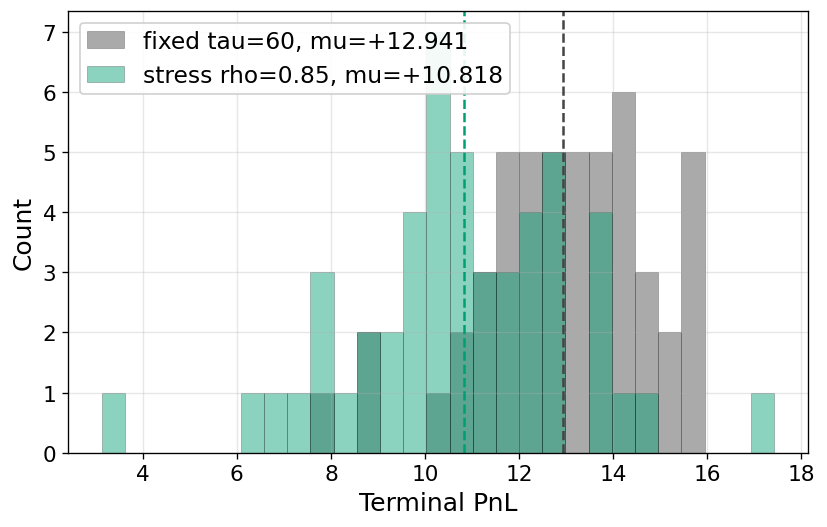

[CACHE SAVED] CELL_28_mc_phaseb_persistent_side_d804fbb3.pkl (0.0 MB)


In [21]:
# ----- CACHE CHECK -----
_cache_params = {
    'N_CLUSTERED_INTENSITY_MC': globals().get('N_CLUSTERED_INTENSITY_MC'),
    'CLUSTERED_INTENSITY_MC_STEPS': globals().get('CLUSTERED_INTENSITY_MC_STEPS'),
    'CLUSTERED_INTENSITY_MC_EQUIL': globals().get('CLUSTERED_INTENSITY_MC_EQUIL'),
    'FIXED_TAU': globals().get('FIXED_TAU'),
    'CLUSTERED_TAU_GRID': globals().get('CLUSTERED_TAU_GRID'),
    'CLUSTERED_RHO': globals().get('CLUSTERED_RHO'),
    'CLUSTERED_CHUNK_LEN_MO': globals().get('CLUSTERED_CHUNK_LEN_MO'),
    'ORDER_FLOW_INTENSITY_LOW': globals().get('ORDER_FLOW_INTENSITY_LOW'),
    'ORDER_FLOW_INTENSITY_HIGH': globals().get('ORDER_FLOW_INTENSITY_HIGH'),
    'GLOBAL_SEED': globals().get('GLOBAL_SEED'),
    'CHECKPOINT_PHASEB_NAME': getattr(globals().get('DQN_CHECKPOINT_PHASEB'), 'name', None) if globals().get('HAS_PHASEB') and globals().get('DQN_CHECKPOINT_PHASEB') is not None else None,
}
_cache_file = _cache_path("CELL_28_mc_phaseb_persistent_side", _cache_params)
_cached = _load_cache(_cache_file, force_refresh=FORCE_REFRESH_ALL)
if _cached is not None:
    (phaseb_fixed_tau_pnls, phaseb_clustered_pnls, phaseb_fixed_tau_absinv, phaseb_clustered_absinv, phaseb_fixed_tau_limit_frac, phaseb_clustered_limit_frac, paired_diff) = _cached
else:
    from pathlib import Path
    # -- Monte Carlo: Phase B fixed tau=60 vs persistent-side intensity stress ----

    import gc
    import time

    N_CLUSTERED_INTENSITY_MC = 50
    CLUSTERED_INTENSITY_MC_STEPS = 500_000
    CLUSTERED_INTENSITY_MC_EQUIL = 10_000

    FIXED_TAU = 60.0
    CLUSTERED_TAU_GRID = [15.0, 30.0, 60.0, 120.0, 240.0]
    CLUSTERED_RHO = 0.85
    CLUSTERED_CHUNK_LEN_MO = None           # None = p_buy fixo dentro de cada regime
    ORDER_FLOW_INTENSITY_LOW = 0.0          # same marginal intensity support as Phase B
    ORDER_FLOW_INTENSITY_HIGH = 0.30        # p_buy in [0.2, 0.8]
    CLUSTERED_INTENSITY_PROGRESS_EVERY = 1

    phaseb_fixed_tau_pnls = []
    phaseb_clustered_pnls = []
    phaseb_fixed_tau_absinv = []
    phaseb_clustered_absinv = []
    phaseb_fixed_tau_limit_frac = []
    phaseb_clustered_limit_frac = []


    def make_clustered_intensity_regime_schedule(
        total_events,
        seed,
        tau_grid=CLUSTERED_TAU_GRID,
        rho=CLUSTERED_RHO,
        chunk_len_mo=CLUSTERED_CHUNK_LEN_MO,
        intensity_low=ORDER_FLOW_INTENSITY_LOW,
        intensity_high=ORDER_FLOW_INTENSITY_HIGH,
    ):
        rng = np.random.default_rng(int(seed))
        n_mo_events = estimate_expected_mo_events(total_events)

        tau_grid = np.asarray(tau_grid, dtype=float)
        intensity_low = float(intensity_low)
        intensity_high = float(intensity_high)

        if chunk_len_mo is None:
            chunk_len_mo_eff = None
        else:
            chunk_len_mo_eff = max(1, int(chunk_len_mo))

        if rho is not None:
            rho = float(rho)
            if not (0.0 <= rho <= 1.0):
                raise ValueError(f"Require rho in [0, 1] or None, got {rho}")

        if not (0.0 <= intensity_low <= intensity_high <= 0.5):
            raise ValueError(
                f"Require 0 <= intensity_low <= intensity_high <= 0.5, "
                f"got {intensity_low}, {intensity_high}"
            )

        boundaries = [0]
        tau_values = []
        lengths = []
        sides = []
        p_values = []
        intensity_values = []

        chunk_boundaries = [0]
        chunk_p_values = []
        chunk_intensity_values = []
        chunk_regime_idx = []

        chunk_boundaries_arr = np.asarray(chunk_boundaries, dtype=int)
        chunk_p_values_arr = np.asarray(chunk_p_values, dtype=float)

        current_side = int(rng.choice([-1, 1]))

        def _refresh_arrays():
            nonlocal chunk_boundaries_arr, chunk_p_values_arr
            chunk_boundaries_arr = np.asarray(chunk_boundaries, dtype=int)
            chunk_p_values_arr = np.asarray(chunk_p_values, dtype=float)

        def _sample_p_buy_for_side(side):
            intensity = float(rng.uniform(intensity_low, intensity_high))
            p_buy = float(np.clip(0.5 + int(side) * intensity, 0.0, 1.0))
            return p_buy, intensity

        def _append_regime():
            nonlocal current_side

            regime_idx = len(tau_values)

            if regime_idx == 0:
                current_side = int(rng.choice([-1, 1]))
            elif rho is None:
                current_side = int(rng.choice([-1, 1]))
            elif rng.random() >= rho:
                current_side *= -1

            tau = float(rng.choice(tau_grid))
            length = max(1, int(np.ceil(rng.exponential(tau))))
            start = int(boundaries[-1])
            end = start + length

            local_ps = []
            local_intensities = []

            if chunk_len_mo_eff is None:
                p_buy, intensity = _sample_p_buy_for_side(current_side)

                if chunk_boundaries[-1] != start:
                    chunk_boundaries.append(start)
                chunk_boundaries.append(end)

                chunk_p_values.append(p_buy)
                chunk_intensity_values.append(intensity)
                chunk_regime_idx.append(regime_idx)
                local_ps.append(p_buy)
                local_intensities.append(intensity)

            else:
                chunk_start = start
                while chunk_start < end:
                    chunk_end = min(end, chunk_start + chunk_len_mo_eff)
                    p_buy, intensity = _sample_p_buy_for_side(current_side)

                    if chunk_boundaries[-1] != chunk_start:
                        chunk_boundaries.append(chunk_start)
                    chunk_boundaries.append(chunk_end)

                    chunk_p_values.append(p_buy)
                    chunk_intensity_values.append(intensity)
                    chunk_regime_idx.append(regime_idx)
                    local_ps.append(p_buy)
                    local_intensities.append(intensity)

                    chunk_start = chunk_end

            boundaries.append(end)
            tau_values.append(tau)
            lengths.append(length)
            sides.append(current_side)
            p_values.append(float(np.mean(local_ps)))
            intensity_values.append(float(np.mean(local_intensities)))
            _refresh_arrays()

        while boundaries[-1] < n_mo_events + 1000:
            _append_regime()

        def schedule(mo_idx):
            mo_idx = int(mo_idx)
            while mo_idx >= chunk_boundaries[-1]:
                _append_regime()

            chunk_idx = int(np.searchsorted(chunk_boundaries_arr, mo_idx, side="right")) - 1
            chunk_idx = min(max(chunk_idx, 0), len(chunk_p_values_arr) - 1)
            return float(chunk_p_values_arr[chunk_idx])

        schedule.boundaries = boundaries
        schedule.tau_values = tau_values
        schedule.lengths = lengths
        schedule.sides = sides
        schedule.p_values = p_values
        schedule.intensity_values = intensity_values
        schedule.chunk_boundaries = chunk_boundaries
        schedule.chunk_p_values = chunk_p_values
        schedule.chunk_intensity_values = chunk_intensity_values
        schedule.chunk_regime_idx = chunk_regime_idx
        schedule.tau_grid = list(map(float, tau_grid))
        schedule.rho = rho
        schedule.chunk_len_mo = chunk_len_mo
        schedule.intensity_low = intensity_low
        schedule.intensity_high = intensity_high

        return schedule


    def _cleanup_phaseb_eval():
        if hasattr(ctrl_phaseb, "nstep_buffer"):
            ctrl_phaseb.nstep_buffer.clear()
        if "torch" in globals() and hasattr(torch, "cuda") and torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()


    def run_phaseb_metrics(buy_mo_prob, seed, run_label=None):
        if run_label is not None:
            print(f"    start {run_label}", flush=True)
        t0 = time.time()

        _, metrics = run_one_sim(
            buy_mo_prob=buy_mo_prob,
            seed=int(seed),
            controller=ctrl_phaseb,
            total_events=CLUSTERED_INTENSITY_MC_STEPS,
            equil_steps=CLUSTERED_INTENSITY_MC_EQUIL,
            signal_config=SIGNAL_PHASEB,
            metrics_only=True,
        )

        pnl = float(metrics["MM_TotalPnL"])
        mean_abs_inv = float(metrics["mean_abs_inventory"])
        limit_frac = float(metrics["limit_frac"])

        del metrics
        _cleanup_phaseb_eval()

        if run_label is not None:
            elapsed = time.time() - t0
            print(
                f"    done  {run_label}: pnl={pnl:+.4f}, "
                f"mean|q|={mean_abs_inv:.3f}, limit_frac={limit_frac:.4f}, "
                f"elapsed={elapsed:.1f}s",
                flush=True,
            )

        return pnl, mean_abs_inv, limit_frac


    assert HAS_PHASEB, "Phase B checkpoint/controller is required for this diagnostic."

    for i in range(N_CLUSTERED_INTENSITY_MC):
        seed_i = int(globals().get("GLOBAL_SEED", SEED)) + 700_000 + i
        print(f"\n[Phase B clustered-intensity MC {i+1}/{N_CLUSTERED_INTENSITY_MC}] seed={seed_i}", flush=True)

        sched_fixed_i = build_regime_schedule(
            total_events=CLUSTERED_INTENSITY_MC_STEPS,
            seed=seed_i + 10_000_000,
            distribution="exponential",
            tau=FIXED_TAU,
        )

        sched_clustered_i = make_clustered_intensity_regime_schedule(
            total_events=CLUSTERED_INTENSITY_MC_STEPS,
            seed=seed_i + 20_000_000,
            tau_grid=CLUSTERED_TAU_GRID,
            rho=CLUSTERED_RHO,
            chunk_len_mo=CLUSTERED_CHUNK_LEN_MO,
            intensity_low=ORDER_FLOW_INTENSITY_LOW,
            intensity_high=ORDER_FLOW_INTENSITY_HIGH,
        )

        pnl_f, absinv_f, lim_f = run_phaseb_metrics(
            sched_fixed_i,
            seed_i,
            run_label=f"fixed tau={FIXED_TAU:g}",
        )
        pnl_c, absinv_c, lim_c = run_phaseb_metrics(
            sched_clustered_i,
            seed_i,
            run_label=f"persistent-side stress rho={CLUSTERED_RHO:.2f}",
        )

        phaseb_fixed_tau_pnls.append(pnl_f)
        phaseb_clustered_pnls.append(pnl_c)
        phaseb_fixed_tau_absinv.append(absinv_f)
        phaseb_clustered_absinv.append(absinv_c)
        phaseb_fixed_tau_limit_frac.append(lim_f)
        phaseb_clustered_limit_frac.append(lim_c)

        del sched_fixed_i
        del sched_clustered_i
        gc.collect()

        if ((i + 1) % CLUSTERED_INTENSITY_PROGRESS_EVERY == 0) or ((i + 1) == N_CLUSTERED_INTENSITY_MC):
            fixed_mean = np.mean(phaseb_fixed_tau_pnls)
            stress_mean = np.mean(phaseb_clustered_pnls)
            diff_mean = np.mean(np.asarray(phaseb_clustered_pnls) - np.asarray(phaseb_fixed_tau_pnls))
            print(
                f"  progress {i+1}/{N_CLUSTERED_INTENSITY_MC} | "
                f"fixed mean={fixed_mean:+.4f} | stress mean={stress_mean:+.4f} | "
                f"stress-fixed={diff_mean:+.4f}",
                flush=True,
            )

    phaseb_fixed_tau_pnls = np.asarray(phaseb_fixed_tau_pnls, dtype=float)
    phaseb_clustered_pnls = np.asarray(phaseb_clustered_pnls, dtype=float)
    phaseb_fixed_tau_absinv = np.asarray(phaseb_fixed_tau_absinv, dtype=float)
    phaseb_clustered_absinv = np.asarray(phaseb_clustered_absinv, dtype=float)
    phaseb_fixed_tau_limit_frac = np.asarray(phaseb_fixed_tau_limit_frac, dtype=float)
    phaseb_clustered_limit_frac = np.asarray(phaseb_clustered_limit_frac, dtype=float)

    paired_diff = phaseb_clustered_pnls - phaseb_fixed_tau_pnls

    print("\nPhase B clustered-intensity Monte Carlo summary")
    print(f"  fixed tau={FIXED_TAU:g}: mean PnL={phaseb_fixed_tau_pnls.mean():+.4f}, std={phaseb_fixed_tau_pnls.std(ddof=1):.4f}")
    print(f"  clustered stress: mean PnL={phaseb_clustered_pnls.mean():+.4f}, std={phaseb_clustered_pnls.std(ddof=1):.4f}")
    print(f"  stress - fixed : mean diff={paired_diff.mean():+.4f}, std={paired_diff.std(ddof=1):.4f}")
    print(f"  fixed mean |q|={phaseb_fixed_tau_absinv.mean():.4f}, limit frac={phaseb_fixed_tau_limit_frac.mean():.4f}")
    print(f"  stress mean |q|={phaseb_clustered_absinv.mean():.4f}, limit frac={phaseb_clustered_limit_frac.mean():.4f}")

    fig, ax1 = plt.subplots(figsize=(7, 4.5))

    all_pnls = np.concatenate([phaseb_fixed_tau_pnls, phaseb_clustered_pnls])
    bins = np.linspace(all_pnls.min() - 0.05, all_pnls.max() + 0.05, 30)

    ax1.hist(
        phaseb_fixed_tau_pnls,
        bins=bins,
        alpha=0.45,
        color="#444444",
        edgecolor="black",
        linewidth=0.3,
        label=f"fixed tau={FIXED_TAU:g}, mu={phaseb_fixed_tau_pnls.mean():+.3f}",
    )
    ax1.hist(
        phaseb_clustered_pnls,
        bins=bins,
        alpha=0.45,
        color="#009E73",
        edgecolor="black",
        linewidth=0.3,
        label=f"stress rho={CLUSTERED_RHO:.2f}, mu={phaseb_clustered_pnls.mean():+.3f}",
    )
    ax1.axvline(phaseb_fixed_tau_pnls.mean(), color="#444444", linestyle="--", linewidth=1.5)
    ax1.axvline(phaseb_clustered_pnls.mean(), color="#009E73", linestyle="--", linewidth=1.5)
    # ax1.set_title("Phase B terminal PnL")  # supervisor: no inline titles; caption describes
    ax1.set_xlabel("Terminal PnL")
    ax1.set_ylabel("Count")
    ax1.legend(fontsize=14)
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()

    # ── Save for paper export ─────────────────────────────────────────────
    _LOCAL_FIG_PATH = Path("correlated_regime_stress.png")
    _PAPER_FIG_PATH = Path("/Users/felipemoret/Desktop/extended_first_abstract_RLMM/correlated_regime_stress.png")
    plt.savefig(_LOCAL_FIG_PATH, dpi=150, bbox_inches="tight")
    plt.savefig(_PAPER_FIG_PATH, dpi=150, bbox_inches="tight")
    print(f"[SAVE] correlated_regime_stress.png -> local + paper folder")

    plt.show()
    _save_cache(_cache_file, (phaseb_fixed_tau_pnls, phaseb_clustered_pnls, phaseb_fixed_tau_absinv, phaseb_clustered_absinv, phaseb_fixed_tau_limit_frac, phaseb_clustered_limit_frac, paired_diff))
# ----- END CACHE -----


[Auto-detect] use_flow_signal=False, use_fast_flow_signal=False, use_bayes_flow_signal=True, bayes_flow_feature_keys=['bayes_m_hat', 'bayes_expected_run_length'], use_fill_imbalance=True (input_dim=9 vs base=6)

================ DEEP CONTROLLER SETUP ================
Algorithm          : Deep Q-Learning
Double             : True
Dueling            : True
Prioritized Replay : True
Noisy Nets         : True (fully-noisy, independent)
[MM PURE]          : True
[MM PURE] inv_limit: 8
[MM PURE] offsets          : [(-1, -1), (-1, 0), (0, -1), (0, 0), (0, 1), (1, 0)]
[MM PURE] max_bid_offset   : 1
[MM PURE] max_ask_offset   : 1
[MM PURE] max_offset(state): 1

--- Throttling Configuration ---
Time Gating        : True (min 1.0s)
Event Gating       : False (min 100 steps)
TOB Gating         : False (min 10 moves)
MDP Mode (no bypass): True
Slow Flow EWMA     : False
Fast Flow EWMA     : False
Bayes Flow Signal  : True
Bayes Flow Features: ['bayes_m_hat', 'bayes_expected_run_length']
Fill Imbala

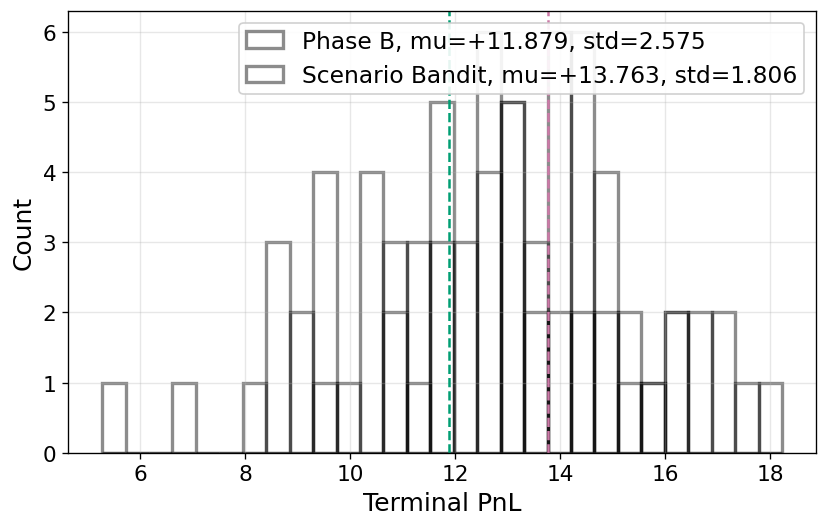

[CACHE SAVED] CELL_29_mc_dro_vs_phaseb_random_tau_cb9e32cb.pkl (0.0 MB)


In [22]:
# ----- CACHE CHECK -----
_cache_params = {
    'N_DRO_RANDOM_TAU_MC': globals().get('N_DRO_RANDOM_TAU_MC'),
    'DRO_RANDOM_TAU_MC_STEPS': globals().get('DRO_RANDOM_TAU_MC_STEPS'),
    'DRO_RANDOM_TAU_MC_EQUIL': globals().get('DRO_RANDOM_TAU_MC_EQUIL'),
    'DRO_RANDOM_TAU_GRID': globals().get('DRO_RANDOM_TAU_GRID'),
    'GLOBAL_SEED': globals().get('GLOBAL_SEED'),
    'REUSE_PHASEB_RANDOM_FROM_PREVIOUS_CELL': globals().get('REUSE_PHASEB_RANDOM_FROM_PREVIOUS_CELL'),
    'DRO_CHECKPOINT_NAME': getattr(globals().get('DRO_CHECKPOINT'), 'name', None),
    'CHECKPOINT_PHASEB_NAME': getattr(globals().get('DQN_CHECKPOINT_PHASEB'), 'name', None) if globals().get('HAS_PHASEB') and globals().get('DQN_CHECKPOINT_PHASEB') is not None else None,
}
_cache_file = _cache_path("CELL_29_mc_dro_vs_phaseb_random_tau", _cache_params)
_cached = _load_cache(_cache_file, force_refresh=FORCE_REFRESH_ALL)
if _cached is not None:
    (dro_random_tau_pnls, dro_random_tau_absinv, dro_random_tau_limit_frac, phaseb_cmp_pnls, phaseb_cmp_absinv, phaseb_cmp_limit_frac, paired_diff_dro, std_ratio) = _cached
else:
    # -- Monte Carlo: Phase B agent vs DRO agent under random tau per regime -----

    import gc
    import time
    import numpy as np
    import matplotlib.pyplot as plt
    from pathlib import Path

    N_DRO_RANDOM_TAU_MC = 50
    DRO_RANDOM_TAU_MC_STEPS = 500_000
    DRO_RANDOM_TAU_MC_EQUIL = 10_000
    DRO_RANDOM_TAU_GRID = [15.0, 30.0, 60.0, 120.0, 240.0]
    DRO_RANDOM_TAU_PROGRESS_EVERY = 1

    # If you already ran the previous Phase B random-tau cell with the same seeds,
    # this reuses phaseb_random_tau_pnls/absinv/limit_frac and only runs DRO.
    REUSE_PHASEB_RANDOM_FROM_PREVIOUS_CELL = True

    DRO_CHECKPOINT = CHECKPOINT_DIR / (
        #"deep_mm_mtm_pure_invp0.0010_g0p999_nstep3_h1x256_a6_"
        #"regime_exponential_random_tau_curriculum_dro_tau_factored_noise_fully_noisy_"
        #"inv_wall_dampe_c_lr_fill_quote_exposure_bayes_on2_mix_off_truncated_off_"
        #"final_hd93d0a66fe.pt"
        "deep_mm_mtm_pure_invp0.0010_g0p999_nstep3_h1x256_a6_regime_exponential_random_tau_curriculum_dro_tau_p256_b0p5_eps0p5_cap0p05_ramp0p5_pmix0p5__c_lr_fill_quote_exposure_bayes_on2_mix_off_truncated_off_final_hfb729bdc32.pt"

    )

    assert DRO_CHECKPOINT.exists(), f"DRO checkpoint not found: {DRO_CHECKPOINT}"
    assert HAS_PHASEB and ctrl_phaseb is not None, "Phase B controller is required."

    _meta_dro = load_meta(DRO_CHECKPOINT)
    SIGNAL_DRO = checkpoint_signal_config(_meta_dro)

    ctrl_dro = make_controller_from_checkpoint(
        str(DRO_CHECKPOINT),
        log_dir="runs_eval/regime_diag_dro_soft_random_tau",
        use_time_update=True,
        min_time_interval=DQN_TIME_THROTTLE,
        inv_limit_override=INV_LIMIT,
    )

    print(f"DRO checkpoint loaded: {DRO_CHECKPOINT.name}")
    print(f"DRO signal config     : {_summarise_signal_config(SIGNAL_DRO)}")


    def _cleanup_eval_controller(controller):
        if hasattr(controller, "nstep_buffer"):
            controller.nstep_buffer.clear()
        if "torch" in globals() and hasattr(torch, "cuda") and torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()


    def run_agent_metrics(controller, signal_config, buy_mo_prob, seed, run_label=None):
        if run_label is not None:
            print(f"    start {run_label}", flush=True)
        t0 = time.time()

        _, metrics = run_one_sim(
            buy_mo_prob=buy_mo_prob,
            seed=int(seed),
            controller=controller,
            total_events=DRO_RANDOM_TAU_MC_STEPS,
            equil_steps=DRO_RANDOM_TAU_MC_EQUIL,
            signal_config=signal_config,
            metrics_only=True,
        )

        pnl = float(metrics["MM_TotalPnL"])
        mean_abs_inv = float(metrics["mean_abs_inventory"])
        limit_frac = float(metrics["limit_frac"])

        del metrics
        _cleanup_eval_controller(controller)

        if run_label is not None:
            elapsed = time.time() - t0
            print(
                f"    done  {run_label}: pnl={pnl:+.4f}, "
                f"mean|q|={mean_abs_inv:.3f}, limit_frac={limit_frac:.4f}, "
                f"elapsed={elapsed:.1f}s",
                flush=True,
            )

        return pnl, mean_abs_inv, limit_frac


    _can_reuse_phaseb = (
        REUSE_PHASEB_RANDOM_FROM_PREVIOUS_CELL
        and "phaseb_random_tau_pnls" in globals()
        and len(phaseb_random_tau_pnls) >= N_DRO_RANDOM_TAU_MC
        and "phaseb_random_tau_absinv" in globals()
        and "phaseb_random_tau_limit_frac" in globals()
    )

    if _can_reuse_phaseb:
        print("[INFO] Reusing existing Phase B random-tau arrays from previous cell.")
        phaseb_cmp_pnls = list(np.asarray(phaseb_random_tau_pnls, dtype=float)[:N_DRO_RANDOM_TAU_MC])
        phaseb_cmp_absinv = list(np.asarray(phaseb_random_tau_absinv, dtype=float)[:N_DRO_RANDOM_TAU_MC])
        phaseb_cmp_limit_frac = list(np.asarray(phaseb_random_tau_limit_frac, dtype=float)[:N_DRO_RANDOM_TAU_MC])
    else:
        print("[INFO] No reusable Phase B arrays found; running Phase B again.")
        phaseb_cmp_pnls = []
        phaseb_cmp_absinv = []
        phaseb_cmp_limit_frac = []

    dro_random_tau_pnls = []
    dro_random_tau_absinv = []
    dro_random_tau_limit_frac = []

    for i in range(N_DRO_RANDOM_TAU_MC):
        seed_i = int(globals().get("GLOBAL_SEED", SEED)) + 500_000 + i
        sched_seed_i = seed_i + 20_000_000

        print(f"\n[DRO random-tau MC {i+1}/{N_DRO_RANDOM_TAU_MC}] seed={seed_i}", flush=True)

        if not _can_reuse_phaseb:
            sched_phaseb_i = make_random_tau_regime_schedule(
                total_events=DRO_RANDOM_TAU_MC_STEPS,
                seed=sched_seed_i,
                tau_grid=DRO_RANDOM_TAU_GRID,
            )

            pnl_b, absinv_b, lim_b = run_agent_metrics(
                ctrl_phaseb,
                SIGNAL_PHASEB,
                sched_phaseb_i,
                seed_i,
                run_label="Phase B under random tau",
            )

            phaseb_cmp_pnls.append(pnl_b)
            phaseb_cmp_absinv.append(absinv_b)
            phaseb_cmp_limit_frac.append(lim_b)

            del sched_phaseb_i
            gc.collect()

        # Separate schedule object, same seed/path distribution, avoids mutable schedule side effects.
        sched_dro_i = make_random_tau_regime_schedule(
            total_events=DRO_RANDOM_TAU_MC_STEPS,
            seed=sched_seed_i,
            tau_grid=DRO_RANDOM_TAU_GRID,
        )

        pnl_d, absinv_d, lim_d = run_agent_metrics(
            ctrl_dro,
            SIGNAL_DRO,
            sched_dro_i,
            seed_i,
            run_label="DRO under random tau",
        )

        dro_random_tau_pnls.append(pnl_d)
        dro_random_tau_absinv.append(absinv_d)
        dro_random_tau_limit_frac.append(lim_d)

        del sched_dro_i
        gc.collect()

        if ((i + 1) % DRO_RANDOM_TAU_PROGRESS_EVERY == 0) or ((i + 1) == N_DRO_RANDOM_TAU_MC):
            phaseb_now = np.asarray(phaseb_cmp_pnls, dtype=float)[: i + 1]
            dro_now = np.asarray(dro_random_tau_pnls, dtype=float)
            diff_now = dro_now - phaseb_now

            print(
                f"  progress {i+1}/{N_DRO_RANDOM_TAU_MC} | "
                f"PhaseB mean={phaseb_now.mean():+.4f}, std={phaseb_now.std(ddof=1) if len(phaseb_now) > 1 else 0.0:.4f} | "
                f"DRO mean={dro_now.mean():+.4f}, std={dro_now.std(ddof=1) if len(dro_now) > 1 else 0.0:.4f} | "
                f"DRO-PhaseB={diff_now.mean():+.4f}",
                flush=True,
            )

    phaseb_cmp_pnls = np.asarray(phaseb_cmp_pnls, dtype=float)
    phaseb_cmp_absinv = np.asarray(phaseb_cmp_absinv, dtype=float)
    phaseb_cmp_limit_frac = np.asarray(phaseb_cmp_limit_frac, dtype=float)

    dro_random_tau_pnls = np.asarray(dro_random_tau_pnls, dtype=float)
    dro_random_tau_absinv = np.asarray(dro_random_tau_absinv, dtype=float)
    dro_random_tau_limit_frac = np.asarray(dro_random_tau_limit_frac, dtype=float)

    paired_diff_dro = dro_random_tau_pnls - phaseb_cmp_pnls
    std_ratio = dro_random_tau_pnls.std(ddof=1) / phaseb_cmp_pnls.std(ddof=1)

    print("\nPhase B vs DRO Monte Carlo summary under random tau")
    print(f"  Phase B random tau: mean PnL={phaseb_cmp_pnls.mean():+.4f}, std={phaseb_cmp_pnls.std(ddof=1):.4f}")
    print(f"  DRO random tau    : mean PnL={dro_random_tau_pnls.mean():+.4f}, std={dro_random_tau_pnls.std(ddof=1):.4f}")
    print(f"  DRO - Phase B     : mean diff={paired_diff_dro.mean():+.4f}, std={paired_diff_dro.std(ddof=1):.4f}")
    print(f"  std ratio DRO/PhaseB = {std_ratio:.4f}")
    print(f"  Phase B mean |q|={phaseb_cmp_absinv.mean():.4f}, limit frac={phaseb_cmp_limit_frac.mean():.4f}")
    print(f"  DRO     mean |q|={dro_random_tau_absinv.mean():.4f}, limit frac={dro_random_tau_limit_frac.mean():.4f}")

    fig, ax1 = plt.subplots(figsize=(7, 4.5))

    all_pnls = np.concatenate([phaseb_cmp_pnls, dro_random_tau_pnls])
    bins = np.linspace(all_pnls.min() - 0.05, all_pnls.max() + 0.05, 30)

    ax1.hist(
        phaseb_cmp_pnls,
        bins=bins,
        alpha=0.45,

        linewidth=2.0,

        color="#009E73",

        fill=False,
        label=f"Phase B, mu={phaseb_cmp_pnls.mean():+.3f}, std={phaseb_cmp_pnls.std(ddof=1):.3f}",
    )
    ax1.hist(
        dro_random_tau_pnls,
        bins=bins,
        alpha=0.45,

        linewidth=2.0,

        color="#CC79A7",

        fill=False,
        label=f"Scenario Bandit, mu={dro_random_tau_pnls.mean():+.3f}, std={dro_random_tau_pnls.std(ddof=1):.3f}",
    )
    ax1.axvline(phaseb_cmp_pnls.mean(), color="#009E73", linestyle="--", linewidth=1.5)
    ax1.axvline(dro_random_tau_pnls.mean(), color="#CC79A7", linestyle="--", linewidth=1.5)
    # ax1.set_title("Random-tau terminal PnL")  # supervisor: no inline titles; caption describes
    ax1.set_xlabel("Terminal PnL")
    ax1.set_ylabel("Count")
    ax1.legend(fontsize=14)
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    _PAPER_FIG_PATH = Path("/Users/felipemoret/Desktop/extended_first_abstract_RLMM/scenario_bandit_random_tau.png")
    plt.savefig("scenario_bandit_random_tau.png", dpi=200, bbox_inches="tight")  # paper-named export
    plt.savefig(_PAPER_FIG_PATH, dpi=200, bbox_inches="tight")
    plt.show()
    _save_cache(_cache_file, (dro_random_tau_pnls, dro_random_tau_absinv, dro_random_tau_limit_frac, phaseb_cmp_pnls, phaseb_cmp_absinv, phaseb_cmp_limit_frac, paired_diff_dro, std_ratio))
# ----- END CACHE -----


[Auto-detect] use_flow_signal=False, use_fast_flow_signal=False, use_bayes_flow_signal=True, bayes_flow_feature_keys=['bayes_m_hat', 'bayes_expected_run_length'], use_fill_imbalance=True (input_dim=9 vs base=6)

================ DEEP CONTROLLER SETUP ================
Algorithm          : Deep Q-Learning
Double             : True
Dueling            : True
Prioritized Replay : True
Noisy Nets         : True (fully-noisy, independent)
[MM PURE]          : True
[MM PURE] inv_limit: 8
[MM PURE] offsets          : [(-1, -1), (-1, 0), (0, -1), (0, 0), (0, 1), (1, 0)]
[MM PURE] max_bid_offset   : 1
[MM PURE] max_ask_offset   : 1
[MM PURE] max_offset(state): 1

--- Throttling Configuration ---
Time Gating        : True (min 1.0s)
Event Gating       : False (min 100 steps)
TOB Gating         : False (min 10 moves)
MDP Mode (no bypass): True
Slow Flow EWMA     : False
Fast Flow EWMA     : False
Bayes Flow Signal  : True
Bayes Flow Features: ['bayes_m_hat', 'bayes_expected_run_length']
Fill Imbala

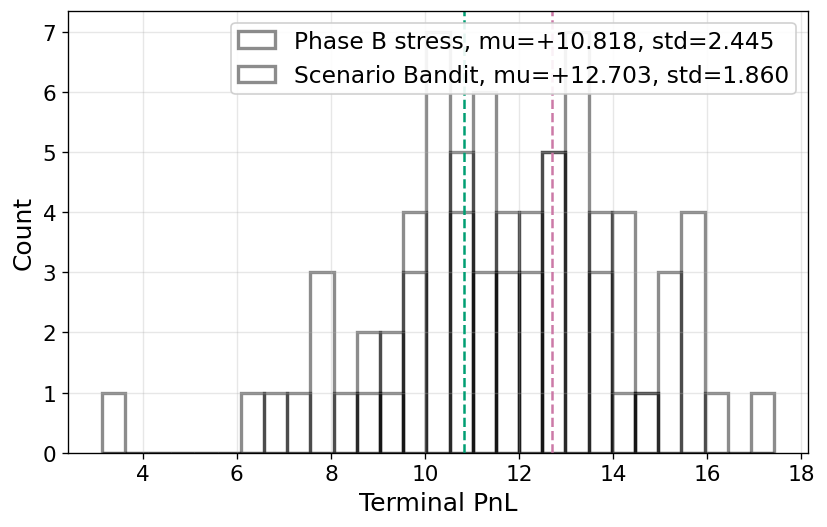

[CACHE SAVED] CELL_30_mc_dro_vs_phaseb_clustered_3dbeaec0.pkl (0.0 MB)


In [23]:
# ----- CACHE CHECK -----
_cache_params = {
    'N_DRO_CLUSTERED_MC': globals().get('N_DRO_CLUSTERED_MC'),
    'DRO_CLUSTERED_MC_STEPS': globals().get('DRO_CLUSTERED_MC_STEPS'),
    'DRO_CLUSTERED_MC_EQUIL': globals().get('DRO_CLUSTERED_MC_EQUIL'),
    'DRO_CLUSTERED_TAU_GRID': globals().get('DRO_CLUSTERED_TAU_GRID'),
    'DRO_CLUSTERED_RHO': globals().get('DRO_CLUSTERED_RHO'),
    'DRO_CLUSTERED_CHUNK_LEN_MO': globals().get('DRO_CLUSTERED_CHUNK_LEN_MO'),
    'DRO_ORDER_FLOW_INTENSITY_LOW': globals().get('DRO_ORDER_FLOW_INTENSITY_LOW'),
    'DRO_ORDER_FLOW_INTENSITY_HIGH': globals().get('DRO_ORDER_FLOW_INTENSITY_HIGH'),
    'GLOBAL_SEED': globals().get('GLOBAL_SEED'),
    'REUSE_PHASEB_CLUSTERED_FROM_PREVIOUS_CELL': globals().get('REUSE_PHASEB_CLUSTERED_FROM_PREVIOUS_CELL'),
    'DRO_CHECKPOINT_NAME': getattr(globals().get('DRO_CHECKPOINT'), 'name', None),
    'CHECKPOINT_PHASEB_NAME': getattr(globals().get('DQN_CHECKPOINT_PHASEB'), 'name', None) if globals().get('HAS_PHASEB') and globals().get('DQN_CHECKPOINT_PHASEB') is not None else None,
}
_cache_file = _cache_path("CELL_30_mc_dro_vs_phaseb_clustered", _cache_params)
_cached = _load_cache(_cache_file, force_refresh=FORCE_REFRESH_ALL)
if _cached is not None:
    (dro_clustered_pnls, dro_clustered_absinv, dro_clustered_limit_frac, phaseb_cmp_clustered_pnls, phaseb_cmp_clustered_absinv, phaseb_cmp_clustered_limit_frac, paired_diff_dro_clustered, std_ratio_clustered) = _cached
else:
    # -- Monte Carlo: Phase B vs DRO under persistent-side intensity stress -------

    import gc
    import time
    import numpy as np
    import matplotlib.pyplot as plt
    from pathlib import Path

    N_DRO_CLUSTERED_MC = 50
    DRO_CLUSTERED_MC_STEPS = 500_000
    DRO_CLUSTERED_MC_EQUIL = 10_000

    DRO_CLUSTERED_TAU_GRID = [15.0, 30.0, 60.0, 120.0, 240.0]
    DRO_CLUSTERED_RHO = 0.85
    DRO_CLUSTERED_CHUNK_LEN_MO = None
    DRO_ORDER_FLOW_INTENSITY_LOW = 0.0
    DRO_ORDER_FLOW_INTENSITY_HIGH = 0.30
    DRO_CLUSTERED_PROGRESS_EVERY = 1

    REUSE_PHASEB_CLUSTERED_FROM_PREVIOUS_CELL = True

    DRO_CHECKPOINT = CHECKPOINT_DIR / (
        #"deep_mm_mtm_pure_invp0.0010_g0p999_nstep3_h1x256_a6_"
        #"regime_exponential_random_tau_curriculum_dro_tau_factored_noise_fully_noisy_"
        #"inv_wall_dampe_c_lr_fill_quote_exposure_bayes_on2_mix_off_truncated_off_"
        #"final_hd93d0a66fe.pt"
        "deep_mm_mtm_pure_invp0.0010_g0p999_nstep3_h1x256_a6_regime_exponential_random_tau_curriculum_dro_tau_p256_b0p5_eps0p5_cap0p05_ramp0p5_pmix0p5__c_lr_fill_quote_exposure_bayes_on2_mix_off_truncated_off_final_hfb729bdc32.pt"

    )

    assert DRO_CHECKPOINT.exists(), f"DRO checkpoint not found: {DRO_CHECKPOINT}"
    assert HAS_PHASEB and ctrl_phaseb is not None, "Phase B controller is required."
    assert "make_clustered_intensity_regime_schedule" in globals(), "Run/define the clustered schedule cell first."

    _meta_dro = load_meta(DRO_CHECKPOINT)
    SIGNAL_DRO = checkpoint_signal_config(_meta_dro)

    ctrl_dro = make_controller_from_checkpoint(
        str(DRO_CHECKPOINT),
        log_dir="runs_eval/regime_diag_dro_soft_clustered_intensity",
        use_time_update=True,
        min_time_interval=DQN_TIME_THROTTLE,
        inv_limit_override=INV_LIMIT,
    )

    print(f"DRO checkpoint loaded: {DRO_CHECKPOINT.name}")
    print(f"DRO signal config     : {_summarise_signal_config(SIGNAL_DRO)}")


    def _cleanup_eval_controller(controller):
        if hasattr(controller, "nstep_buffer"):
            controller.nstep_buffer.clear()
        if "torch" in globals() and hasattr(torch, "cuda") and torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()


    def run_agent_clustered_metrics(controller, signal_config, buy_mo_prob, seed, run_label=None):
        if run_label is not None:
            print(f"    start {run_label}", flush=True)
        t0 = time.time()

        _, metrics = run_one_sim(
            buy_mo_prob=buy_mo_prob,
            seed=int(seed),
            controller=controller,
            total_events=DRO_CLUSTERED_MC_STEPS,
            equil_steps=DRO_CLUSTERED_MC_EQUIL,
            signal_config=signal_config,
            metrics_only=True,
        )

        pnl = float(metrics["MM_TotalPnL"])
        mean_abs_inv = float(metrics["mean_abs_inventory"])
        limit_frac = float(metrics["limit_frac"])

        del metrics
        _cleanup_eval_controller(controller)

        if run_label is not None:
            elapsed = time.time() - t0
            print(
                f"    done  {run_label}: pnl={pnl:+.4f}, "
                f"mean|q|={mean_abs_inv:.3f}, limit_frac={limit_frac:.4f}, "
                f"elapsed={elapsed:.1f}s",
                flush=True,
            )

        return pnl, mean_abs_inv, limit_frac


    _can_reuse_phaseb_clustered = (
        REUSE_PHASEB_CLUSTERED_FROM_PREVIOUS_CELL
        and "phaseb_clustered_pnls" in globals()
        and len(phaseb_clustered_pnls) >= N_DRO_CLUSTERED_MC
        and "phaseb_clustered_absinv" in globals()
        and "phaseb_clustered_limit_frac" in globals()
    )

    if _can_reuse_phaseb_clustered:
        print("[INFO] Reusing existing Phase B clustered-stress arrays from previous cell.")
        phaseb_cmp_clustered_pnls = list(np.asarray(phaseb_clustered_pnls, dtype=float)[:N_DRO_CLUSTERED_MC])
        phaseb_cmp_clustered_absinv = list(np.asarray(phaseb_clustered_absinv, dtype=float)[:N_DRO_CLUSTERED_MC])
        phaseb_cmp_clustered_limit_frac = list(np.asarray(phaseb_clustered_limit_frac, dtype=float)[:N_DRO_CLUSTERED_MC])
    else:
        print("[INFO] No reusable Phase B clustered arrays found; running Phase B again.")
        phaseb_cmp_clustered_pnls = []
        phaseb_cmp_clustered_absinv = []
        phaseb_cmp_clustered_limit_frac = []

    dro_clustered_pnls = []
    dro_clustered_absinv = []
    dro_clustered_limit_frac = []

    for i in range(N_DRO_CLUSTERED_MC):
        seed_i = int(globals().get("GLOBAL_SEED", SEED)) + 700_000 + i
        sched_seed_i = seed_i + 20_000_000

        print(f"\n[DRO clustered-stress MC {i+1}/{N_DRO_CLUSTERED_MC}] seed={seed_i}", flush=True)

        if not _can_reuse_phaseb_clustered:
            sched_phaseb_i = make_clustered_intensity_regime_schedule(
                total_events=DRO_CLUSTERED_MC_STEPS,
                seed=sched_seed_i,
                tau_grid=DRO_CLUSTERED_TAU_GRID,
                rho=DRO_CLUSTERED_RHO,
                chunk_len_mo=DRO_CLUSTERED_CHUNK_LEN_MO,
                intensity_low=DRO_ORDER_FLOW_INTENSITY_LOW,
                intensity_high=DRO_ORDER_FLOW_INTENSITY_HIGH,
            )

            pnl_b, absinv_b, lim_b = run_agent_clustered_metrics(
                ctrl_phaseb,
                SIGNAL_PHASEB,
                sched_phaseb_i,
                seed_i,
                run_label=f"Phase B persistent-side stress rho={DRO_CLUSTERED_RHO:.2f}",
            )

            phaseb_cmp_clustered_pnls.append(pnl_b)
            phaseb_cmp_clustered_absinv.append(absinv_b)
            phaseb_cmp_clustered_limit_frac.append(lim_b)

            del sched_phaseb_i
            gc.collect()

        # Separate schedule object with the same seed, so DRO sees the same persistent regime path.
        sched_dro_i = make_clustered_intensity_regime_schedule(
            total_events=DRO_CLUSTERED_MC_STEPS,
            seed=sched_seed_i,
            tau_grid=DRO_CLUSTERED_TAU_GRID,
            rho=DRO_CLUSTERED_RHO,
            chunk_len_mo=DRO_CLUSTERED_CHUNK_LEN_MO,
            intensity_low=DRO_ORDER_FLOW_INTENSITY_LOW,
            intensity_high=DRO_ORDER_FLOW_INTENSITY_HIGH,
        )

        pnl_d, absinv_d, lim_d = run_agent_clustered_metrics(
            ctrl_dro,
            SIGNAL_DRO,
            sched_dro_i,
            seed_i,
            run_label=f"DRO persistent-side stress rho={DRO_CLUSTERED_RHO:.2f}",
        )

        dro_clustered_pnls.append(pnl_d)
        dro_clustered_absinv.append(absinv_d)
        dro_clustered_limit_frac.append(lim_d)

        del sched_dro_i
        gc.collect()

        if ((i + 1) % DRO_CLUSTERED_PROGRESS_EVERY == 0) or ((i + 1) == N_DRO_CLUSTERED_MC):
            phaseb_now = np.asarray(phaseb_cmp_clustered_pnls, dtype=float)[: i + 1]
            dro_now = np.asarray(dro_clustered_pnls, dtype=float)
            diff_now = dro_now - phaseb_now

            print(
                f"  progress {i+1}/{N_DRO_CLUSTERED_MC} | "
                f"PhaseB mean={phaseb_now.mean():+.4f}, std={phaseb_now.std(ddof=1) if len(phaseb_now) > 1 else 0.0:.4f} | "
                f"DRO mean={dro_now.mean():+.4f}, std={dro_now.std(ddof=1) if len(dro_now) > 1 else 0.0:.4f} | "
                f"DRO-PhaseB={diff_now.mean():+.4f}",
                flush=True,
            )

    phaseb_cmp_clustered_pnls = np.asarray(phaseb_cmp_clustered_pnls, dtype=float)
    phaseb_cmp_clustered_absinv = np.asarray(phaseb_cmp_clustered_absinv, dtype=float)
    phaseb_cmp_clustered_limit_frac = np.asarray(phaseb_cmp_clustered_limit_frac, dtype=float)

    dro_clustered_pnls = np.asarray(dro_clustered_pnls, dtype=float)
    dro_clustered_absinv = np.asarray(dro_clustered_absinv, dtype=float)
    dro_clustered_limit_frac = np.asarray(dro_clustered_limit_frac, dtype=float)

    paired_diff_dro_clustered = dro_clustered_pnls - phaseb_cmp_clustered_pnls
    std_ratio_clustered = dro_clustered_pnls.std(ddof=1) / phaseb_cmp_clustered_pnls.std(ddof=1)

    print("\nPhase B vs DRO Monte Carlo summary under persistent-side intensity stress")
    print(f"  Phase B stress: mean PnL={phaseb_cmp_clustered_pnls.mean():+.4f}, std={phaseb_cmp_clustered_pnls.std(ddof=1):.4f}")
    print(f"  DRO stress    : mean PnL={dro_clustered_pnls.mean():+.4f}, std={dro_clustered_pnls.std(ddof=1):.4f}")
    print(f"  DRO - Phase B : mean diff={paired_diff_dro_clustered.mean():+.4f}, std={paired_diff_dro_clustered.std(ddof=1):.4f}")
    print(f"  std ratio DRO/PhaseB = {std_ratio_clustered:.4f}")
    print(f"  Phase B mean |q|={phaseb_cmp_clustered_absinv.mean():.4f}, limit frac={phaseb_cmp_clustered_limit_frac.mean():.4f}")
    print(f"  DRO     mean |q|={dro_clustered_absinv.mean():.4f}, limit frac={dro_clustered_limit_frac.mean():.4f}")

    fig, ax1 = plt.subplots(figsize=(7, 4.5))

    all_pnls = np.concatenate([phaseb_cmp_clustered_pnls, dro_clustered_pnls])
    bins = np.linspace(all_pnls.min() - 0.05, all_pnls.max() + 0.05, 30)

    ax1.hist(
        phaseb_cmp_clustered_pnls,
        bins=bins,
        alpha=0.45,

        linewidth=2.0,

        color="#009E73",

        fill=False,
        label=f"Phase B stress, mu={phaseb_cmp_clustered_pnls.mean():+.3f}, std={phaseb_cmp_clustered_pnls.std(ddof=1):.3f}",
    )
    ax1.hist(
        dro_clustered_pnls,
        bins=bins,
        alpha=0.45,

        linewidth=2.0,

        color="#CC79A7",

        fill=False,
        label=f"Scenario Bandit, mu={dro_clustered_pnls.mean():+.3f}, std={dro_clustered_pnls.std(ddof=1):.3f}",
    )
    ax1.axvline(phaseb_cmp_clustered_pnls.mean(), color="#009E73", linestyle="--", linewidth=1.5)
    ax1.axvline(dro_clustered_pnls.mean(), color="#CC79A7", linestyle="--", linewidth=1.5)
    # ax1.set_title("Persistent-side stress terminal PnL")  # supervisor: no inline titles; caption describes
    ax1.set_xlabel("Terminal PnL")
    ax1.set_ylabel("Count")
    ax1.legend(fontsize=14)
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    _PAPER_FIG_PATH = Path("/Users/felipemoret/Desktop/extended_first_abstract_RLMM/scenario_bandit_correlated_regime_stress.png")
    plt.savefig("scenario_bandit_correlated_regime_stress.png", dpi=200, bbox_inches="tight")  # paper-named export
    plt.savefig(_PAPER_FIG_PATH, dpi=200, bbox_inches="tight")
    plt.show()
    _save_cache(_cache_file, (dro_clustered_pnls, dro_clustered_absinv, dro_clustered_limit_frac, phaseb_cmp_clustered_pnls, phaseb_cmp_clustered_absinv, phaseb_cmp_clustered_limit_frac, paired_diff_dro_clustered, std_ratio_clustered))
# ----- END CACHE -----



================ DEEP CONTROLLER SETUP ================
Algorithm          : Deep Q-Learning
Double             : True
Dueling            : True
Prioritized Replay : True
Noisy Nets         : True (heads-only, independent)
[MM PURE]          : True
[MM PURE] inv_limit: 8
[MM PURE] offsets          : [(-1, -1), (-1, 0), (0, -1), (0, 0), (0, 1), (1, 0)]
[MM PURE] max_bid_offset   : 1
[MM PURE] max_ask_offset   : 1
[MM PURE] max_offset(state): 1

--- Throttling Configuration ---
Time Gating        : True (min 1.0s)
Event Gating       : False (min 100 steps)
TOB Gating         : False (min 10 moves)
MDP Mode (no bypass): True
Slow Flow EWMA     : False
Fast Flow EWMA     : False
Bayes Flow Signal  : False
Fill Imbalance     : False
  PER alpha schedule:
     start=0.6000  end=0.4000  last_ep=2000
  PER beta schedule:
     start=0.4000   end=1.0000   last_ep=2000

--- Core Hyperparameters ---
Gamma           = 0.97
Learning rate   = 0.0015
Batch size      = 128
Replay capacity = 150000
Tar

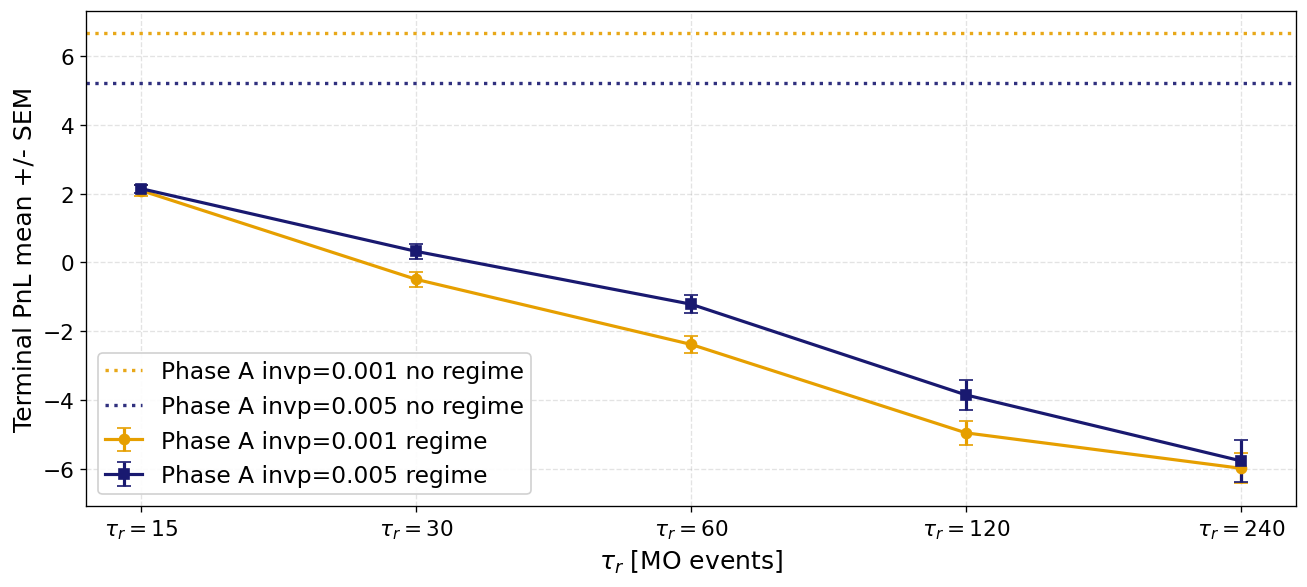

Saved: degradation_vs_tau_regime.png
Saved: /Users/felipemoret/Desktop/extended_first_abstract_RLMM/degradation_vs_tau_regime.png

Degradation tau sweep summary:

Phase A invp=0.001 (deep_mm_mtm_pure_invp0.0010_inv_wall_dampened_reward_clr200f0p30_best_ma50.pt)
   No regime  mean=+6.6522  std=0.6449  Delta=+0.0000
  $\tau_r=15$  mean=+2.0868  std=1.5359  Delta=-4.5654
  $\tau_r=30$  mean=-0.4960  std=2.2765  Delta=-7.1482
  $\tau_r=60$  mean=-2.3875  std=2.4879  Delta=-9.0397
  $\tau_r=120$  mean=-4.9591  std=3.5796  Delta=-11.6113
  $\tau_r=240$  mean=-5.9891  std=4.3806  Delta=-12.6414

Phase A invp=0.005 (deep_mm_mtm_pure_invp0.0050_inv_wall_dampened_reward_clr200f0p30_best_ma50.pt)
   No regime  mean=+5.2043  std=0.7193  Delta=+0.0000
  $\tau_r=15$  mean=+2.1406  std=1.1523  Delta=-3.0638
  $\tau_r=30$  mean=+0.3181  std=2.1969  Delta=-4.8862
  $\tau_r=60$  mean=-1.2183  std=2.6483  Delta=-6.4226
  $\tau_r=120$  mean=-3.8565  std=4.3068  Delta=-9.0608
  $\tau_r=240$  mean=-5.7728  

In [24]:
# ----- CACHE CHECK -----
_cache_params = {
    'N_DEGRADATION_SWEEP': globals().get('N_DEGRADATION_SWEEP'),
    'DEGRADATION_SWEEP': globals().get('DEGRADATION_SWEEP'),
    'DEGRADATION_SWEEP_STEPS': globals().get('DEGRADATION_SWEEP_STEPS'),
    'DEGRADATION_SWEEP_EQUIL': globals().get('DEGRADATION_SWEEP_EQUIL'),
    'GLOBAL_SEED': globals().get('GLOBAL_SEED'),
    'DEGRADATION_CHECKPOINT_INVP001_NAME': getattr(globals().get('DEGRADATION_CHECKPOINT_INVP001'), 'name', None),
    'DEGRADATION_CHECKPOINT_INVP005_NAME': getattr(globals().get('DEGRADATION_CHECKPOINT_INVP005'), 'name', None),
}
_cache_file = _cache_path("CELL_31_degradation_tau_sweep", _cache_params)
_cached = _load_cache(_cache_file, force_refresh=FORCE_REFRESH_ALL)
if _cached is not None:
    (degradation_tau_results, DEGRADATION_POLICIES, degradation_plot_labels, degradation_tau_labels) = _cached
else:
    # -- Tau degradation sweep: Phase A stationary checkpoints across inventory penalties --
    import gc
    import time

    # Phase A stationary agents with different inventory penalties, evaluated
    # under exponential regime-switching flow. The no-regime reference is shown
    # as a horizontal dotted line in the same color as each invp curve.

    DEGRADATION_SWEEP_STEPS = N_STEPS
    DEGRADATION_SWEEP_EQUIL = N_STEPS_TO_EQUIL
    if "TAU_SWEEP" not in globals():
        TAU_SWEEP = [15.0, 30.0, 60.0, 120.0, 240.0]
    DEGRADATION_SWEEP = list(TAU_SWEEP)
    N_DEGRADATION_SWEEP = 100
    DEGRADATION_PROGRESS_EVERY = 10
    DEGRADATION_PRINT_EACH_RUN = False

    DEGRADATION_CHECKPOINT_INVP001 = CHECKPOINT_DIR / "deep_mm_mtm_pure_invp0.0010_inv_wall_dampened_reward_clr200f0p30_best_ma50.pt"
    DEGRADATION_CHECKPOINT_INVP005 = CHECKPOINT_DIR / "deep_mm_mtm_pure_invp0.0050_inv_wall_dampened_reward_clr200f0p30_best_ma50.pt"

    DEGRADATION_FIG_PATH = Path("degradation_vs_tau_regime.png")
    DEGRADATION_PAPER_FIG_PATH = Path("/Users/felipemoret/Desktop/extended_first_abstract_RLMM/degradation_vs_tau_regime.png")


    def _degradation_tau_label(tau):
        tau_f = float(tau)
        if tau_f.is_integer():
            return rf"$\tau_r={int(tau_f)}$"
        return rf"$\tau_r={tau_f:g}$"


    def _load_degradation_controller(checkpoint_path, label, key):
        meta = load_meta(checkpoint_path)
        best_params = meta.get("best_params", {})
        controller = make_controller_from_checkpoint(
            str(checkpoint_path),
            log_dir=f"runs_eval/degradation_tau_sweep_{key}",
            use_time_update=True,
            min_time_interval=float(best_params.get("min_time_interval", DQN_TIME_THROTTLE)),
            inv_limit_override=int(best_params.get("inv_limit", INV_LIMIT)),
        )
        return {
            "key": key,
            "label": label,
            "checkpoint": checkpoint_path,
            "controller": controller,
            "signal_config": checkpoint_signal_config(meta),
        }


    def _cleanup_degradation_controller(controller):
        if hasattr(controller, "nstep_buffer"):
            controller.nstep_buffer.clear()
        if "torch" in globals() and hasattr(torch, "cuda") and torch.cuda.is_available():
            torch.cuda.empty_cache()
        gc.collect()


    def _run_one_degradation_terminal_pnl(
        buy_mo_prob,
        seed,
        controller,
        total_events,
        equil_steps,
        signal_config,
        run_label=None,
    ):
        if run_label is not None:
            print(f"    start {run_label}", flush=True)
        t0 = time.time()

        _, metrics = run_one_sim(
            buy_mo_prob=buy_mo_prob,
            seed=int(seed),
            controller=controller,
            total_events=total_events,
            equil_steps=equil_steps,
            signal_config=signal_config,
            metrics_only=True,
        )

        final_pnl = float(metrics["MM_TotalPnL"])
        del metrics

        _cleanup_degradation_controller(controller)

        if run_label is not None:
            elapsed = time.time() - t0
            print(f"    done  {run_label}: pnl={final_pnl:+.4f}, elapsed={elapsed:.1f}s", flush=True)

        return final_pnl


    def _print_degradation_progress(spec, tau_pnls):
        counts = [f"No regime={len(tau_pnls['No regime'])}/{N_DEGRADATION_SWEEP}"]
        for tau in DEGRADATION_SWEEP:
            label = _degradation_tau_label(tau)
            counts.append(f"{label}={len(tau_pnls[label])}/{N_DEGRADATION_SWEEP}")
        print(f"  {spec['label']} progress | " + " | ".join(counts), flush=True)


    assert DEGRADATION_CHECKPOINT_INVP001.exists(), f"Missing checkpoint: {DEGRADATION_CHECKPOINT_INVP001}"
    assert DEGRADATION_CHECKPOINT_INVP005.exists(), f"Missing checkpoint: {DEGRADATION_CHECKPOINT_INVP005}"


    DEGRADATION_POLICIES = [
        _load_degradation_controller(
            DEGRADATION_CHECKPOINT_INVP001,
            label="Phase A invp=0.001",
            key="phasea_invp001",
        ),
        _load_degradation_controller(
            DEGRADATION_CHECKPOINT_INVP005,
            label="Phase A invp=0.005",
            key="phasea_invp005",
        ),
    ]

    print("Degradation tau-sweep policies:")
    for spec in DEGRADATION_POLICIES:
        print(f"  {spec['label']}: {spec['checkpoint'].name}")


    def _run_degradation_sweep_for_policy(spec):
        tau_pnls = {"No regime": []}
        for tau in DEGRADATION_SWEEP:
            tau_pnls[_degradation_tau_label(tau)] = []

        print(f"\nStarting degradation tau sweep for {spec['label']}", flush=True)
        _print_degradation_progress(spec, tau_pnls)

        for i in range(N_DEGRADATION_SWEEP):
            seed_i = int(GLOBAL_SEED + 10_000 + i)

            if (
                DEGRADATION_PRINT_EACH_RUN
                or i == 0
                or ((i + 1) % DEGRADATION_PROGRESS_EVERY == 0)
                or ((i + 1) == N_DEGRADATION_SWEEP)
            ):
                print(f"\n  {spec['label']} seed {i+1}/{N_DEGRADATION_SWEEP} (seed={seed_i})", flush=True)

            pnl_stationary = _run_one_degradation_terminal_pnl(
                buy_mo_prob=0.5,
                seed=seed_i,
                controller=spec["controller"],
                total_events=DEGRADATION_SWEEP_STEPS,
                equil_steps=DEGRADATION_SWEEP_EQUIL,
                signal_config=spec["signal_config"],
                run_label="No regime" if DEGRADATION_PRINT_EACH_RUN else None,
            )
            tau_pnls["No regime"].append(pnl_stationary)

            for tau in DEGRADATION_SWEEP:
                label = _degradation_tau_label(tau)
                sched_seed = int(seed_i + 1_000_000 + round(10_000 * float(tau)))

                sched_i = build_regime_schedule(
                    total_events=DEGRADATION_SWEEP_STEPS,
                    seed=sched_seed,
                    distribution="exponential",
                    tau=float(tau),
                )

                pnl_tau = _run_one_degradation_terminal_pnl(
                    buy_mo_prob=sched_i,
                    seed=seed_i,
                    controller=spec["controller"],
                    total_events=DEGRADATION_SWEEP_STEPS,
                    equil_steps=DEGRADATION_SWEEP_EQUIL,
                    signal_config=spec["signal_config"],
                    run_label=label if DEGRADATION_PRINT_EACH_RUN else None,
                )
                tau_pnls[label].append(pnl_tau)

                del sched_i
                gc.collect()

            if ((i + 1) % DEGRADATION_PROGRESS_EVERY == 0) or ((i + 1) == N_DEGRADATION_SWEEP):
                _print_degradation_progress(spec, tau_pnls)

        gc.collect()
        return {label: np.asarray(values, dtype=float) for label, values in tau_pnls.items()}


    degradation_plot_labels = [_degradation_tau_label(tau) for tau in DEGRADATION_SWEEP]
    degradation_tau_labels = ["No regime"] + degradation_plot_labels
    degradation_tau_results = {}

    for spec in DEGRADATION_POLICIES:
        tau_pnls = _run_degradation_sweep_for_policy(spec)

        means = np.array([np.mean(tau_pnls[label]) for label in degradation_tau_labels])
        stds = np.array([np.std(tau_pnls[label], ddof=1) for label in degradation_tau_labels])
        sems = stds / np.sqrt(N_DEGRADATION_SWEEP)

        baseline = tau_pnls["No regime"]
        paired_diffs = {"No regime": np.zeros_like(baseline)}
        for tau in DEGRADATION_SWEEP:
            label = _degradation_tau_label(tau)
            paired_diffs[label] = tau_pnls[label] - baseline

        deltas = np.array([np.mean(paired_diffs[label]) for label in degradation_tau_labels])
        delta_sems = np.array([
            np.std(paired_diffs[label], ddof=1) / np.sqrt(N_DEGRADATION_SWEEP)
            for label in degradation_tau_labels
        ])
        decay_pct = np.where(means[0] != 0.0, 100.0 * deltas / abs(means[0]), np.nan)

        degradation_tau_results[spec["key"]] = {
            "spec": spec,
            "pnls": tau_pnls,
            "means": means,
            "stds": stds,
            "sems": sems,
            "deltas": deltas,
            "delta_sems": delta_sems,
            "decay_pct": decay_pct,
        }

        gc.collect()


    x = np.arange(len(degradation_plot_labels))
    degradation_colors = {
        "phasea_invp001": "#E69F00",
        "phasea_invp005": "midnightblue",
    }
    degradation_markers = {
        "phasea_invp001": "o",
        "phasea_invp005": "s",
    }
    degradation_text_offsets = {
        "phasea_invp001": -0.06,
        "phasea_invp005": 0.06,
    }

    regime_p_lo = globals().get("REGIME_P_LO", 0.2)
    regime_p_hi = globals().get("REGIME_P_HI", 0.8)

    fig, ax1 = plt.subplots(figsize=(11, 5))

    for key, result in degradation_tau_results.items():
        spec = result["spec"]
        color = degradation_colors.get(key)
        ax1.axhline(
            result["means"][0],
            color=color,
            linestyle=":",
            linewidth=2.0,
            alpha=0.9,
            label=f"{spec['label']} no regime",
        )

    for key, result in degradation_tau_results.items():
        spec = result["spec"]
        color = degradation_colors.get(key)
        ax1.errorbar(
            x,
            result["means"][1:],
            yerr=result["sems"][1:],
            fmt=degradation_markers.get(key, "o") + "-",
            capsize=4,
            color=color,
            linewidth=1.9,
            markersize=6,
            label=f"{spec['label']} regime",
        )

    ax1.set_ylabel("Terminal PnL mean +/- SEM")
    # ax1.set_title(  # supervisor: no inline titles; caption describes
        # f"Phase A degradation vs regime time scale\n"
        # f"Exponential regimes, p_buy in [{regime_p_lo}, {regime_p_hi}], $N_{{\\mathrm{{sim}}}}$={N_DEGRADATION_SWEEP}"
    # )
    ax1.grid(True, linestyle="--", alpha=0.35)
    ax1.legend(loc="best", fontsize=14)
    ax1.set_xticks(x)
    ax1.set_xticklabels(degradation_plot_labels)
    ax1.set_xlabel(r"$\tau_r$ [MO events]")

    plt.tight_layout()
    plt.savefig(DEGRADATION_FIG_PATH, dpi=150)
    if DEGRADATION_PAPER_FIG_PATH.parent.exists():
        plt.savefig(DEGRADATION_PAPER_FIG_PATH, dpi=150)
    plt.show()

    print(f"Saved: {DEGRADATION_FIG_PATH}")
    if DEGRADATION_PAPER_FIG_PATH.parent.exists():
        print(f"Saved: {DEGRADATION_PAPER_FIG_PATH}")

    print("\nDegradation tau sweep summary:")
    for key, result in degradation_tau_results.items():
        print(f"\n{result['spec']['label']} ({result['spec']['checkpoint'].name})")
        for label, mean_v, std_v, delta_v in zip(
            degradation_tau_labels,
            result["means"],
            result["stds"],
            result["deltas"],
        ):
            print(f"  {label:>10}  mean={mean_v:+.4f}  std={std_v:.4f}  Delta={delta_v:+.4f}")
    _save_cache(_cache_file, (degradation_tau_results, DEGRADATION_POLICIES, degradation_plot_labels, degradation_tau_labels))
# ----- END CACHE -----
